<a href="https://colab.research.google.com/github/AmanuelDaget/GBPUSD-Foreign-Exchange-Price-Pridiction-Using-LSTM-GRU-BiLSTM/blob/main/GBPUSD_Price_pridiction_Using_LSTM_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **GBPUSD Price pridiction Using LSTM GRU**

**Environment Setup & Installations**

In [1]:
#pip install yfinance seaborn plotly

**Import Libraries**

In [7]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
from scipy import stats

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import RobustScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, SimpleRNN, LSTM, GRU,
    Bidirectional, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


**CONFIGURATION**

In [15]:
DATA_PATH     = 'data/gbpusd_hourly_newyorkTimezone.csv'
MODELS_DIR    = 'models'
PLOTS_DIR     = 'plots'

LOOKBACK      = 48
TRAIN_RATIO   = 0.70
VAL_RATIO     = 0.15
BATCH_SIZE    = 32
EPOCHS        = 100
PATIENCE      = 15
UNITS         = 128
DROPOUT       = 0.30
LEARNING_RATE = 0.001

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

COLORS = {
    'Vanilla_RNN':   '#378ADD',
    'LSTM':   '#F4B400',
    'GRU':    '#1D9E75',
    'BiLSTM': '#BA7517',
}


print('Configuration loaded.')

Configuration loaded.


**Load the data**

In [16]:
def load_csv_robust(path):
    raw = pd.read_csv(path, header=None, dtype=str)
    data_start = next((i for i, v in enumerate(raw.iloc[:, 0]) if try_dt(v) and v.strip().lower() not in {'price', 'ticker', 'datetime', 'date', ''}), None) or (_ for _ in ()).throw(ValueError('No datetime rows found.'))
    ohlc = {'open', 'high', 'low', 'close'}
    cols = next(([str(v).strip() for v in raw.iloc[i]] for i in range(data_start - 1, -1, -1) if ohlc.issubset({str(v).strip().lower() for v in raw.iloc[i]})), ['Datetime', 'Open', 'High', 'Low', 'Close'])
    df = raw.iloc[data_start:].reset_index(drop=True)
    df.index = pd.to_datetime(df.iloc[:, 0], utc=True, errors='coerce')
    df = df[df.index.notna()].iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
    df.columns, df.index.name = cols[1:][:len(df.columns)], 'Datetime'
    return df

def try_dt(v):
    try: pd.to_datetime(v.strip()); return True
    except: return False

df_raw = load_csv_robust(DATA_PATH)
print(f'Raw shape: {df_raw.shape}  |  {df_raw.index[0]} → {df_raw.index[-1]}')

Raw shape: (14200, 4)  |  2024-01-29 00:00:00+00:00 → 2026-05-15 18:00:00+00:00


# **DATA PREPROCESSING**

In [17]:
df = df_raw.copy()

**Keep only OHLC columns**

In [18]:
required = ["Open", "High", "Low", "Close"]
missing_cols = [c for c in required if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}. "
                     f"Available: {list(df.columns)}")
df = df[required].copy()
print(f"  [2.2] Kept columns : {required}")

  [2.2] Kept columns : ['Open', 'High', 'Low', 'Close']


**Convert index to New York timezone**

In [19]:
# The loader already parsed the index as UTC-aware (utc=True).
# We just convert to New York local time — pandas handles EDT/EST DST.
df.index = df.index.tz_convert("America/New_York")
df.sort_index(inplace=True)
df.index.name = "Datetime"
print(f"  [2.3] Timezone     : {df.index.tz}")
print(f"        Date range   : {df.index[0]}  →  {df.index[-1]}")
print(f"        Total rows   : {len(df):,}")

  [2.3] Timezone     : America/New_York
        Date range   : 2024-01-28 19:00:00-05:00  →  2026-05-15 14:00:00-04:00
        Total rows   : 14,200


**Remove duplicate timestamps**

In [20]:
n_before = len(df)
df = df[~df.index.duplicated(keep="first")]
n_dupes = n_before - len(df)
print(f"  [2.4] Duplicate timestamps removed : {n_dupes}")

  [2.4] Duplicate timestamps removed : 0


**Detect & report missing values BEFORE filling**

In [21]:
print(f"\n  [2.5] Missing value report (before treatment):")
for col in df.columns:
    n_nan = df[col].isna().sum()
    pct   = n_nan / len(df) * 100
    print(f"        {col:<8} → {n_nan:>4} NaN  ({pct:.2f}%)")


  [2.5] Missing value report (before treatment):
        Open     →    0 NaN  (0.00%)
        High     →    0 NaN  (0.00%)
        Low      →    0 NaN  (0.00%)
        Close    →    0 NaN  (0.00%)


Detect & fill missing hourly gaps in the time index

In [22]:
full_idx   = pd.date_range(start=df.index.min(),
                            end=df.index.max(),
                            freq="1h",
                            tz=df.index.tz)
missing_ts = full_idx.difference(df.index)
# Classify missing timestamps as weekend (expected) vs weekday (data gap)
weekend_missing  = [t for t in missing_ts if t.weekday() >= 5]
weekday_missing  = [t for t in missing_ts if t.weekday() <  5]

print(f"\n  [2.7] Missing hourly timestamps:")
print(f"        Weekend gaps  (expected) : {len(weekend_missing):>5}")
print(f"        Weekday gaps (data issue): {len(weekday_missing):>5}")

if weekday_missing:
    # Reindex to full hourly frequency, fill new rows by forward-fill
    df = df.reindex(full_idx)
    df = df.fillna(method='ffill').fillna(method='bfill')
    # Drop weekend rows (no trading — do NOT feed zero-movement hours to model)
    df = df[df.index.weekday < 5]
    print(f"        Weekday gaps filled via ffill. Weekend rows excluded.")
else:
    # No weekday gaps — just drop weekend rows
    df = df[df.index.weekday < 5]
    print(f"        No weekday gaps found. Weekend rows excluded.")

print(f"        Rows after gap handling  : {len(df):,}")


  [2.7] Missing hourly timestamps:
        Weekend gaps  (expected) :  5132
        Weekday gaps (data issue):   775
        Weekday gaps filled via ffill. Weekend rows excluded.
        Rows after gap handling  : 14,391


/tmp/ipykernel_2564/696517289.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


**Outlier detection & capping (IQR method per column)**

In [23]:
print(f"\n  [2.8] Outlier capping (IQR × 3.0):")
for col in df.columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo  = Q1 - 3.0 * IQR
    hi  = Q3 + 3.0 * IQR
    n_outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    print(f"        {col:<8} → {n_outliers:>3} outliers capped  "
          f"[{lo:.5f}, {hi:.5f}]")


  [2.8] Outlier capping (IQR × 3.0):
        Open     →   0 outliers capped  [1.05100, 1.56239]
        High     →   0 outliers capped  [1.05138, 1.56327]
        Low      →   0 outliers capped  [1.05035, 1.56170]
        Close    →   0 outliers capped  [1.05093, 1.56243]


**Sanity checks**

In [24]:
invalid_hl    = (df["High"] < df["Low"]).sum()
invalid_close = ((df["Close"] < df["Low"]) | (df["Close"] > df["High"])).sum()
print(f"\n  [2.9] Sanity checks:")
print(f"        High < Low  violations : {invalid_hl}")
print(f"        Close out of HL range  : {invalid_close}")

# Fix High < Low by swapping (rare but possible in raw data)
if invalid_hl > 0:
    mask = df["High"] < df["Low"]
    df.loc[mask, ["High", "Low"]] = df.loc[mask, ["Low", "High"]].values
    print(f"        Swapped {invalid_hl} High/Low pairs.")


  [2.9] Sanity checks:
        High < Low  violations : 0
        Close out of HL range  : 0


**Stationarity check (Augmented Dickey-Fuller test on Close)**

In [25]:
from statsmodels.tsa.stattools import adfuller

print(f"\n  [2.10] Stationarity — ADF test on Close price:")
adf_result = adfuller(df["Close"].dropna(), autolag="AIC")
print(f"         ADF Statistic : {adf_result[0]:.4f}")
print(f"         p-value       : {adf_result[1]:.4f}")
print(f"         Critical vals : {adf_result[4]}")
if adf_result[1] < 0.05:
    print("         Conclusion    : Series is STATIONARY (p < 0.05) ✓")
else:
    print("         Conclusion    : Series is NON-STATIONARY (p ≥ 0.05)")
    print("         Note          : Models will learn from normalised returns — OK.")


  [2.10] Stationarity — ADF test on Close price:
         ADF Statistic : -1.8119
         p-value       : 0.3746
         Critical vals : {'1%': np.float64(-3.4308045463179675), '5%': np.float64(-2.8617408891824274), '10%': np.float64(-2.5668769285717263)}
         Conclusion    : Series is NON-STATIONARY (p ≥ 0.05)
         Note          : Models will learn from normalised returns — OK.


**Final preprocessing summary**

In [26]:
print(f"\n  {'─'*50}")
print(f"  Preprocessing complete.")
print(f"  Final dataset shape : {df.shape}")
print(f"  Date range          : {df.index[0]}  →  {df.index[-1]}")
print(f"  Remaining NaN       : {df.isna().sum().sum()}")
print(f"  {'─'*50}")
print(f"\n  Descriptive statistics:")
print(df.describe().round(6).to_string())


  ──────────────────────────────────────────────────
  Preprocessing complete.
  Final dataset shape : (14391, 4)
  Date range          : 2024-01-29 00:00:00-05:00  →  2026-05-15 14:00:00-04:00
  Remaining NaN       : 0
  ──────────────────────────────────────────────────

  Descriptive statistics:
               Open          High           Low         Close
count  14391.000000  14391.000000  14391.000000  14391.000000
mean       1.307374      1.308061      1.306694      1.307380
std        0.039462      0.039483      0.039441      0.039460
min        1.210874      1.213209      1.210126      1.210771
25%        1.270164      1.270761      1.269503      1.270148
50%        1.312870      1.313387      1.312422      1.312870
75%        1.343219      1.343887      1.342552      1.343219
max        1.384792      1.386866      1.383700      1.385003


**Check Wheather Data Normaly distributed or Not**

  Column          Shapiro p    D'Agostino p   Skewness   Kurtosis    Normal?
  ------------------------------------------------------------------------
  Close          1.5132e-40      0.0000e+00    -0.2070    -1.2373       NO ✗
  Open           1.5116e-40      0.0000e+00    -0.2070    -1.2370       NO ✗
  High           1.1559e-40      0.0000e+00    -0.2053    -1.2426       NO ✗
  Low            1.9050e-40      0.0000e+00    -0.2087    -1.2322       NO ✗
  Returns        6.0613e-53      0.0000e+00    -0.3227    11.6741       NO ✗


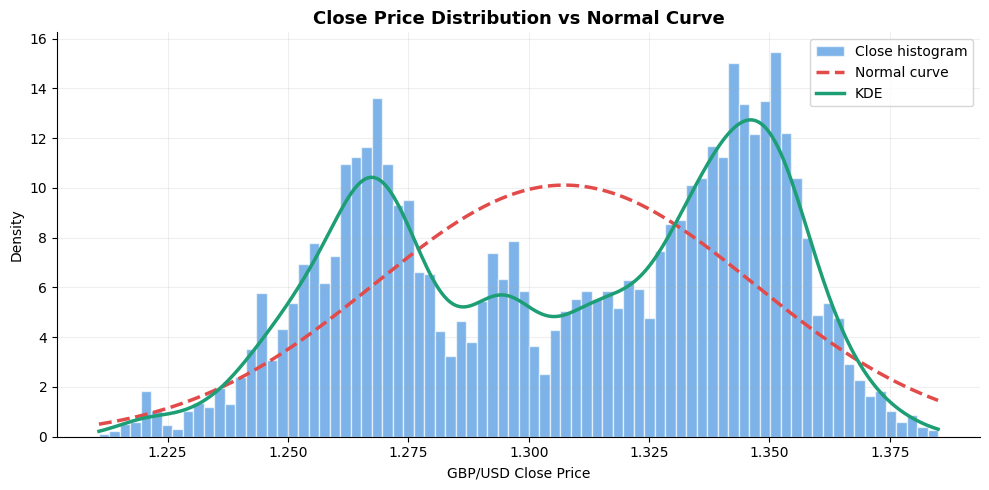

  [Fig 1] Saved → plots/01_close_distribution.png


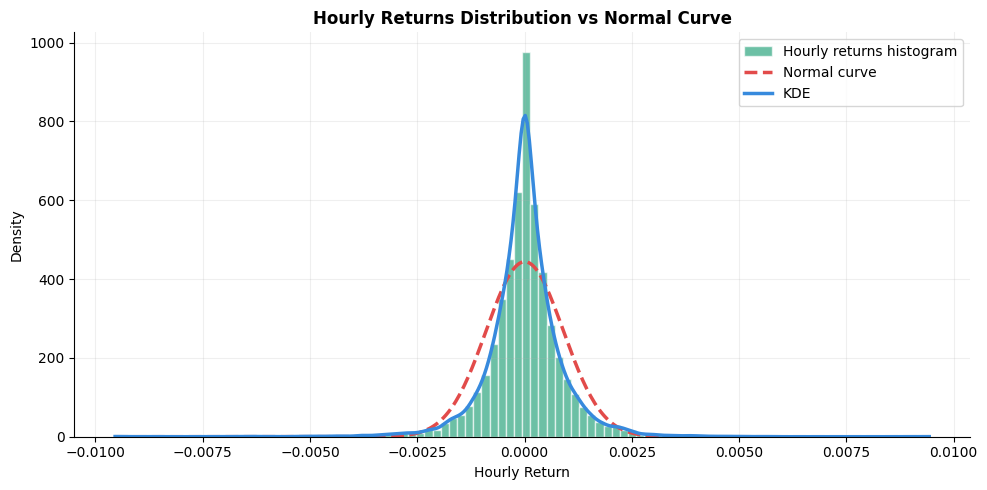

  [Fig 2] Saved → plots/02_returns_distribution.png


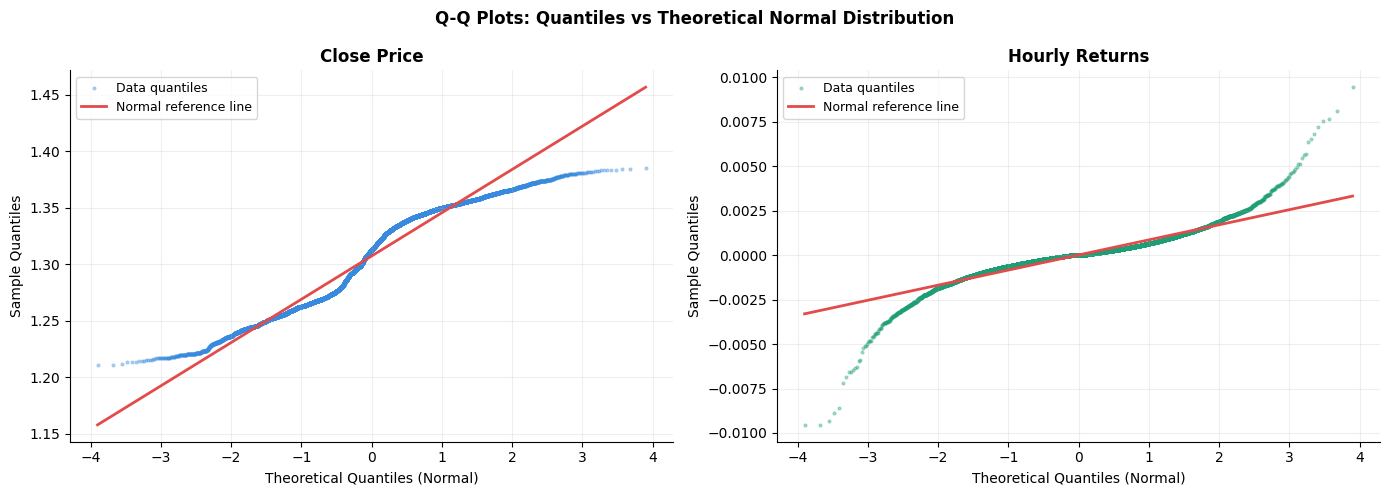

  [Fig 3] Saved → plots/03_qq_plots.png


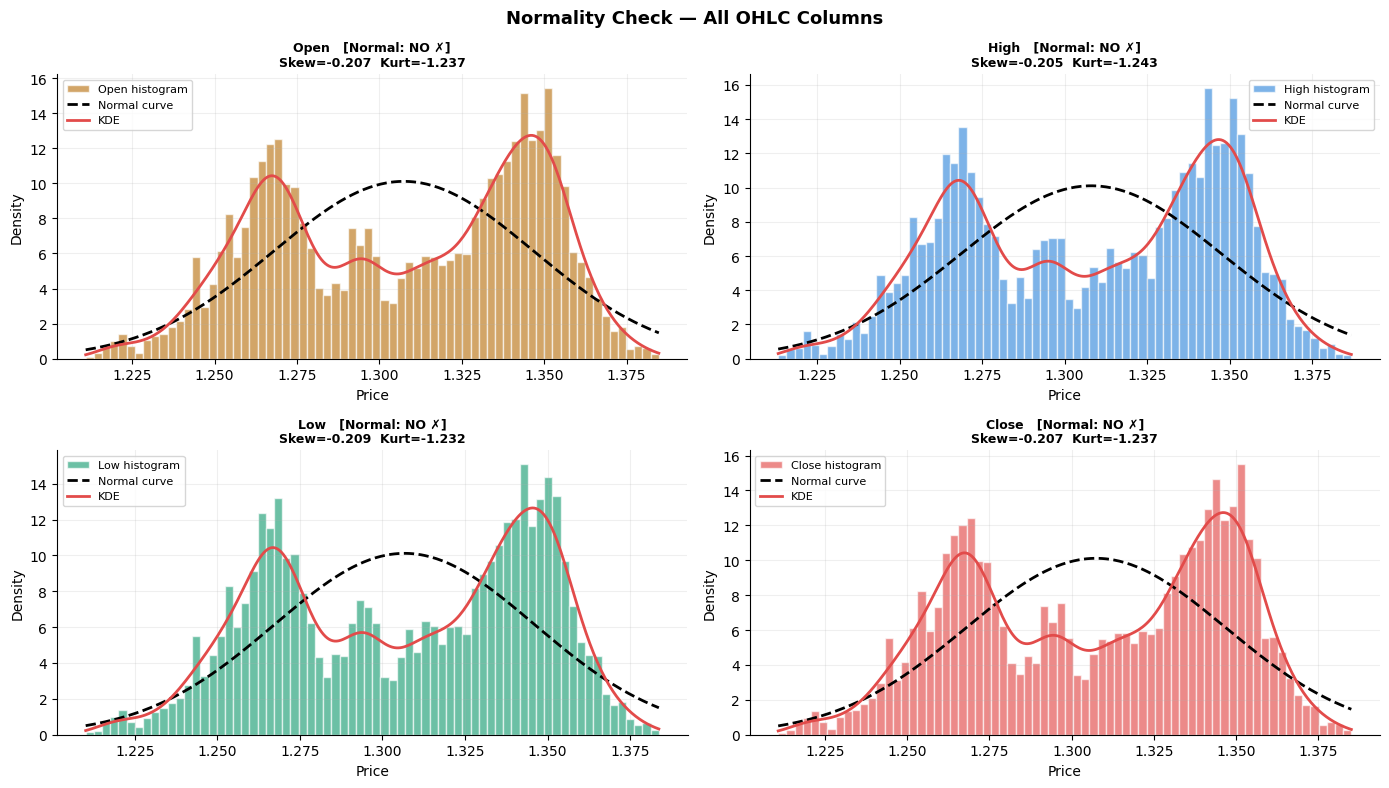

  [Fig 4] Saved → plots/04_ohlc_distributions.png


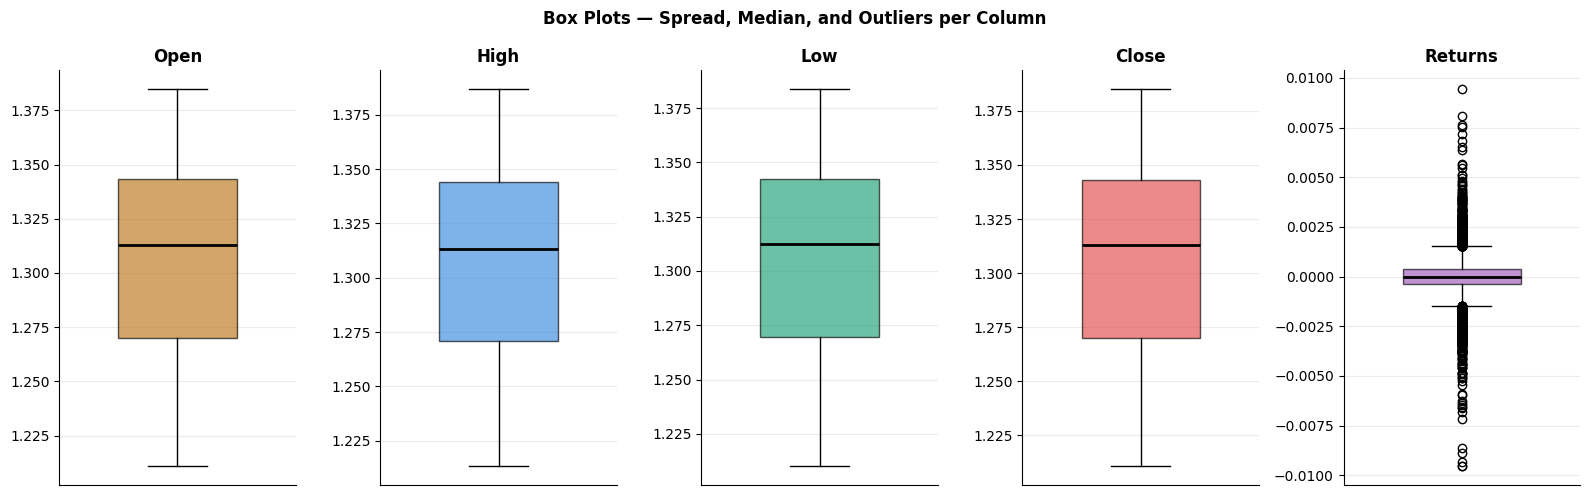

  [Fig 5] Saved → plots/05_boxplots.png

NORMALITY SUMMARY
  Column       Normal?      Skewness   Kurtosis
  ---------------------------------------------
  Close        NO ✗          -0.2070    -1.2373
  Open         NO ✗          -0.2070    -1.2370
  High         NO ✗          -0.2053    -1.2426
  Low          NO ✗          -0.2087    -1.2322
  Returns      NO ✗          -0.3227    11.6741


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import os

# Setup
PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Calculate returns
returns = df["Close"].pct_change().dropna()
test_targets = {
    "Close": df["Close"].values,
    "Open": df["Open"].values,
    "High": df["High"].values,
    "Low": df["Low"].values,
    "Returns": returns.values
}

SAMPLE_SIZE = 5000
normality_results = {}

# Print header
print(f"  {'Column':<12} {'Shapiro p':>12} {'D\'Agostino p':>15} {'Skewness':>10} {'Kurtosis':>10} {'Normal?':>10}")
print("  " + "-" * 72)

# Normality tests
for col, arr in test_targets.items():
    arr = arr[~np.isnan(arr)]
    sample = arr if len(arr) <= SAMPLE_SIZE else np.random.default_rng(42).choice(arr, SAMPLE_SIZE, replace=False)
    sw_p = stats.shapiro(sample)[1]
    da_p = stats.normaltest(arr)[1]
    skew, kurt = float(stats.skew(arr)), float(stats.kurtosis(arr))
    is_normal = (sw_p >= 0.05) and (da_p >= 0.05)
    normality_results[col] = {"Shapiro p": sw_p, "DAgostino p": da_p, "Skewness": skew, "Kurtosis": kurt, "Normal": is_normal}
    print(f"  {col:<12} {sw_p:>12.4e} {da_p:>15.4e} {skew:>10.4f} {kurt:>10.4f} {'YES' if is_normal else 'NO ✗':>10}")

# FIGURE 1: Close Price Distribution
fig, ax = plt.subplots(figsize=(10, 5))
close_vals = df["Close"].values
ax.hist(close_vals, bins=80, color="#378ADD", alpha=0.65, edgecolor="white", density=True, label="Close histogram")
mu, sigma = close_vals.mean(), close_vals.std()
x_range = np.linspace(close_vals.min(), close_vals.max(), 300)
ax.plot(x_range, stats.norm.pdf(x_range, mu, sigma), color="#E24B4A", lw=2.5, linestyle="--", label="Normal curve")
ax.plot(x_range, stats.gaussian_kde(close_vals)(x_range), color="#1D9E75", lw=2.5, label="KDE")
ax.set_title("Close Price Distribution vs Normal Curve", fontsize=13, fontweight="bold")
ax.set_xlabel("GBP/USD Close Price")
ax.set_ylabel("Density")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "01_close_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 1] Saved → {os.path.join(PLOTS_DIR, '01_close_distribution.png')}")

# FIGURE 2: Returns Distribution
fig, ax = plt.subplots(figsize=(10, 5))
ret_vals = returns.values
ax.hist(ret_vals, bins=100, color="#1D9E75", alpha=0.65, edgecolor="white", density=True, label="Hourly returns histogram")
mu_r, sigma_r = ret_vals.mean(), ret_vals.std()
x_r = np.linspace(ret_vals.min(), ret_vals.max(), 400)
ax.plot(x_r, stats.norm.pdf(x_r, mu_r, sigma_r), color="#E24B4A", lw=2.5, linestyle="--", label=f"Normal curve")
ax.plot(x_r, stats.gaussian_kde(ret_vals)(x_r), color="#378ADD", lw=2.5, label="KDE")
ax.set_title("Hourly Returns Distribution vs Normal Curve", fontsize=12, fontweight="bold")
ax.set_xlabel("Hourly Return")
ax.set_ylabel("Density")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "02_returns_distribution.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 2] Saved → {os.path.join(PLOTS_DIR, '02_returns_distribution.png')}")

# FIGURE 3: Q-Q Plots
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q-Q Plots: Quantiles vs Theoretical Normal Distribution", fontsize=12, fontweight="bold")

for ax, arr, title, color in [
    (ax_l, close_vals, "Close Price", "#378ADD"),
    (ax_r, ret_vals, "Hourly Returns", "#1D9E75"),
]:
    osm, osr = stats.probplot(arr, dist="norm")[0]
    slope, intercept, _ = stats.probplot(arr, dist="norm")[1]
    ax.scatter(osm, osr, s=4, alpha=0.35, color=color, label="Data quantiles")
    line_x = np.array([osm.min(), osm.max()])
    ax.plot(line_x, slope * line_x + intercept, color="#E24B4A", lw=2, label="Normal reference line")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Theoretical Quantiles (Normal)")
    ax.set_ylabel("Sample Quantiles")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "03_qq_plots.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 3] Saved → {os.path.join(PLOTS_DIR, '03_qq_plots.png')}")

# FIGURE 4: OHLC Distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Normality Check — All OHLC Columns", fontsize=13, fontweight="bold")
axes = axes.flatten()

plot_cols = ["Open", "High", "Low", "Close"]
col_colors = ["#BA7517", "#378ADD", "#1D9E75", "#E24B4A"]

for ax, col, c in zip(axes, plot_cols, col_colors):
    arr = df[col].values
    ax.hist(arr, bins=70, color=c, alpha=0.65, edgecolor="white", density=True, label=f"{col} histogram")
    mu_, s_ = arr.mean(), arr.std()
    xr = np.linspace(arr.min(), arr.max(), 300)
    ax.plot(xr, stats.norm.pdf(xr, mu_, s_), color="black", lw=2, linestyle="--", label="Normal curve")
    ax.plot(xr, stats.gaussian_kde(arr)(xr), color="#E24B4A", lw=2, label="KDE")
    r = normality_results[col]
    verdict = "Normal: NO ✗" if not r["Normal"] else "Normal: YES"
    ax.set_title(f"{col}   [{verdict}]\nSkew={r['Skewness']:.3f}  Kurt={r['Kurtosis']:.3f}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Price")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "04_ohlc_distributions.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 4] Saved → {os.path.join(PLOTS_DIR, '04_ohlc_distributions.png')}")

# FIGURE 5: Box Plots
fig, axes = plt.subplots(1, 5, figsize=(16, 5))
fig.suptitle("Box Plots — Spread, Median, and Outliers per Column", fontsize=12, fontweight="bold")

bp_data = [df["Open"].values, df["High"].values, df["Low"].values, df["Close"].values, returns.values]
bp_labels = ["Open", "High", "Low", "Close", "Returns"]
bp_colors = ["#BA7517", "#378ADD", "#1D9E75", "#E24B4A", "#9B59B6"]

for ax, data, label, c in zip(axes, bp_data, bp_labels, bp_colors):
    bp = ax.boxplot(data, patch_artist=True, widths=0.5, medianprops=dict(color="black", lw=2))
    bp["boxes"][0].set_facecolor(c)
    bp["boxes"][0].set_alpha(0.65)
    ax.set_title(label, fontweight="bold")
    ax.set_xticks([])
    ax.grid(True, axis="y", alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "05_boxplots.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"  [Fig 5] Saved → {os.path.join(PLOTS_DIR, '05_boxplots.png')}")

# Print summary
print("\n" + "=" * 70)
print("NORMALITY SUMMARY")
print("=" * 70)
print(f"  {'Column':<12} {'Normal?':<10} {'Skewness':>10} {'Kurtosis':>10}")
print("  " + "-" * 45)
for col, r in normality_results.items():
    print(f"  {col:<12} {'YES' if r['Normal'] else 'NO ✗':<10} {r['Skewness']:>10.4f} {r['Kurtosis']:>10.4f}")

**EXPLORATORY DATA ANALYSIS PLOT**


[STEP 3]  Plotting raw data overview ...


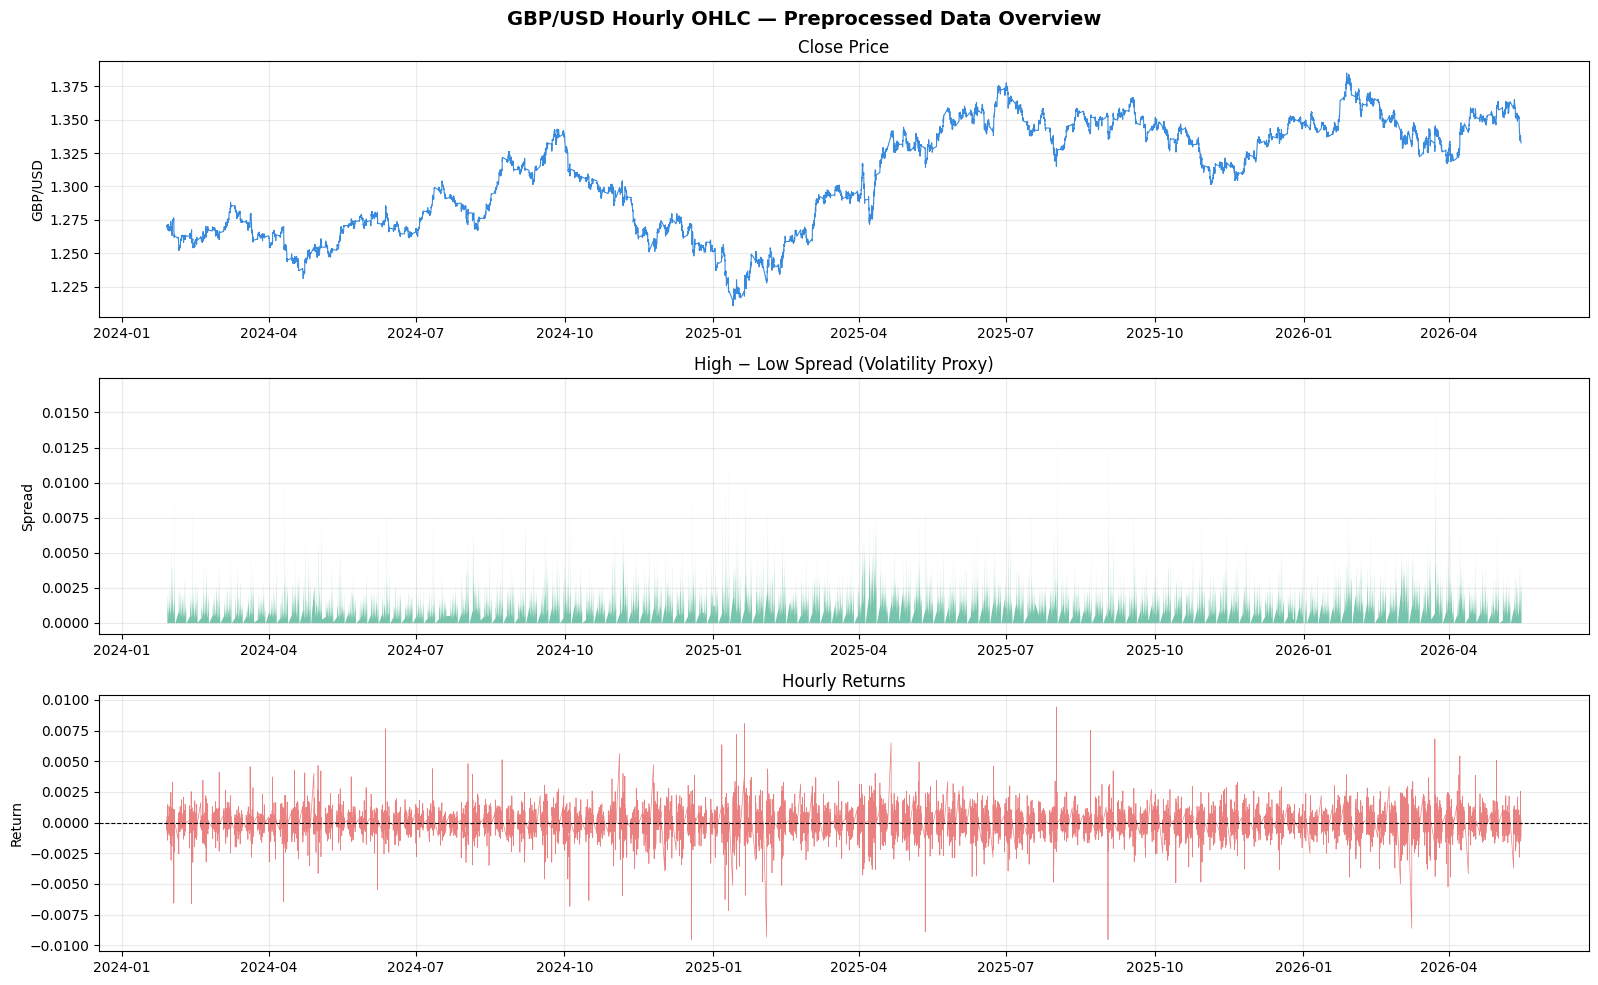

  Saved  →  plots/00_data_overview.png


In [28]:
import os

print("\n[STEP 3]  Plotting raw data overview ...")

os.makedirs(PLOTS_DIR, exist_ok=True)

fig, axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle("GBP/USD Hourly OHLC — Preprocessed Data Overview",
             fontsize=14, fontweight="bold")

# Close price
axes[0].plot(df.index, df["Close"], color="#378ADD", linewidth=0.8)
axes[0].set_title("Close Price")
axes[0].set_ylabel("GBP/USD")
axes[0].grid(True, alpha=0.25)

# High - Low spread
axes[1].fill_between(df.index,
                     df["High"] - df["Low"],
                     color="#1D9E75", alpha=0.6, linewidth=0)
axes[1].set_title("High − Low Spread (Volatility Proxy)")
axes[1].set_ylabel("Spread")
axes[1].grid(True, alpha=0.25)

# Hourly returns
ret = df["Close"].pct_change().dropna()
axes[2].plot(df.index[1:], ret, color="#E24B4A", linewidth=0.5, alpha=0.7)
axes[2].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[2].set_title("Hourly Returns")
axes[2].set_ylabel("Return")
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
path = os.path.join(PLOTS_DIR, "00_data_overview.png")
plt.savefig(path, bbox_inches="tight", dpi=150)
plt.show()
print(f"  Saved  →  {path}")

**Feature engineering**

In [29]:
print("\n" + "=" * 70)
print("  FEATURE ENGINEERING  (18 features — standard forex sequential set)")
print("=" * 70)

fe = df.copy()

# ── 1. Return & candle structure ─────────────────────────────────────────────
fe["returns"]    = fe["Close"].pct_change()            # hourly % return
fe["hl_spread"]  = fe["High"] - fe["Low"]             # intra-hour range
fe["oc_spread"]  = fe["Close"] - fe["Open"]           # candle body direction

# ── 2. Trend: moving averages ─────────────────────────────────────────────────
fe["sma_10"]     = fe["Close"].rolling(10).mean()      # short-term trend
fe["sma_24"]     = fe["Close"].rolling(24).mean()      # daily trend
fe["ema_12"]     = fe["Close"].ewm(span=12, adjust=False).mean()
fe["ema_26"]     = fe["Close"].ewm(span=26, adjust=False).mean()  # NEW

# ── 3. MACD  (most used momentum indicator in forex) ─────────────────────────
fe["macd"]       = fe["ema_12"] - fe["ema_26"]         # NEW: MACD line
fe["macd_signal"]= fe["macd"].ewm(span=9, adjust=False).mean()  # NEW: signal
fe["macd_hist"]  = fe["macd"] - fe["macd_signal"]      # NEW: histogram

# ── 4. Momentum ───────────────────────────────────────────────────────────────
fe["momentum"]   = fe["Close"] - fe["Close"].shift(4)  # 4h absolute momentum
fe["roc_8"]      = fe["Close"].pct_change(8)            # NEW: 8h rate of change
fe["volatility"] = fe["returns"].rolling(12).std()      # 12h rolling volatility

# ── 5. RSI-14  (overbought / oversold) ───────────────────────────────────────
delta            = fe["Close"].diff()
gain             = delta.clip(lower=0).rolling(14).mean()
loss             = (-delta.clip(upper=0)).rolling(14).mean()
fe["rsi_14"]     = 100 - (100 / (1 + gain / (loss + 1e-9)))

# ── 6. Williams %R-14  (overbought/oversold — more sensitive than RSI) ───────
# NEW: ranges from -100 (oversold) to 0 (overbought)
highest_high     = fe["High"].rolling(14).max()
lowest_low       = fe["Low"].rolling(14).min()
fe["williams_r"] = -100 * (highest_high - fe["Close"]) / \
                   (highest_high - lowest_low + 1e-9)

# ── 7. ATR-14  (Average True Range — volatility with gap handling) ────────────
# NEW: standard risk/volatility measure used in all forex studies
prev_close       = fe["Close"].shift(1)
tr               = pd.concat([
    fe["High"] - fe["Low"],
    (fe["High"] - prev_close).abs(),
    (fe["Low"]  - prev_close).abs(),
], axis=1).max(axis=1)
fe["atr_14"]     = tr.rolling(14).mean()

# ── 8. Bollinger Band position ────────────────────────────────────────────────
bb_mid           = fe["Close"].rolling(20).mean()
bb_std           = fe["Close"].rolling(20).std()
fe["bb_pos"]     = (fe["Close"] - bb_mid) / (2 * bb_std + 1e-9)  # -1..+1

# ── 9. Lagged returns  (explicit direction memory for the model) ──────────────
fe["ret_lag1"]   = fe["returns"].shift(1)
fe["ret_lag2"]   = fe["returns"].shift(2)
fe["ret_lag3"]   = fe["returns"].shift(3)

# ── 10. Trend strength ────────────────────────────────────────────────────────
fe["price_sma_ratio"] = fe["Close"] / (fe["sma_24"] + 1e-9) - 1.0

# ── 11. Time-of-day & day-of-week  (session effects — NEW) ───────────────────
# GBP/USD hourly has strong London (9AM) and NY (2PM) session patterns.
# Encoded as sine/cosine to preserve cyclical continuity
# (so hour 23 is "close to" hour 0, not far away like a raw integer would imply)
hour             = fe.index.hour
dow              = fe.index.dayofweek                  # 0=Monday … 4=Friday
fe["hour_sin"]   = np.sin(2 * np.pi * hour / 24)
fe["hour_cos"]   = np.cos(2 * np.pi * hour / 24)
fe["dow_sin"]    = np.sin(2 * np.pi * dow  / 5)
fe["dow_cos"]    = np.cos(2 * np.pi * dow  / 5)

fe.dropna(inplace=True)

FEATURES = [
    # Raw candle
    "Open", "High", "Low", "Close",
    # Return & spread
    "returns", "hl_spread", "oc_spread",
    # Trend
    "sma_10", "sma_24", "ema_12", "ema_26",
    # MACD
    "macd", "macd_signal", "macd_hist",
    # Momentum & volatility
    "momentum", "roc_8", "volatility",
    # Oscillators
    "rsi_14", "williams_r",
    # Volatility (true range based)
    "atr_14",
    # Band position
    "bb_pos",
    # Direction memory
    "ret_lag1", "ret_lag2", "ret_lag3",
    # Trend strength
    "price_sma_ratio",
    # Session effects (cyclical encoding)
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
]

CLOSE_IDX = FEATURES.index("Close")

print(f"  Total features : {len(FEATURES)}")
categories = {
    "Raw candle":         ["Open","High","Low","Close"],
    "Return & spread":    ["returns","hl_spread","oc_spread"],
    "Trend (MA)":         ["sma_10","sma_24","ema_12","ema_26"],
    "MACD":               ["macd","macd_signal","macd_hist"],
    "Momentum/Vol":       ["momentum","roc_8","volatility"],
    "Oscillators":        ["rsi_14","williams_r"],
    "True volatility":    ["atr_14"],
    "Band position":      ["bb_pos"],
    "Direction memory":   ["ret_lag1","ret_lag2","ret_lag3"],
    "Trend strength":     ["price_sma_ratio"],
    "Session effects":    ["hour_sin","hour_cos","dow_sin","dow_cos"],
}
new_features = {"ema_26","macd","macd_signal","macd_hist",
                "roc_8","williams_r","atr_14",
                "hour_sin","hour_cos","dow_sin","dow_cos"}

for cat, feats in categories.items():
    print(f"\n  {cat}:")
    for f in feats:
        tag = "  ← NEW" if f in new_features else ""
        print(f"    {f}{tag}")
print(f"\n  Rows after feature engineering : {len(fe):,}")


  FEATURE ENGINEERING  (18 features — standard forex sequential set)
  Total features : 29

  Raw candle:
    Open
    High
    Low
    Close

  Return & spread:
    returns
    hl_spread
    oc_spread

  Trend (MA):
    sma_10
    sma_24
    ema_12
    ema_26  ← NEW

  MACD:
    macd  ← NEW
    macd_signal  ← NEW
    macd_hist  ← NEW

  Momentum/Vol:
    momentum
    roc_8  ← NEW
    volatility

  Oscillators:
    rsi_14
    williams_r  ← NEW

  True volatility:
    atr_14  ← NEW

  Band position:
    bb_pos

  Direction memory:
    ret_lag1
    ret_lag2
    ret_lag3

  Trend strength:
    price_sma_ratio

  Session effects:
    hour_sin  ← NEW
    hour_cos  ← NEW
    dow_sin  ← NEW
    dow_cos  ← NEW

  Rows after feature engineering : 14,368


**Normalize features**

In [31]:
print("  NORMALISATION  (RobustScaler — outlier-resistant)")
print("=" * 70)
print("""
  Why RobustScaler instead of MinMaxScaler?
  ------------------------------------------
  MinMaxScaler maps [min, max] → [0, 1].
  A single extreme price spike compresses all other values into a tiny range.
  Our normality test confirmed GBP/USD returns are leptokurtic (fat tails)
  — meaning extreme values occur regularly.

  RobustScaler maps using median and IQR:
      scaled = (x - median) / IQR
  This makes the scaling insensitive to outliers.
  Recommended for financial time series in the literature.
""")

# Determine split point on the raw feature array
n_total = len(fe)
n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)
n_test  = n_total - n_train - n_val

# Fit scaler ONLY on training rows — never let val/test influence scaling
scaler     = RobustScaler()
train_raw  = fe[FEATURES].values[:n_train]
scaler.fit(train_raw)

scaled = scaler.transform(fe[FEATURES].values)

# Split scaled array for range verification
train_sc = scaled[:n_train]
val_sc   = scaled[n_train : n_train + n_val]
test_sc  = scaled[n_train + n_val:]

print(f"  Scaler         : RobustScaler  (median + IQR, no min/max sensitivity)")
print(f"  Fitted on      : training rows only  ({n_train:,} rows)")
print(f"  Scaled shape   : {scaled.shape}")
print(f"\n  Range check per split (values outside training range = expected in forex):")
print(f"  {'Split':<12} {'Min':>10} {'Max':>10} {'Out-of-range cols':>20}")
print("  " + "-" * 56)
for label, arr in [("Train", train_sc), ("Validation", val_sc), ("Test", test_sc)]:
    # Count columns where any value falls outside [-5, 5]
    # (RobustScaler output is centred at 0; ±5 is a reasonable bound)
    out_of_range = int((np.abs(arr) > 5).any(axis=0).sum())
    print(f"  {label:<12} {arr.min():>10.4f} {arr.max():>10.4f} "
          f"{out_of_range:>20} / {len(FEATURES)}")

print(f"\n  Note: out-of-range values in val/test are expected — they represent")
print(f"  price levels the model has not seen during training. Dropout and")
print(f"  EarlyStopping help the model generalise to these unseen ranges.")

  NORMALISATION  (RobustScaler — outlier-resistant)

  Why RobustScaler instead of MinMaxScaler?
  ------------------------------------------
  MinMaxScaler maps [min, max] → [0, 1].
  A single extreme price spike compresses all other values into a tiny range.
  Our normality test confirmed GBP/USD returns are leptokurtic (fat tails)
  — meaning extreme values occur regularly.

  RobustScaler maps using median and IQR:
      scaled = (x - median) / IQR
  This makes the scaling insensitive to outliers.
  Recommended for financial time series in the literature.

  Scaler         : RobustScaler  (median + IQR, no min/max sensitivity)
  Fitted on      : training rows only  (10,057 rows)
  Scaled shape   : (14368, 29)

  Range check per split (values outside training range = expected in forex):
  Split               Min        Max    Out-of-range cols
  --------------------------------------------------------
  Train          -13.7730    13.3357                    9 / 29
  Validation      -

**SEQUENCE CREATION  (sliding window — lookback = 24 hours)**

In [32]:
print(f"\n{'='*70}\n  SEQUENCE CREATION  (lookback={LOOKBACK}h)\n{'='*70}")

def create_sequences(data, lookback, target_idx):
    """Vectorised sliding window — faster than a Python loop."""
    n_rows, n_feat = data.shape
    n_samples      = n_rows - lookback
    shape   = (n_samples, lookback, n_feat)
    strides = (data.strides[0], data.strides[0], data.strides[1])
    X = np.array(np.lib.stride_tricks.as_strided(data, shape, strides),
                 dtype=np.float32)          # copy so memory is safe to modify
    y = data[lookback:, target_idx].astype(np.float32)
    return X, y

X, y = create_sequences(scaled, LOOKBACK, CLOSE_IDX)
print(f"  X : {X.shape}  ({X.nbytes/1e6:.1f} MB)")
print(f"  y : {y.shape}")


  SEQUENCE CREATION  (lookback=48h)
  X : (14320, 48, 29)  (79.7 MB)
  y : (14320,)


**Train / Validation / Test split**

In [33]:
print("\n" + "=" * 70)
print("  TRAIN / VAL / TEST SPLIT  (chronological — no shuffle)")
print("=" * 70)

n       = len(X)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
n_test  = n - n_train - n_val

X_train, y_train = X[:n_train],               y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val],  y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],         y[n_train+n_val:]

INPUT_SHAPE = (LOOKBACK, len(FEATURES))

# Boundary leakage check — last train index must be before first val index
assert n_train < n_train + n_val < n, "Split boundaries overlap — data leakage!"

print(f"  Total samples : {n:,}")
print(f"  +------------------+--------+------------+")
print(f"  | Split            | Ratio  |    Samples |")
print(f"  +------------------+--------+------------+")
print(f"  | Train            |  70 %  | {X_train.shape[0]:>10,} |")
print(f"  | Validation       |  15 %  | {X_val.shape[0]:>10,} |")
print(f"  | Test (held-out)  |  15 %  | {X_test.shape[0]:>10,} |")
print(f"  +------------------+--------+------------+")
print(f"  Input shape per sample : {INPUT_SHAPE}")


  TRAIN / VAL / TEST SPLIT  (chronological — no shuffle)
  Total samples : 14,320
  +------------------+--------+------------+
  | Split            | Ratio  |    Samples |
  +------------------+--------+------------+
  | Train            |  70 %  |     10,024 |
  | Validation       |  15 %  |      2,148 |
  | Test (held-out)  |  15 %  |      2,148 |
  +------------------+--------+------------+
  Input shape per sample : (48, 29)


# **MODEL**

**MODEL ARCHITECTURE DEFINITIONS**

In [34]:
# ── Custom loss: MSE + direction penalty ─────────────────────────────────────
DA_ALPHA = 0.45   # 45% direction penalty, 55% price MSE

def da_weighted_loss(alpha=DA_ALPHA):
    import tensorflow as tf
    def loss(y_true, y_pred):
        mse       = tf.reduce_mean(tf.square(y_true - y_pred))
        dt        = tf.clip_by_value(y_true[1:] - y_true[:-1], -1e3, 1e3)
        dp        = tf.clip_by_value(y_pred[1:] - y_pred[:-1], -1e3, 1e3)
        dir_pen   = tf.reduce_mean(tf.maximum(0.0, -(dt * dp)))
        return (1.0 - alpha) * mse + alpha * dir_pen
    loss.__name__ = "da_weighted_loss"
    return loss

# ── Shared compile helper ─────────────────────────────────────────────────────
def _compile(model, lr):
    model.compile(
        optimizer=Adam(lr, clipnorm=1.0),   # clipnorm prevents exploding gradients
        loss=da_weighted_loss(DA_ALPHA),
        metrics=["mae"]
    )
    return model

# ── Shared architecture: 2 recurrent layers → Dense(32) → Dense(1) ───────────
def build_lstm(input_shape, units, dropout, lr):
    m = Sequential(name="LSTM")
    m.add(LSTM(units, return_sequences=True, input_shape=input_shape))
    m.add(Dropout(dropout))
    m.add(LSTM(units, return_sequences=False))
    m.add(Dropout(dropout))
    m.add(Dense(32, activation="relu"))
    m.add(Dense(1))
    return _compile(m, lr)

def build_gru(input_shape, units, dropout, lr):
    m = Sequential(name="GRU")
    m.add(GRU(units, return_sequences=True, input_shape=input_shape))
    m.add(Dropout(dropout))
    m.add(GRU(units, return_sequences=False))
    m.add(Dropout(dropout))
    m.add(Dense(32, activation="relu"))
    m.add(Dense(1))
    return _compile(m, lr)

def build_bilstm(input_shape, units, dropout, lr):
    m = Sequential(name="BiLSTM")
    m.add(Bidirectional(LSTM(units, return_sequences=True), input_shape=input_shape))
    m.add(Dropout(dropout))
    m.add(Bidirectional(LSTM(units // 2, return_sequences=False)))  # units//2 keeps params comparable
    m.add(Dropout(dropout))
    m.add(Dense(32, activation="relu"))
    m.add(Dense(1))
    return _compile(m, lr)

def build_rnn(input_shape, units, dropout, lr):
    m = Sequential(name="Vanilla_RNN")
    m.add(SimpleRNN(units, return_sequences=True, input_shape=input_shape))
    m.add(Dropout(dropout))
    m.add(SimpleRNN(units, return_sequences=False))
    m.add(Dropout(dropout))
    m.add(Dense(32, activation="relu"))
    m.add(Dense(1))
    return _compile(m, lr)   # clipnorm especially important for RNN (no gating)

print(f"  Models defined : LSTM | GRU | BiLSTM | Vanilla_RNN")
print(f"  Loss           : DA-Weighted (alpha={DA_ALPHA} = {int(DA_ALPHA*100)}% direction + {int((1-DA_ALPHA)*100)}% MSE)")
print(f"  Optimizer      : Adam  clipnorm=1.0")
print(f"  Architecture   : 2 recurrent layers → Dropout → Dense(32) → Dense(1)")

  Models defined : LSTM | GRU | BiLSTM | Vanilla_RNN
  Loss           : DA-Weighted (alpha=0.45 = 45% direction + 55% MSE)
  Optimizer      : Adam  clipnorm=1.0
  Architecture   : 2 recurrent layers → Dropout → Dense(32) → Dense(1)


**SHARED HELPER FUNCTIONS**

In [35]:
_C_ACTUAL = "#111111"   # black  — actual price
_C_TRAIN  = "#2CA02C"   # green  — train predictions / train loss
_C_VAL    = "#FF7F0E"   # orange — validation predictions / val loss
_C_ZERO   = "#E24B4A"   # red    — zero residual reference
_LW_A     = 1.6         # actual line width
_LW_P     = 1.2         # predicted line width

results = {}   # populated after each model completes


def inverse_close(scaled_vals):
    """Invert RobustScaler for Close column only."""
    dummy = np.zeros((len(scaled_vals), len(FEATURES)))
    dummy[:, CLOSE_IDX] = scaled_vals
    return scaler.inverse_transform(dummy)[:, CLOSE_IDX]


def compute_metrics(actual, preds):
    """Return RMSE, MAE, MAPE, NRMSE, DA for any split."""
    rmse  = float(np.sqrt(mean_squared_error(actual, preds)))
    mae   = float(mean_absolute_error(actual, preds))
    mape  = float(np.mean(np.abs((actual - preds) / (actual + 1e-9))) * 100)
    nrmse = float(rmse / (actual.max() - actual.min() + 1e-9) * 100)
    da    = float(np.mean(np.sign(np.diff(actual)) == np.sign(np.diff(preds))) * 100)
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "NRMSE (%)": nrmse, "DA (%)": da}


def run_inference(model, X, y):
    """Predict on any split → (preds_price, actual_price, metrics)."""
    preds  = inverse_close(model.predict(X, verbose=0).flatten())
    actual = inverse_close(y)
    return preds, actual, compute_metrics(actual, preds)


def train_model(model, name, X_tr, y_tr, X_v, y_v):
    """Train with EarlyStopping + ReduceLROnPlateau + ModelCheckpoint."""
    cbs = [
        EarlyStopping(monitor="val_loss", patience=PATIENCE,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=7, min_lr=1e-6, verbose=0),
        ModelCheckpoint(os.path.join(MODELS_DIR, f"{name}_best.weights.h5"),
                        monitor="val_loss", save_best_only=True,
                        save_weights_only=True, verbose=0),
    ]
    t0      = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_v, y_v),
                        epochs=EPOCHS, batch_size=BATCH_SIZE,
                        callbacks=cbs, verbose=1)
    elapsed  = time.time() - t0
    best_ep  = int(np.argmin(history.history["val_loss"])) + 1
    print(f"\n  Done | best epoch={best_ep} | "
          f"val_loss={min(history.history['val_loss']):.6f} | {elapsed:.1f}s")
    return history, elapsed


def _style(ax, title, xlabel="Hours", ylabel="GBP/USD", color="black"):
    ax.set_title(title, fontsize=10, fontweight="bold", color=color)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.18, linestyle="--", color="grey")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def _savefig(fig, path):
    fig.tight_layout()
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {path}")


def print_validation_report(name, val_preds, val_actual, val_metrics):
    """Print validation metrics. Warn if DA < 50% (worse than random)."""
    da_ok = val_metrics["DA (%)"] >= 50.0
    flag  = "OK" if da_ok else "LOW — worse than random!"
    print(f"\n  {'='*55}")
    print(f"  VALIDATION — {name}")
    print(f"  {'='*55}")
    for k, v in val_metrics.items():
        print(f"  {k:<12} : {v:.5f}")
    print(f"  DA status  : {flag}")
    print(f"  {'='*55}")
    return da_ok


def print_test_report(name, metrics, params, elapsed):
    """Print final test metrics."""
    da_flag = "GOOD" if metrics["DA (%)"] >= 50 else "CHECK"
    print(f"\n  {'='*55}")
    print(f"  TEST — {name}  ({params:,} params  {elapsed:.1f}s)")
    print(f"  {'='*55}")
    for k, v in metrics.items():
        print(f"  {k:<12} : {v:.5f}")
    print(f"  DA status  : {da_flag}")
    print(f"  {'='*55}\n")


def plot_individual_results(name, history,
                             train_preds, train_actual,
                             val_preds,   val_actual,
                             test_preds,  test_actual,
                             test_metrics, color):
    """6 separate figures: loss | train | val | test-full | test-zoom | scatter+residual."""
    plt.rcParams.update({"figure.dpi": 150, "font.size": 10})

    h       = history.history
    eps     = range(1, len(h["loss"]) + 1)
    m       = test_metrics
    val_m   = compute_metrics(val_actual, val_preds)
    tr_m    = compute_metrics(train_actual, train_preds)
    best_ep = int(np.argmin(h["val_loss"])) + 1
    da_col  = "darkgreen" if val_m["DA (%)"] >= 50 else "crimson"

    # Fig 1 — Loss curve
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(eps, h["loss"],     color=_C_TRAIN, lw=2.5, label=f"Train (final={h['loss'][-1]:.5f})")
    ax.plot(eps, h["val_loss"], color=_C_VAL,   lw=2.5, linestyle="--",
            label=f"Val (best={min(h['val_loss']):.5f})")
    ax.axvline(best_ep, color="grey", lw=1.4, linestyle=":", label=f"Best epoch={best_ep}")
    _style(ax, f"[{name}] Loss Curve — best val={min(h['val_loss']):.5f} @ ep {best_ep}",
           xlabel="Epoch", ylabel="DA-Weighted Loss")
    ax.legend(fontsize=9)
    _savefig(fig, os.path.join(PLOTS_DIR, f"{name}_1_loss.png"))

    # Fig 2 — Train predictions (last 500h)
    show = min(500, len(train_actual))
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(train_actual[-show:], color=_C_ACTUAL, lw=_LW_A, label="Actual")
    ax.plot(train_preds[-show:],  color=_C_TRAIN,  lw=_LW_P, label="Predicted", alpha=0.85)
    _style(ax, f"[{name}] Train (last {show}h) — RMSE={tr_m['RMSE']:.5f}  DA={tr_m['DA (%)']:.1f}%")
    ax.legend(fontsize=9)
    _savefig(fig, os.path.join(PLOTS_DIR, f"{name}_2_train.png"))

    # Fig 3 — Validation predictions
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(val_actual, color=_C_ACTUAL, lw=_LW_A, label="Actual")
    ax.plot(val_preds,  color=_C_VAL,    lw=_LW_P, label="Predicted", alpha=0.88)
    da_tag = "DA OK" if val_m["DA (%)"] >= 50 else "DA LOW"
    _style(ax, f"[{name}] Validation [{da_tag}] — RMSE={val_m['RMSE']:.5f}  DA={val_m['DA (%)']:.1f}%",
           color=da_col)
    ax.legend(fontsize=9)
    _savefig(fig, os.path.join(PLOTS_DIR, f"{name}_3_val.png"))

    # Fig 4 — Test full
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_actual, color=_C_ACTUAL, lw=_LW_A, label="Actual")
    ax.plot(test_preds,  color=color,     lw=_LW_P, label=f"Predicted ({name})", alpha=0.88)
    _style(ax, f"[{name}] Test Full — RMSE={m['RMSE']:.5f}  MAPE={m['MAPE']:.2f}%  DA={m['DA (%)']:.1f}%")
    ax.legend(fontsize=9)
    _savefig(fig, os.path.join(PLOTS_DIR, f"{name}_4_test_full.png"))

    # Fig 5 — Test zoomed (first 300h)
    Z = min(300, len(test_actual))
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_actual[:Z], color=_C_ACTUAL, lw=_LW_A + 0.2, label="Actual")
    ax.plot(test_preds[:Z],  color=color,     lw=_LW_P + 0.1, label=f"Predicted ({name})", alpha=0.88)
    _style(ax, f"[{name}] Test Zoomed (first {Z}h) — RMSE={m['RMSE']:.5f}  DA={m['DA (%)']:.1f}%")
    ax.legend(fontsize=9)
    _savefig(fig, os.path.join(PLOTS_DIR, f"{name}_5_test_zoom.png"))

    # Fig 6 — Scatter + Residual histogram
    residuals = test_preds - test_actual
    fig, (axl, axr) = plt.subplots(1, 2, figsize=(15, 5))

    # Scatter
    lo, hi = min(test_actual.min(), test_preds.min()), max(test_actual.max(), test_preds.max())
    axl.scatter(test_actual, test_preds, s=5, alpha=0.28, color=color)
    axl.plot([lo, hi], [lo, hi], color=_C_ACTUAL, lw=1.6, linestyle="--", label="Perfect fit")
    _style(axl, f"[{name}] Scatter — mean={residuals.mean():.5f}  std={residuals.std():.5f}",
           xlabel="Actual", ylabel="Predicted")
    axl.legend(fontsize=9)

    # Residual histogram
    axr.hist(residuals, bins=70, color=color, alpha=0.72, edgecolor="white")
    axr.axvline(0,               color=_C_ZERO, lw=2.0, linestyle="--", label="Zero")
    axr.axvline(residuals.mean(), color=_C_VAL,  lw=2.0, label=f"Mean={residuals.mean():.5f}")
    _style(axr, f"[{name}] Residuals — skew={float(stats.skew(residuals)):.3f}  "
                f"kurt={float(stats.kurtosis(residuals)):.3f}",
           xlabel="Residual", ylabel="Frequency")
    axr.legend(fontsize=9)

    _savefig(fig, os.path.join(PLOTS_DIR, f"{name}_6_scatter_residual.png"))

print("  Helpers defined: inverse_close | compute_metrics | run_inference |")
print("                   train_model | print_validation_report |")
print("                   print_test_report | plot_individual_results")

  Helpers defined: inverse_close | compute_metrics | run_inference |
                   train_model | print_validation_report |
                   print_test_report | plot_individual_results


**MODEL 1 — LSTM**

In [36]:
print("\n  [LSTM]  STEP 1 : BUILD")
print("  " + "-" * 55)
lstm_model = build_lstm(INPUT_SHAPE, UNITS, DROPOUT, LEARNING_RATE)
lstm_model.summary()
print(f"  Parameters : {lstm_model.count_params():,}")


  [LSTM]  STEP 1 : BUILD
  -------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 128)        │        80,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,641 (846.25 KB)

 Trainable params: 216,641 (846.25 KB)

 Non-trainable params: 0 (0.00 B)

  Parameters : 216,641


**LSTM Train**

In [37]:
print("\n  [LSTM]  STEP 2 : TRAIN")
print("  " + "-" * 55)
print(f"  Train={X_train.shape[0]:,}  Val={X_val.shape[0]:,}  "
      f"epochs={EPOCHS}  patience={PATIENCE}  batch={BATCH_SIZE}\n")
lstm_history, lstm_time = train_model(
    lstm_model, "LSTM", X_train, y_train, X_val, y_val
)


  [LSTM]  STEP 2 : TRAIN
  -------------------------------------------------------
  Train=10,024  Val=2,148  epochs=100  patience=15  batch=32

Epoch 1/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0075 - mae: 0.0729 - val_loss: 5.7932e-04 - val_mae: 0.0241 - learning_rate: 0.0010
Epoch 2/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0026 - mae: 0.0505 - val_loss: 8.1368e-04 - val_mae: 0.0312 - learning_rate: 0.0010
Epoch 3/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0019 - mae: 0.0429 - val_loss: 0.0030 - val_mae: 0.0654 - learning_rate: 0.0010
Epoch 4/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0017 - mae: 0.0400 - val_loss: 0.0011 - val_mae: 0.0388 - learning_rate: 0.0010
Epoch 5/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0014 - mae: 0.0370 - val_loss: 0.0018 - val_mae: 0.0523 - learning_rate: 0.0010
Epoch 6/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0015 - mae: 0.0380 - val_loss: 4.7834e-04 - val_mae: 0.0227 -

**LSTM VALIDATE  ← check metrics here before running t**

In [38]:
print("\n  [LSTM]  STEP 3 : VALIDATE")
print("  " + "-" * 55)
lstm_val_preds, lstm_val_actual, lstm_val_metrics = run_inference(
    lstm_model, X_val, y_val
)
lstm_val_ok = print_validation_report("LSTM", lstm_val_preds,
                                       lstm_val_actual, lstm_val_metrics)


  [LSTM]  STEP 3 : VALIDATE
  -------------------------------------------------------

  VALIDATION — LSTM
  RMSE         : 0.00119
  MAE          : 0.00088
  MAPE         : 0.06607
  NRMSE (%)    : 1.82662
  DA (%)       : 45.22590
  DA status  : LOW — worse than random!


**TEST**

In [39]:
print("\n  [LSTM]  STEP 4 : TEST  (held-out test set)")
print("  " + "-" * 55)
print(f"  Running inference on {X_test.shape[0]:,} unseen samples ...")
lstm_train_preds, lstm_train_actual, _ = run_inference(lstm_model, X_train, y_train)
lstm_test_preds,  lstm_test_actual, lstm_test_metrics = run_inference(
    lstm_model, X_test, y_test
)
print_test_report("LSTM", lstm_test_metrics, lstm_model.count_params(), lstm_time)


  [LSTM]  STEP 4 : TEST  (held-out test set)
  -------------------------------------------------------
  Running inference on 2,148 unseen samples ...

  TEST — LSTM  (216,641 params  139.2s)
  RMSE         : 0.00157
  MAE          : 0.00110
  MAPE         : 0.08124
  NRMSE (%)    : 2.31156
  DA (%)       : 46.39031
  DA status  : CHECK



**PLOT**

  [LSTM]  STEP 5 : PLOT
  -------------------------------------------------------


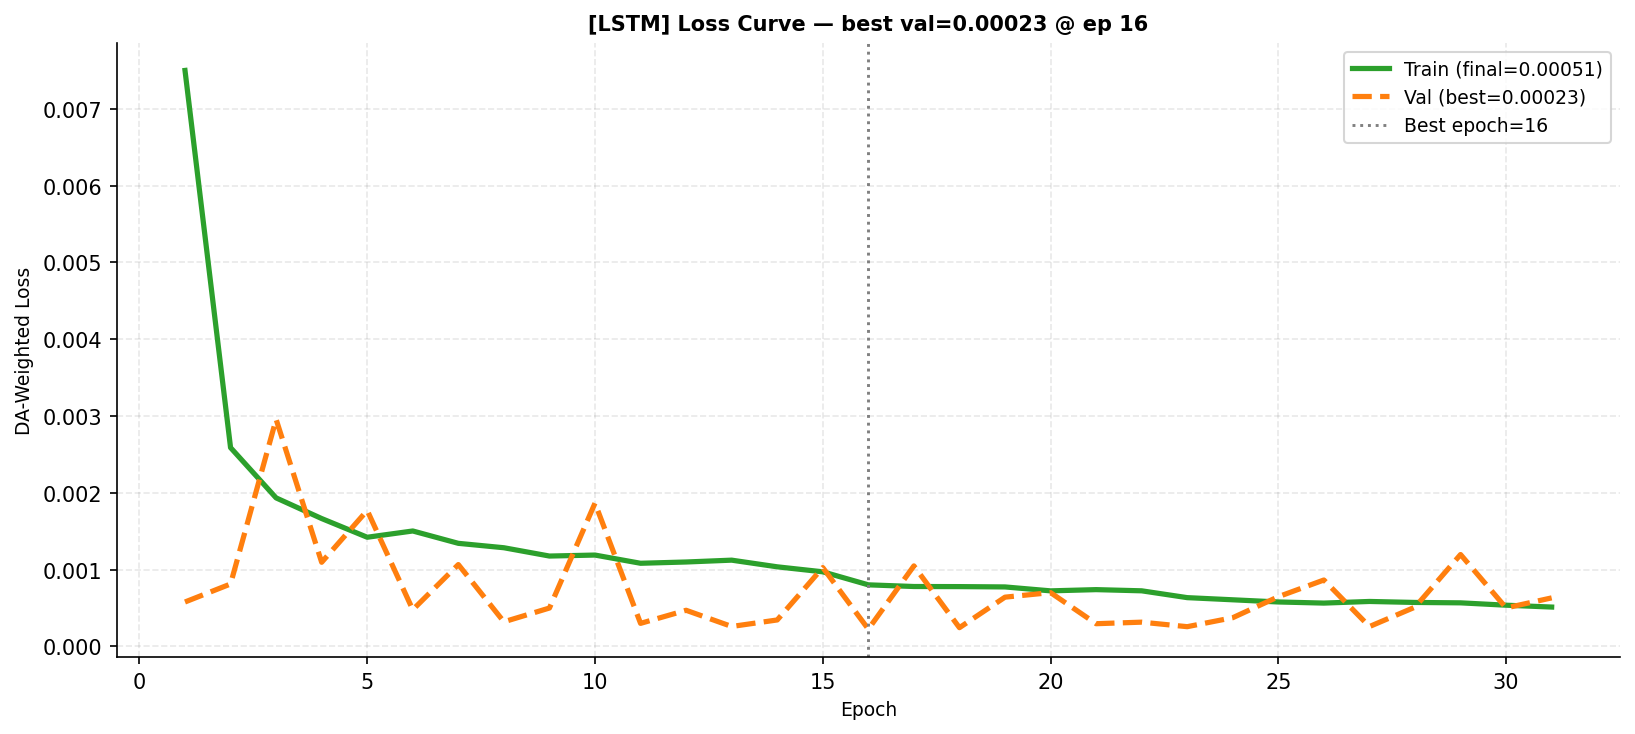

  Saved → plots/LSTM_1_loss.png


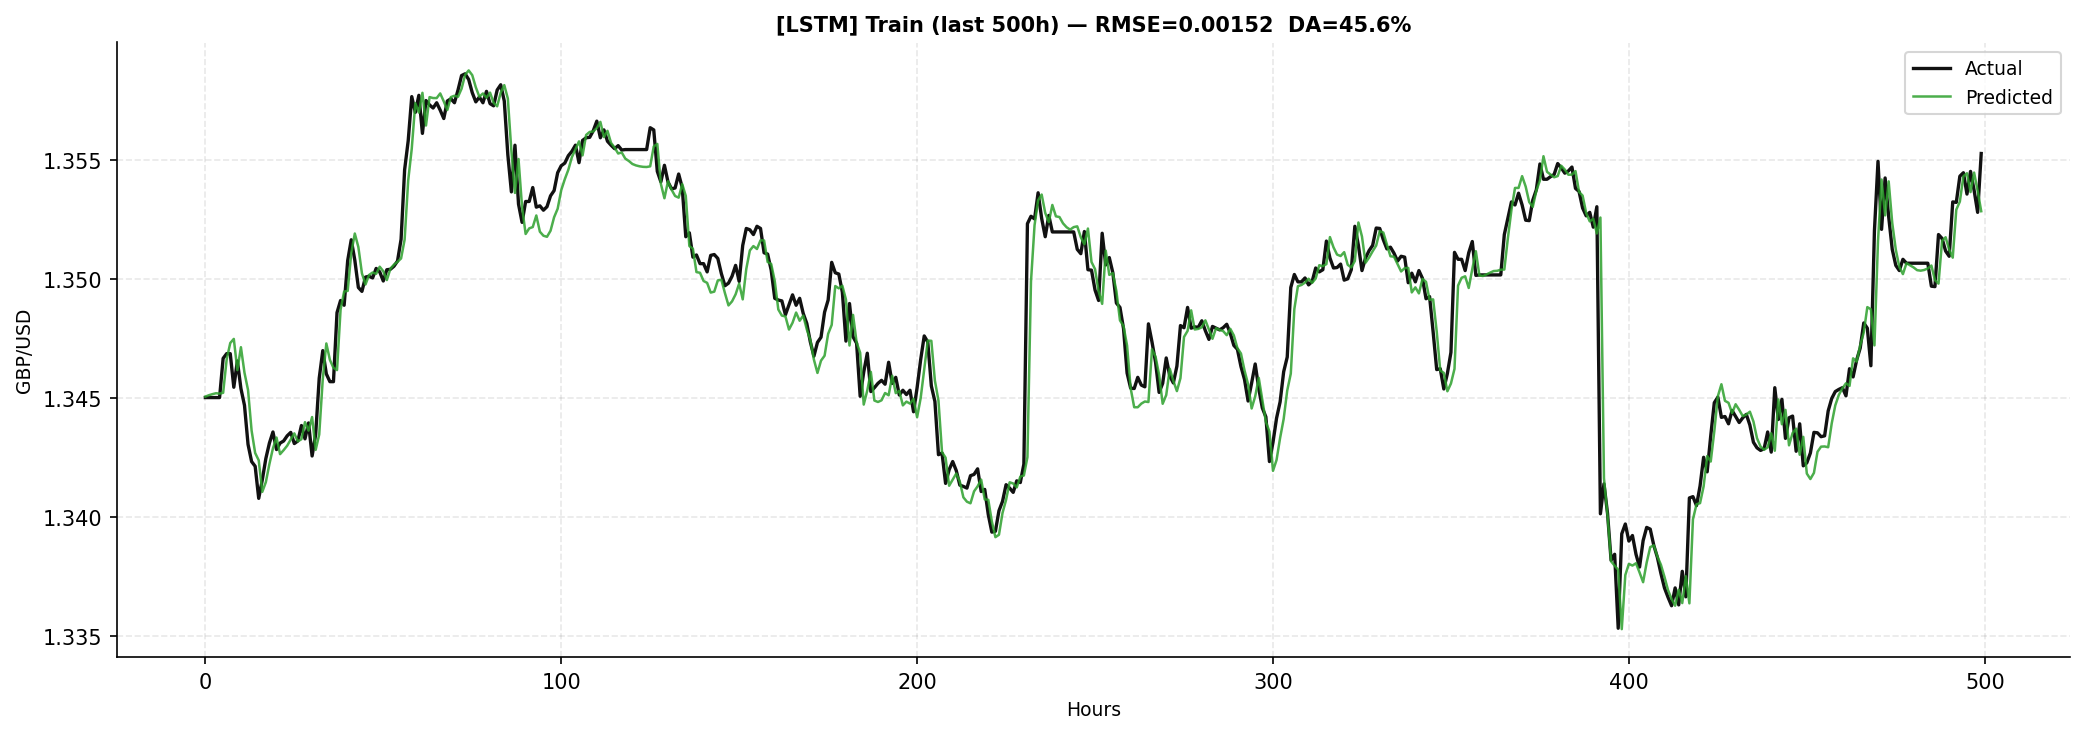

  Saved → plots/LSTM_2_train.png


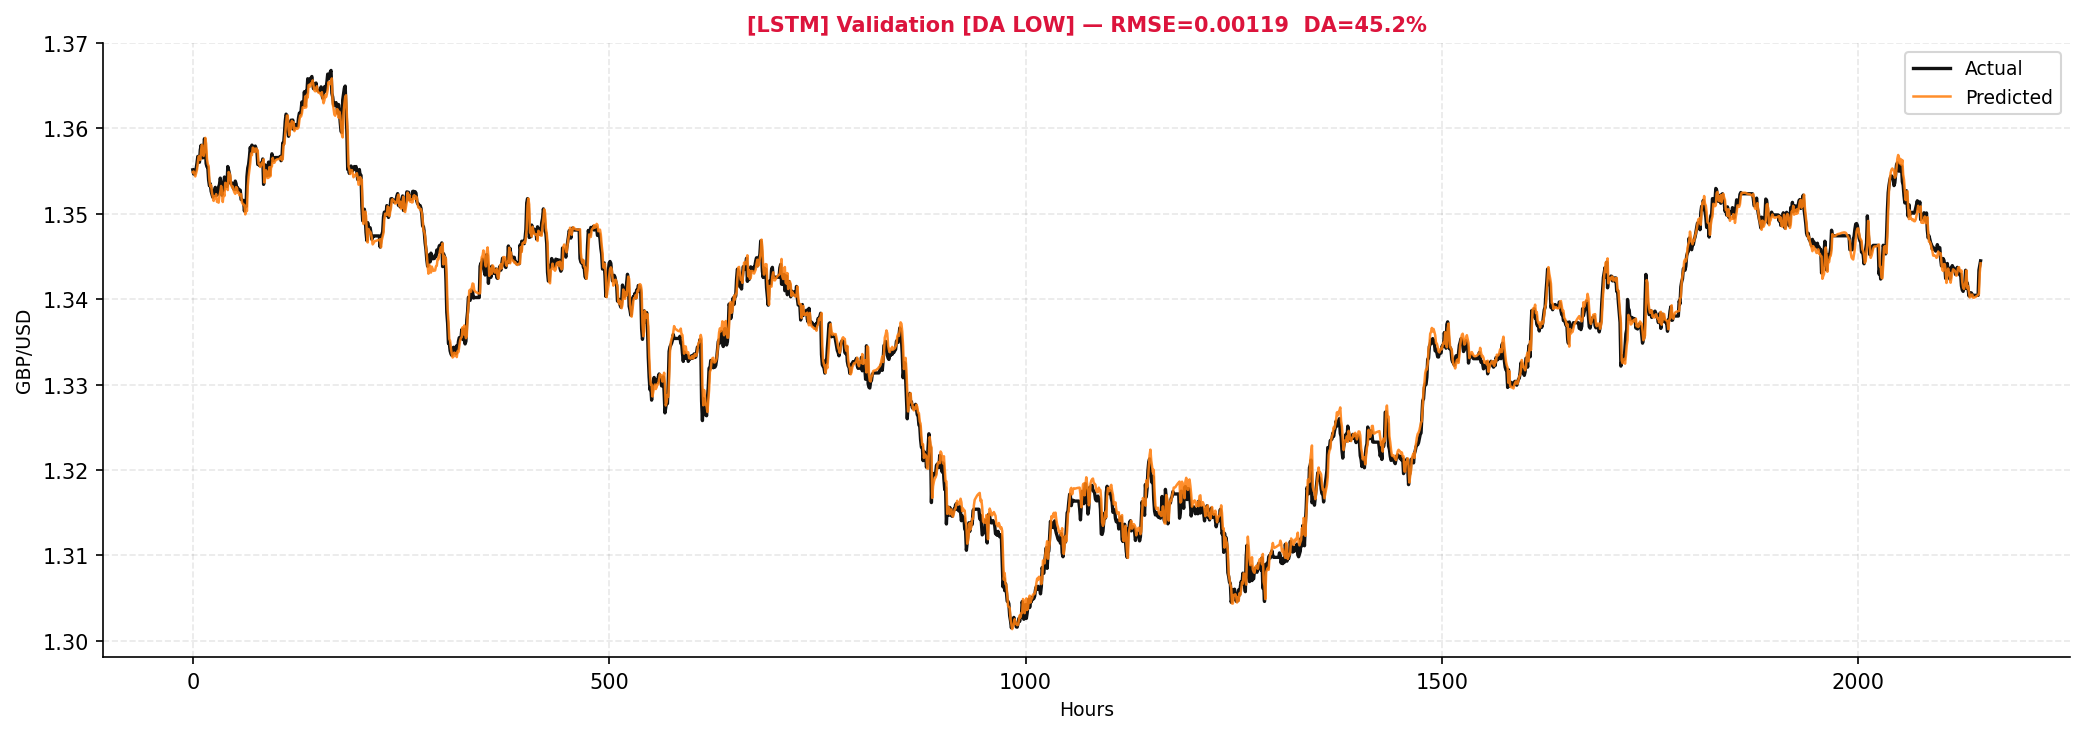

  Saved → plots/LSTM_3_val.png


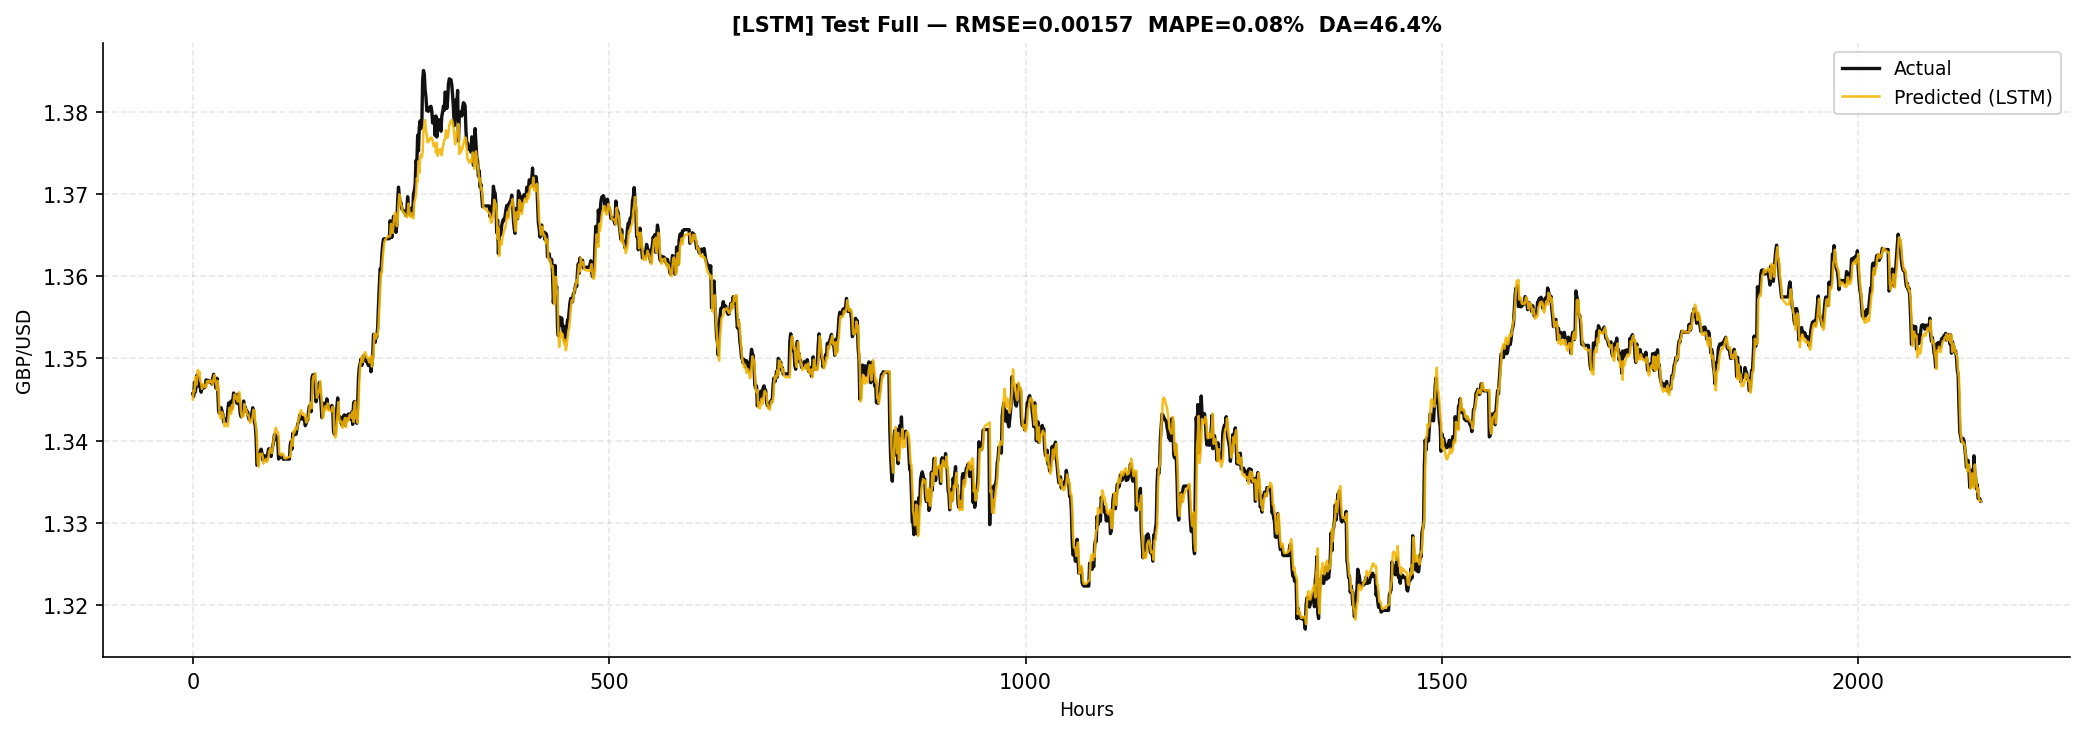

  Saved → plots/LSTM_4_test_full.png


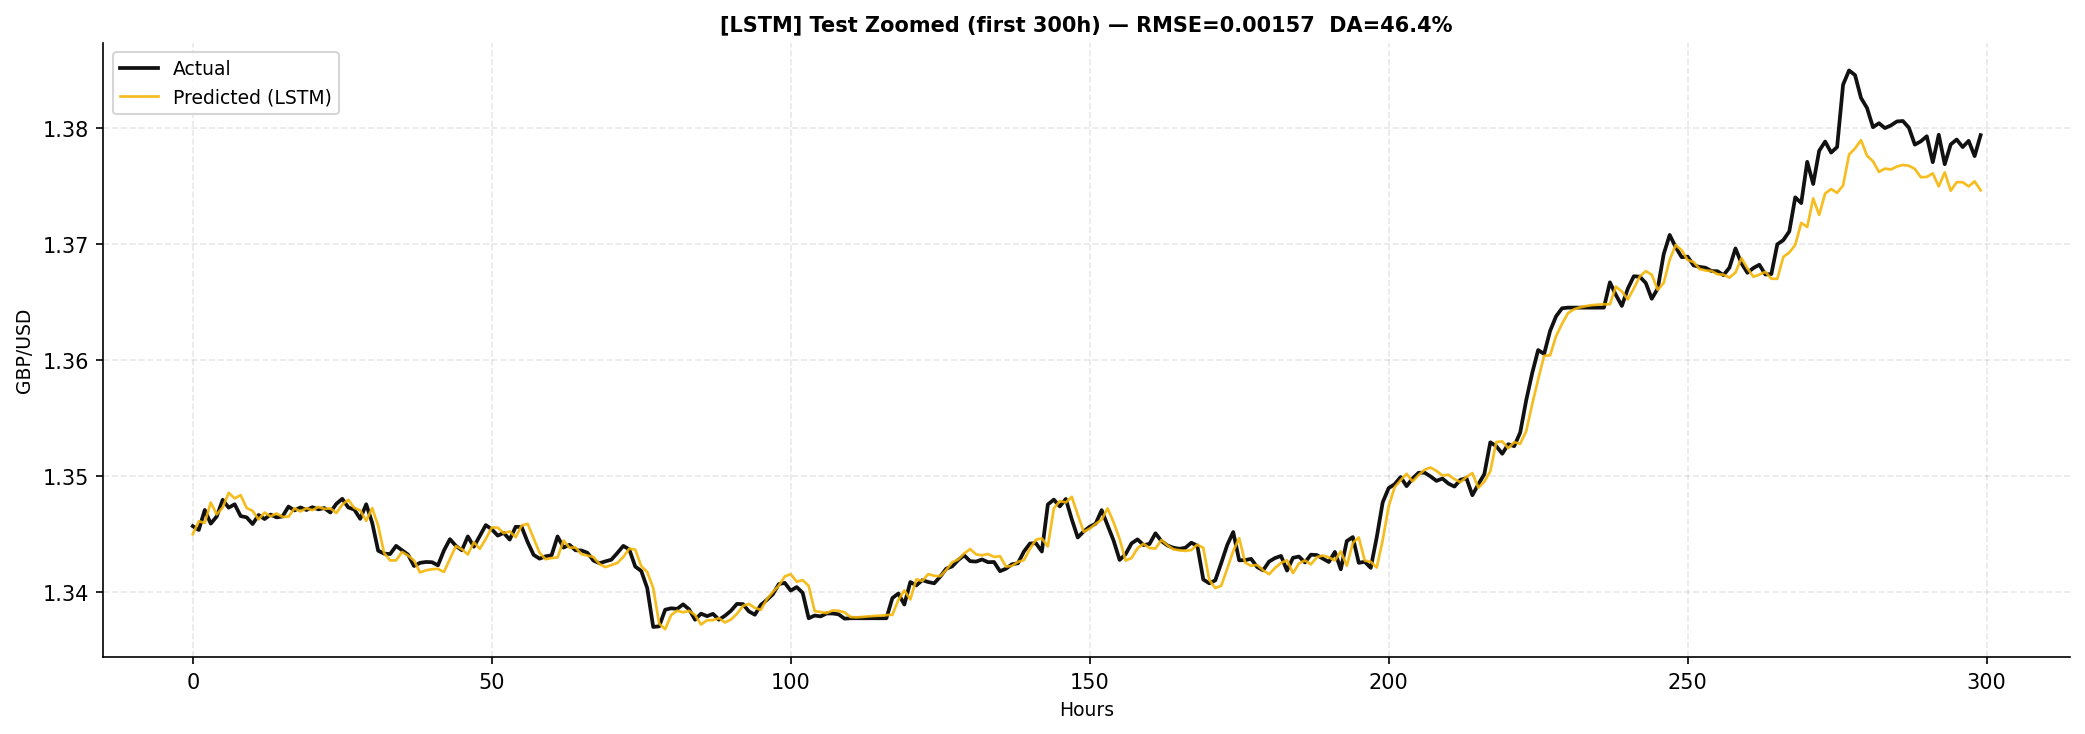

  Saved → plots/LSTM_5_test_zoom.png


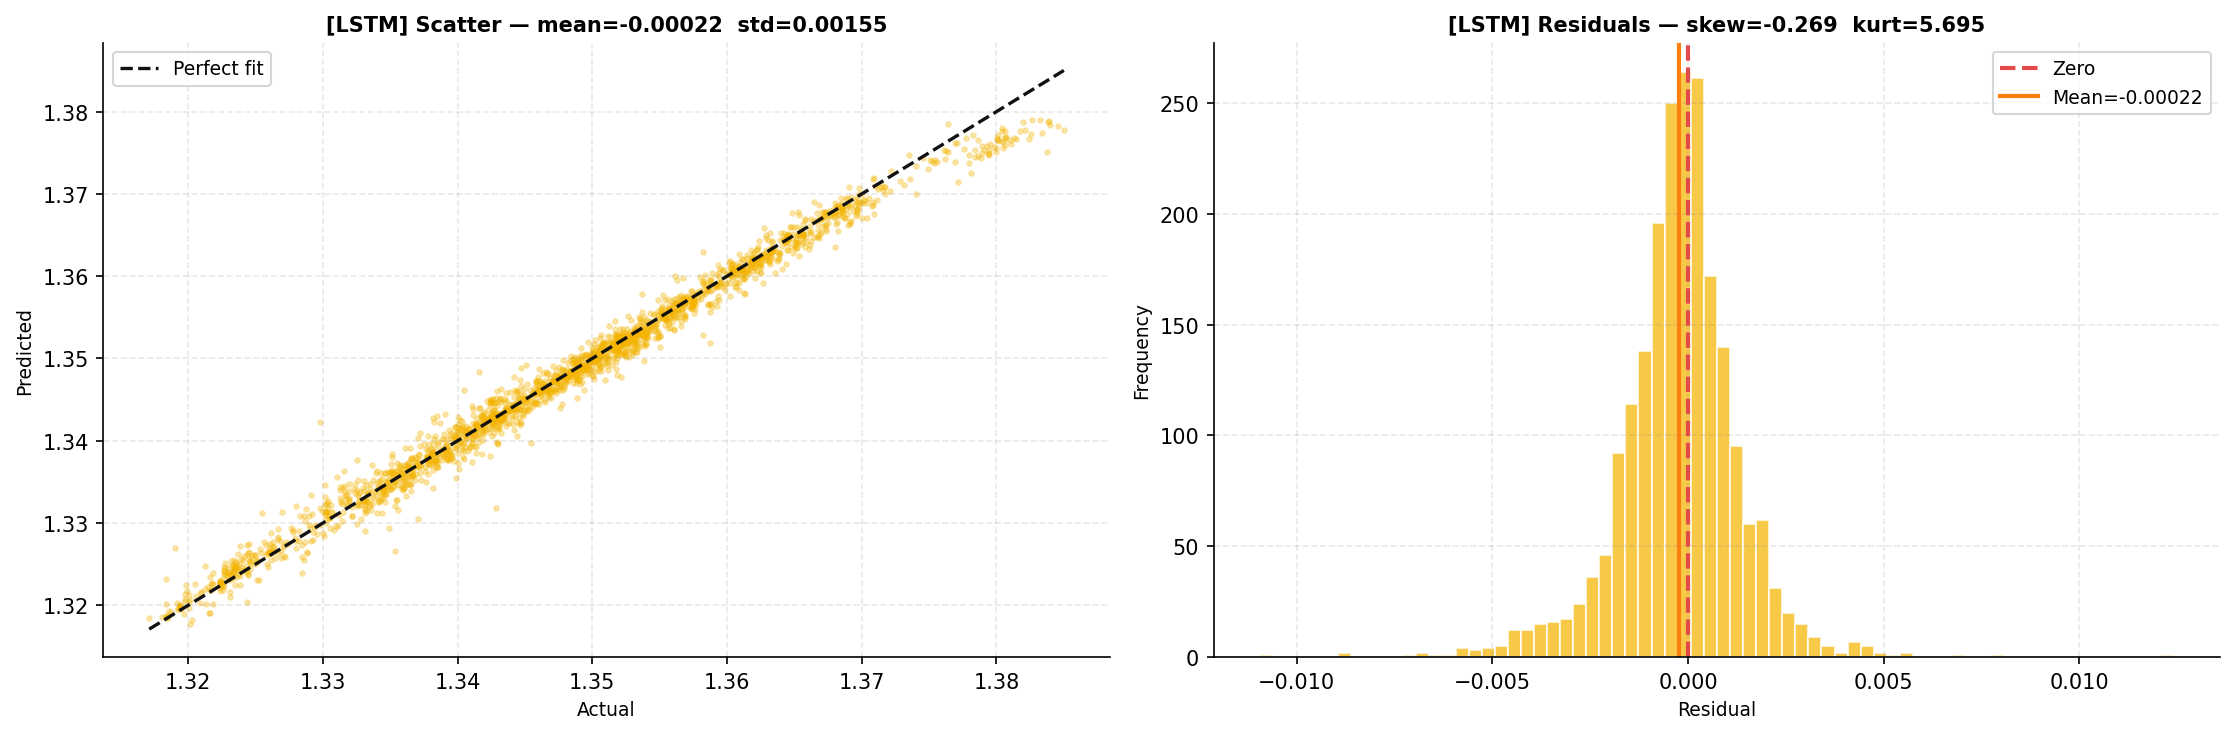

  Saved → plots/LSTM_6_scatter_residual.png
  LSTM complete.



In [40]:
print("  [LSTM]  STEP 5 : PLOT")
print("  " + "-" * 55)
plot_individual_results(
    "LSTM", lstm_history,
    lstm_train_preds, lstm_train_actual,
    lstm_val_preds,   lstm_val_actual,
    lstm_test_preds,  lstm_test_actual,
    lstm_test_metrics, COLORS["LSTM"]
)

results["LSTM"] = {
    "history":      lstm_history,
    "val_metrics":  lstm_val_metrics,
    "preds":        lstm_test_preds,
    "actual":       lstm_test_actual,
    "metrics":      lstm_test_metrics,
    "params":       lstm_model.count_params(),
    "time":         lstm_time,
}
print("  LSTM complete.\n")

# **GRU**

**BUILD**

In [41]:
print("\n  [GRU]  STEP 1 : BUILD")
print("  " + "-" * 55)
gru_model = build_gru(INPUT_SHAPE, UNITS, DROPOUT, LEARNING_RATE)
gru_model.summary()
print(f"  Parameters : {gru_model.count_params():,}")


  [GRU]  STEP 1 : BUILD
  -------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 48, 128)        │        61,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,289 (641.75 KB)

 Trainable params: 164,289 (641.75 KB)

 Non-trainable params: 0 (0.00 B)

  Parameters : 164,289


**TRAIN**

In [42]:
print("\n  [GRU]  STEP 2 : TRAIN")
print("  " + "-" * 55)
print(f"  Train={X_train.shape[0]:,}  Val={X_val.shape[0]:,}\n")
gru_history, gru_time = train_model(
    gru_model, "GRU", X_train, y_train, X_val, y_val
)


  [GRU]  STEP 2 : TRAIN
  -------------------------------------------------------
  Train=10,024  Val=2,148

Epoch 1/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 0.0086 - mae: 0.0851 - val_loss: 4.0672e-04 - val_mae: 0.0198 - learning_rate: 0.0010
Epoch 2/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0027 - mae: 0.0519 - val_loss: 3.1520e-04 - val_mae: 0.0176 - learning_rate: 0.0010
Epoch 3/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0020 - mae: 0.0439 - val_loss: 0.0010 - val_mae: 0.0354 - learning_rate: 0.0010
Epoch 4/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0018 - mae: 0.0421 - val_loss: 4.5686e-04 - val_mae: 0.0222 - learning_rate: 0.0010
Epoch 5/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0014 - mae: 0.0372 - val_loss: 3.4633e-04 - val_mae: 0.0191 - learning_rate: 0.0010
Epoch 6/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0014 - mae: 0.0371 - val_loss: 2.7347e-04 - val_mae: 0.0158 - learning_rate: 0.0010
Epoch 

**VALIDATION REPORT**

In [48]:
print("\n  [GRU]  STEP 3 : VALIDATE")
print("  " + "-" * 55)
gru_val_preds, gru_val_actual, gru_val_metrics = run_inference(
    gru_model, X_val, y_val
)
gru_val_ok = print_validation_report("GRU", gru_val_preds,
                                      gru_val_actual, gru_val_metrics)



  [GRU]  STEP 3 : VALIDATE
  -------------------------------------------------------

  VALIDATION — GRU
  RMSE         : 0.00125
  MAE          : 0.00095
  MAPE         : 0.07114
  NRMSE (%)    : 1.91548
  DA (%)       : 45.22590
  DA status  : LOW — worse than random!


**TEST**

In [44]:
print("\n  [LSTM]  STEP 4 : TEST  (held-out test set)")
print("  " + "-" * 55)
print(f"  Running inference on {X_test.shape[0]:,} unseen samples ...")
lstm_train_preds, lstm_train_actual, _ = run_inference(lstm_model, X_train, y_train)
lstm_test_preds,  lstm_test_actual, lstm_test_metrics = run_inference(
    lstm_model, X_test, y_test
)
print_test_report("LSTM", lstm_test_metrics, lstm_model.count_params(), lstm_time)


  [LSTM]  STEP 4 : TEST  (held-out test set)
  -------------------------------------------------------
  Running inference on 2,148 unseen samples ...

  TEST — LSTM  (216,641 params  139.2s)
  RMSE         : 0.00157
  MAE          : 0.00110
  MAPE         : 0.08124
  NRMSE (%)    : 2.31156
  DA (%)       : 46.39031
  DA status  : CHECK



**PLOTS FOR GRU**

  [GRU]  STEP 4 : RUN INFERENCE
  -------------------------------------------------------
  Train predictions shape: (10024,)
  Val predictions shape: (2148,)
  Test predictions shape: (2148,)

  VALIDATION — GRU
  RMSE         : 0.00125
  MAE          : 0.00095
  MAPE         : 0.07114
  NRMSE (%)    : 1.91548
  DA (%)       : 45.22590
  DA status  : LOW — worse than random!

  TEST — GRU  (164,289 params  120.3s)
  RMSE         : 0.00172
  MAE          : 0.00126
  MAPE         : 0.09332
  NRMSE (%)    : 2.53903
  DA (%)       : 45.45878
  DA status  : CHECK

  [GRU]  STEP 5 : PLOT
  -------------------------------------------------------


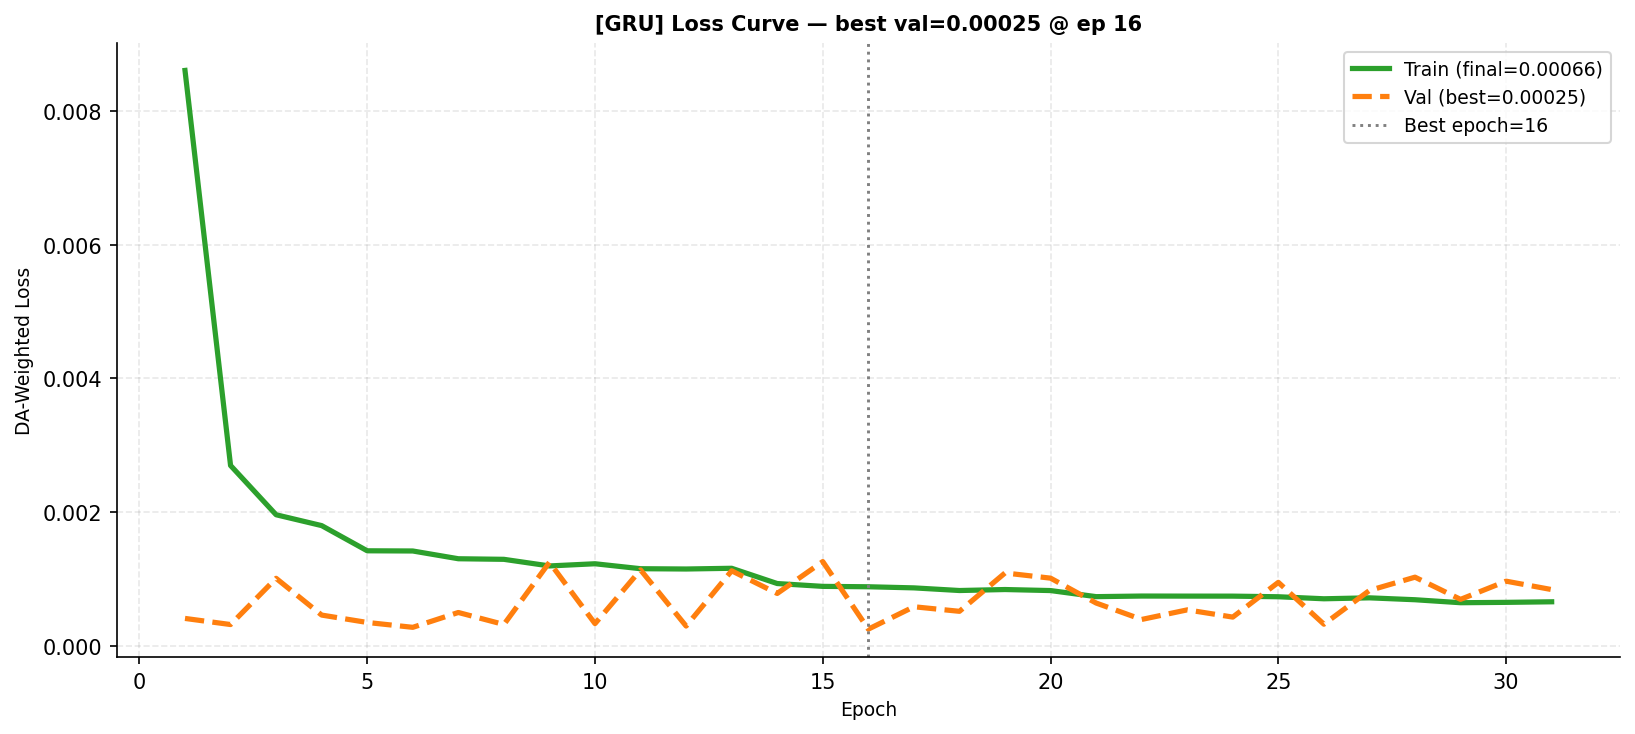

  Saved → plots/GRU_1_loss.png


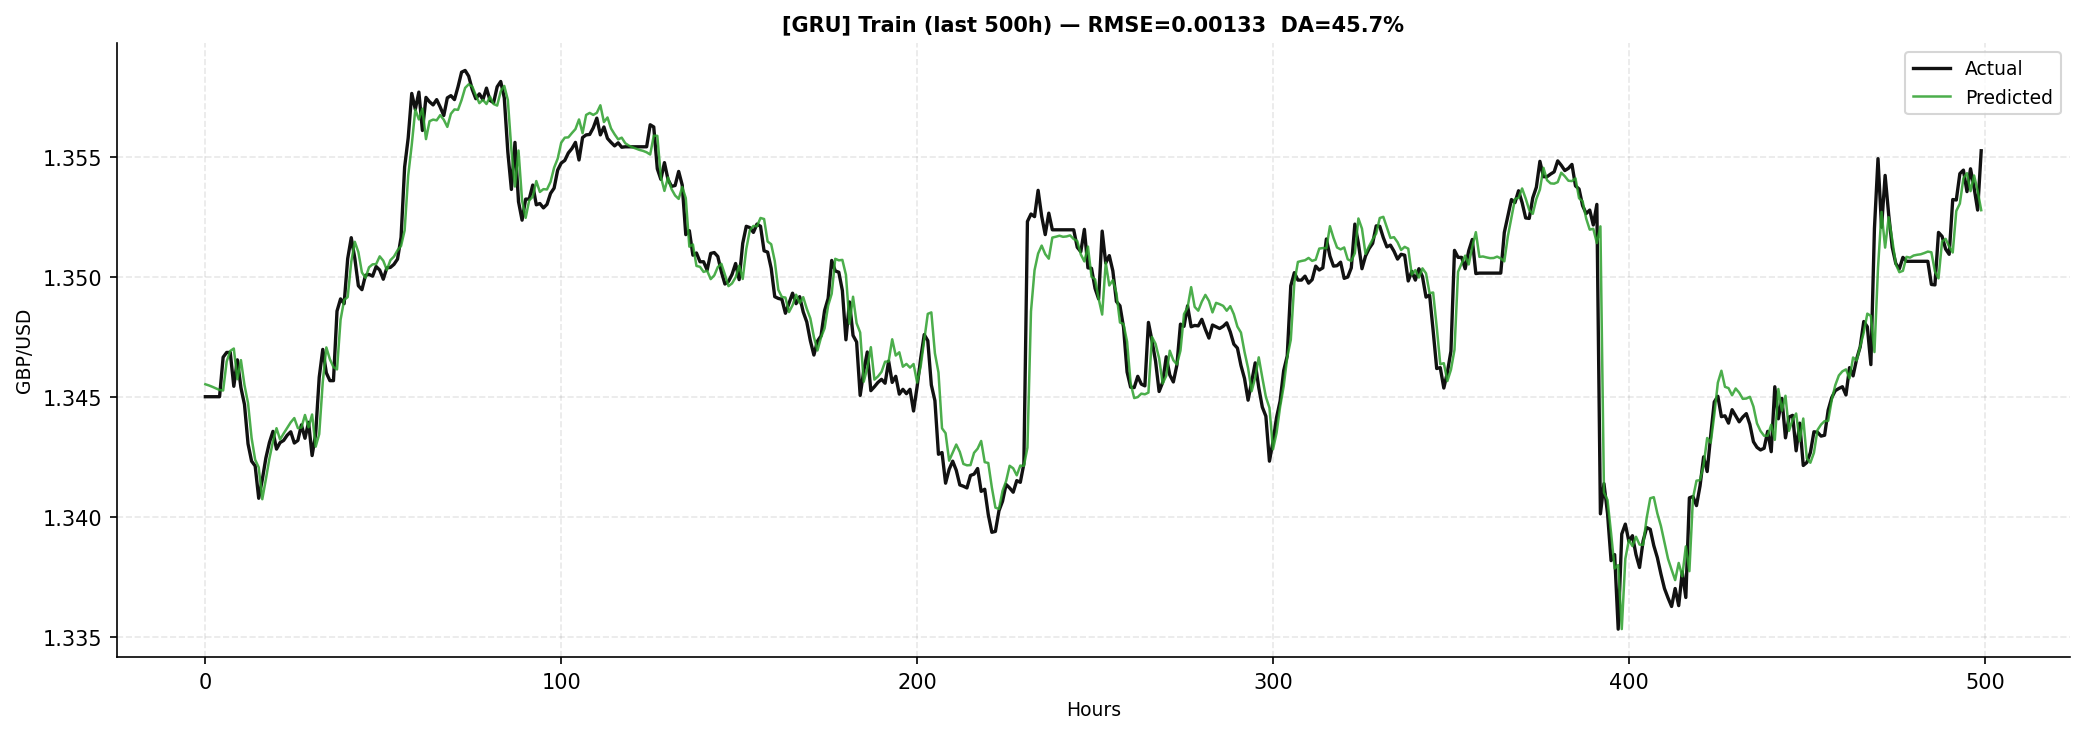

  Saved → plots/GRU_2_train.png


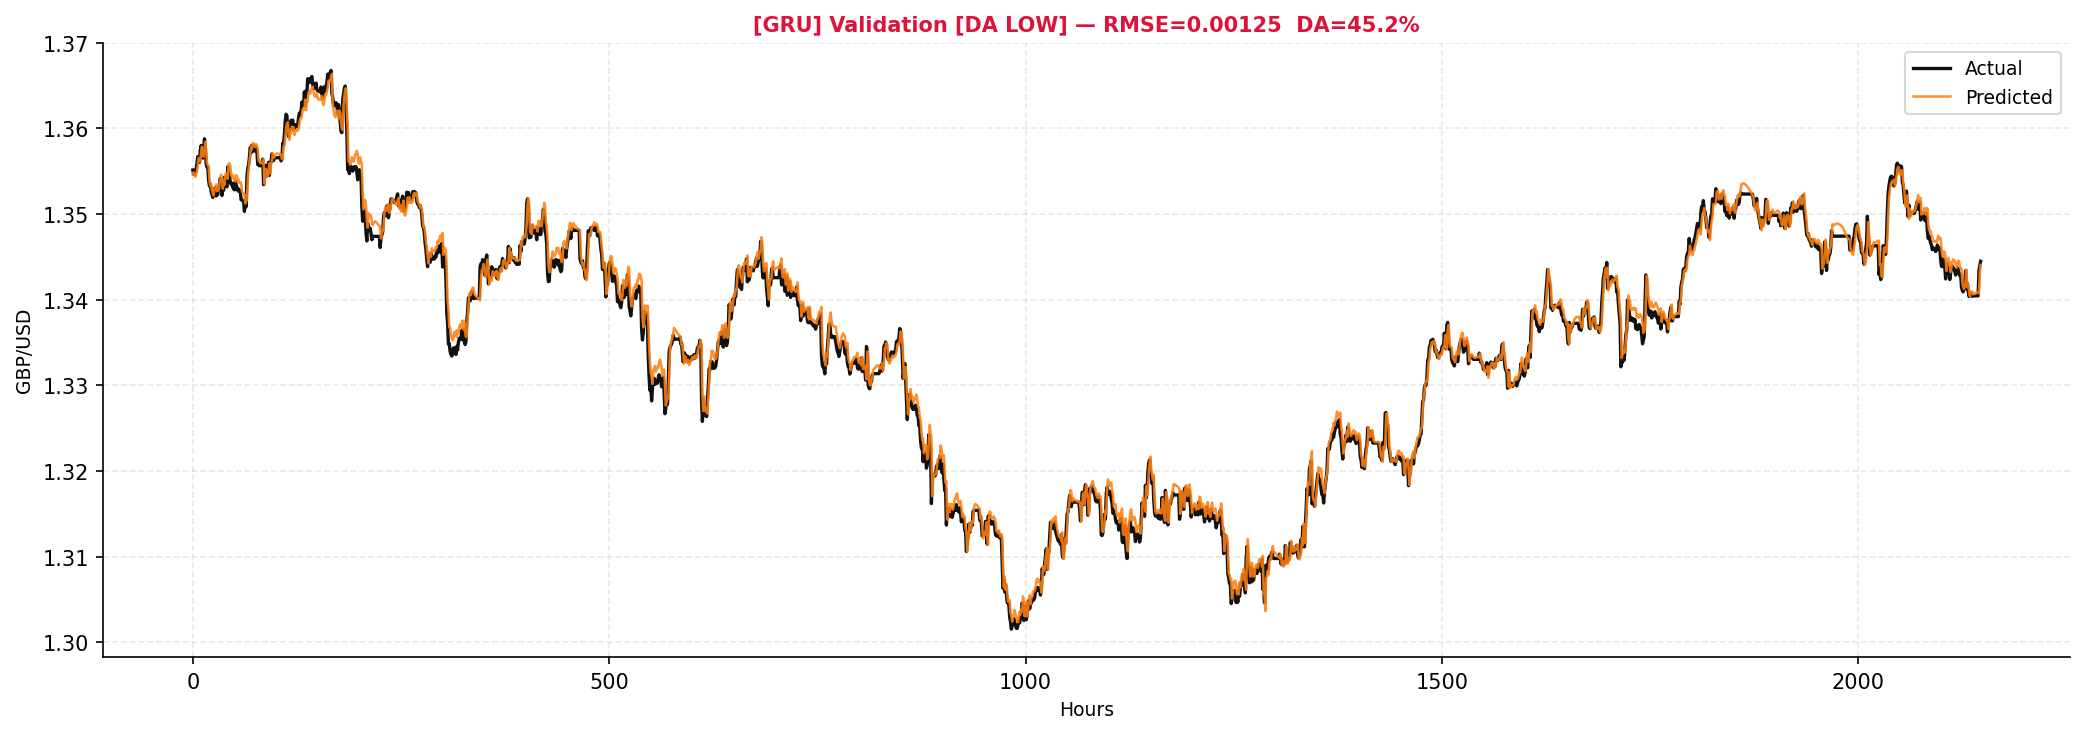

  Saved → plots/GRU_3_val.png


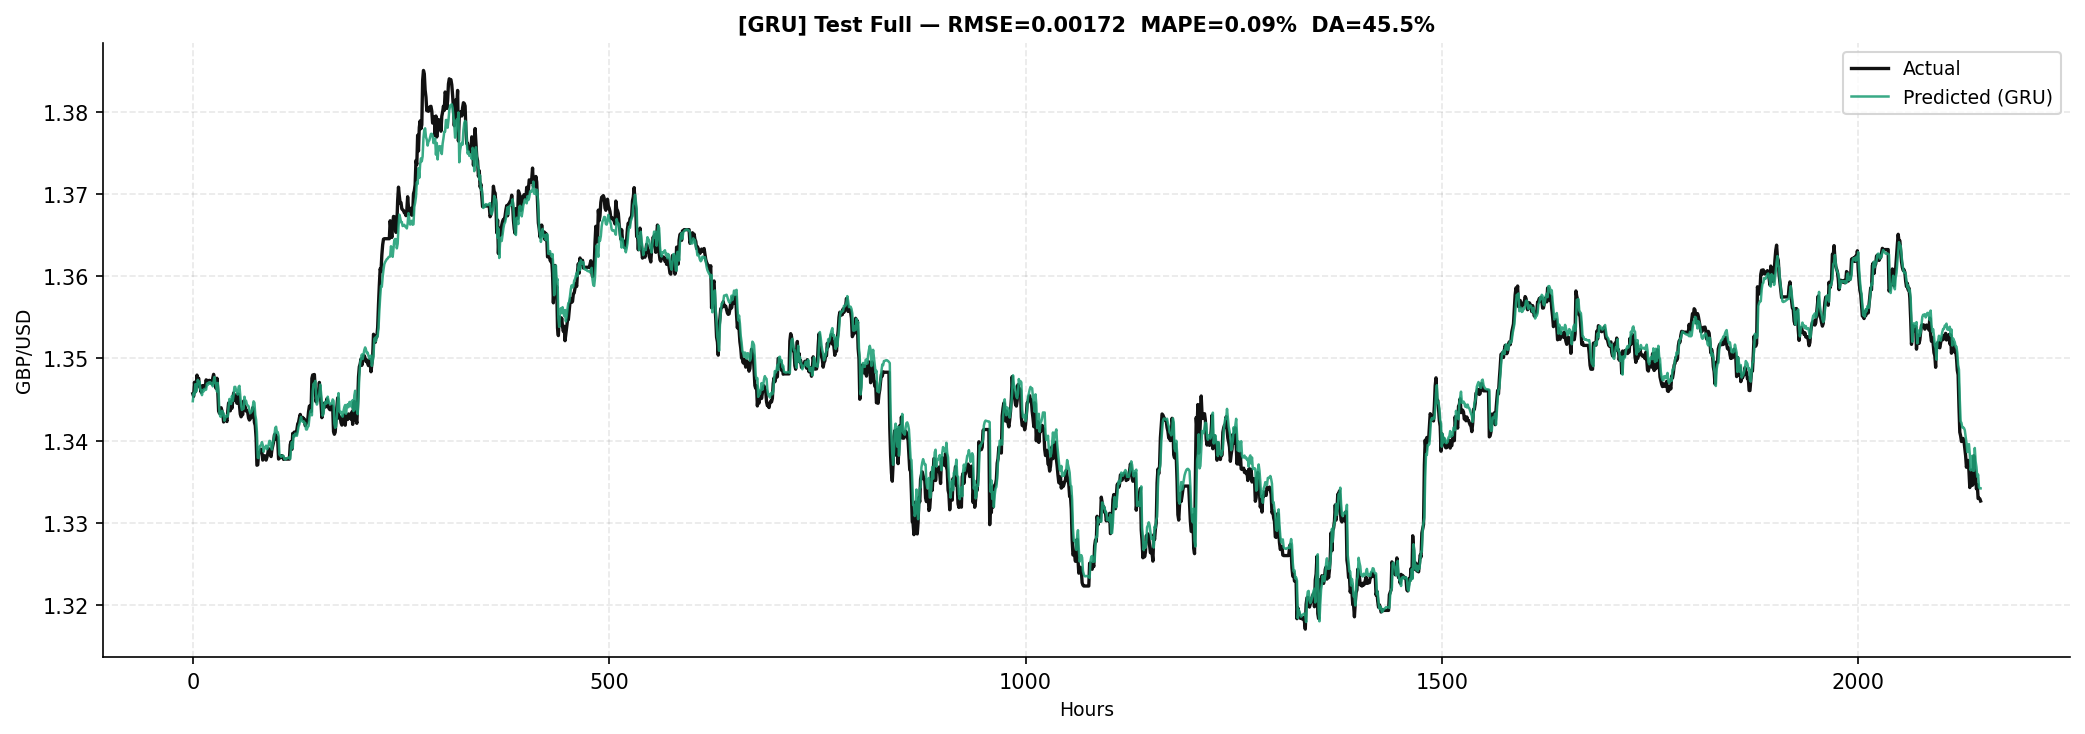

  Saved → plots/GRU_4_test_full.png


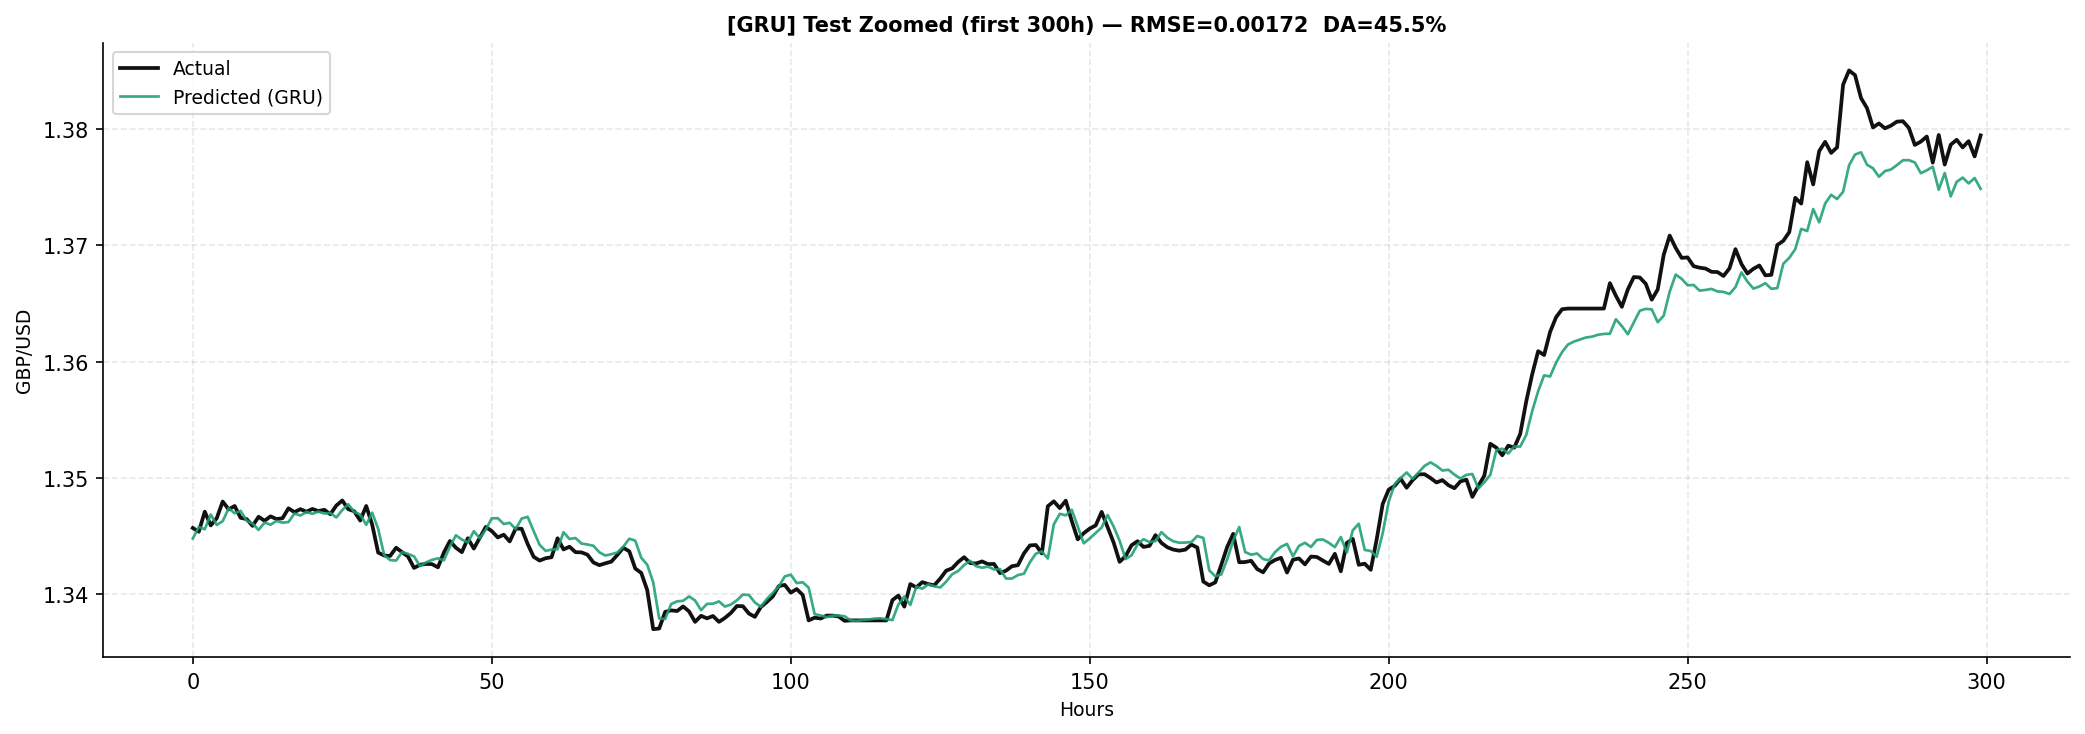

  Saved → plots/GRU_5_test_zoom.png


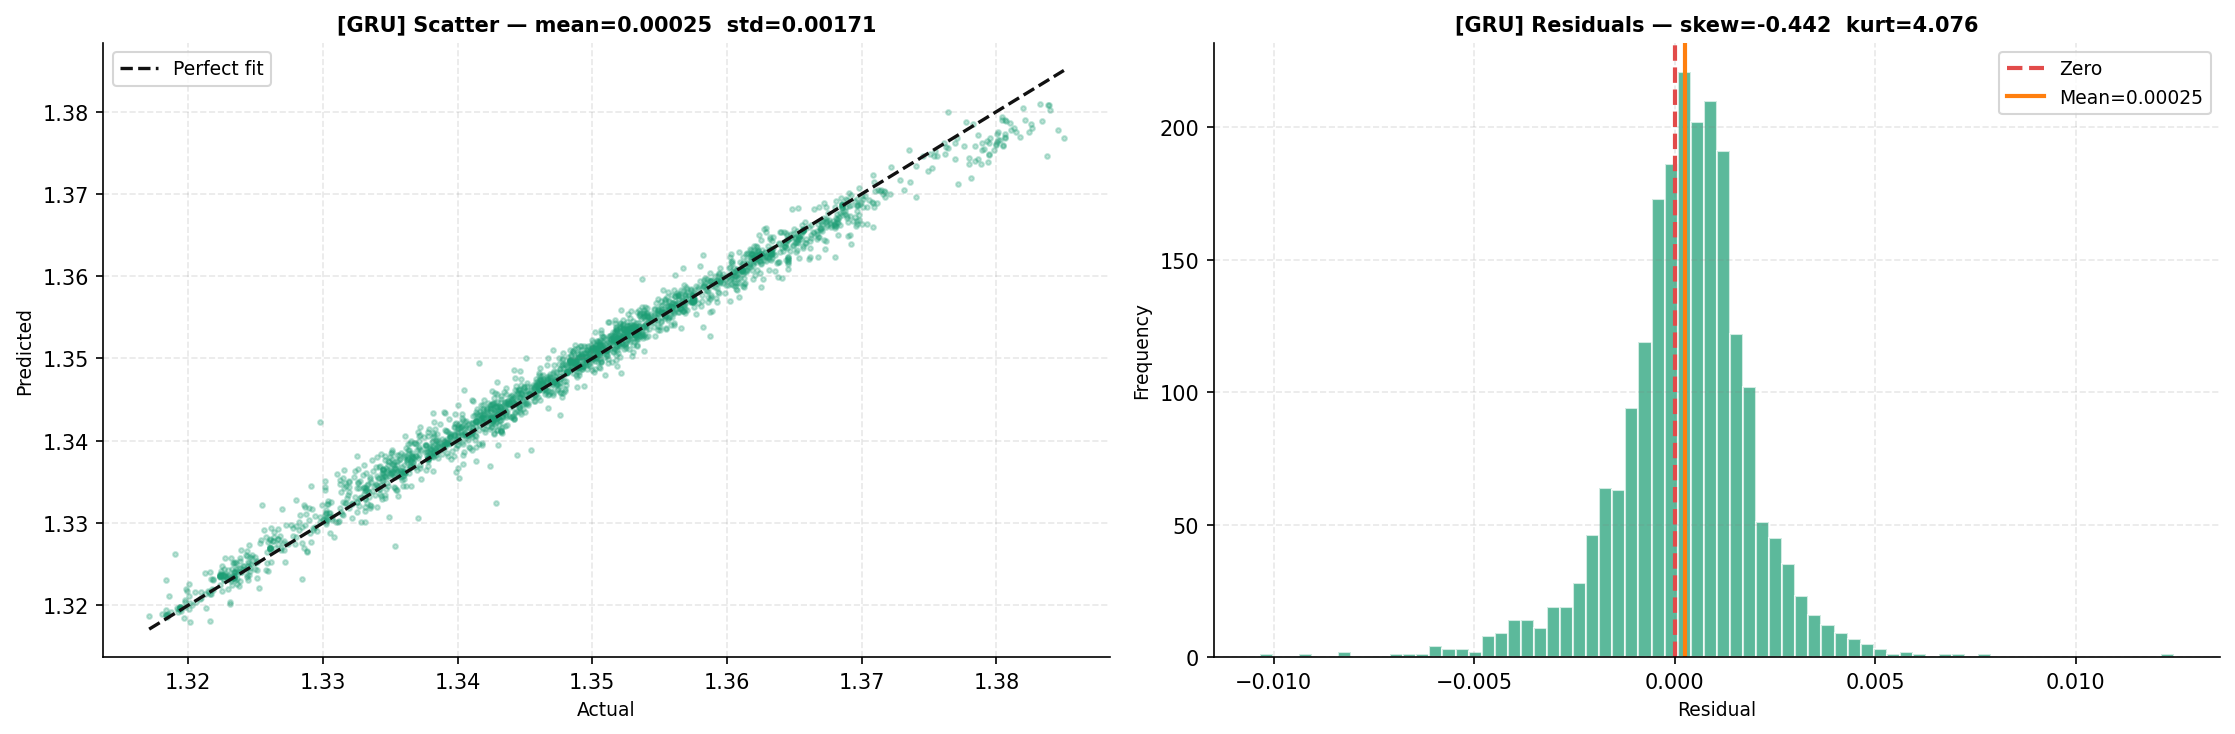

  Saved → plots/GRU_6_scatter_residual.png
  GRU complete.



In [45]:
print("  [GRU]  STEP 4 : RUN INFERENCE")
print("  " + "-" * 55)

gru_train_preds, gru_train_actual, gru_train_metrics = run_inference(gru_model, X_train, y_train)
gru_val_preds, gru_val_actual, gru_val_metrics = run_inference(gru_model, X_val, y_val)
gru_test_preds, gru_test_actual, gru_test_metrics = run_inference(gru_model, X_test, y_test)

print(f"  Train predictions shape: {gru_train_preds.shape}")
print(f"  Val predictions shape: {gru_val_preds.shape}")
print(f"  Test predictions shape: {gru_test_preds.shape}")

print_validation_report("GRU", gru_val_preds, gru_val_actual, gru_val_metrics)
print_test_report("GRU", gru_test_metrics, gru_model.count_params(), gru_time)

print("  [GRU]  STEP 5 : PLOT")
print("  " + "-" * 55)
plot_individual_results(
    "GRU", gru_history,
    gru_train_preds, gru_train_actual,
    gru_val_preds,   gru_val_actual,
    gru_test_preds,  gru_test_actual,
    gru_test_metrics, COLORS["GRU"]
)

results["GRU"] = {
    "history": gru_history,
    "val_metrics":  gru_val_metrics,
    "preds":   gru_test_preds,
    "actual":  gru_test_actual,
    "metrics": gru_test_metrics,
    "params":  gru_model.count_params(),
    "time":    gru_time,
}
print("  GRU complete.\n")

# **BiLSTM  (Bidirectional LSTM)**

**BUILD**

In [46]:
print("\n  [BiLSTM]  STEP 1 : BUILD")
print("  " + "-" * 55)
bilstm_model = build_bilstm(INPUT_SHAPE, UNITS, DROPOUT, LEARNING_RATE)
bilstm_model.summary()
print(f"  Parameters : {bilstm_model.count_params():,}")


  [BiLSTM]  STEP 1 : BUILD
  -------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       161,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 330,305 (1.26 MB)

 Trainable params: 330,305 (1.26 MB)

 Non-trainable params: 0 (0.00 B)

  Parameters : 330,305


**TRAIN**

In [47]:
print("\n  [BiLSTM]  STEP 2 : TRAIN")
print("  " + "-" * 55)
print(f"  Train={X_train.shape[0]:,}  Val={X_val.shape[0]:,}\n")
bilstm_history, bilstm_time = train_model(
    bilstm_model, "BiLSTM", X_train, y_train, X_val, y_val
)


  [BiLSTM]  STEP 2 : TRAIN
  -------------------------------------------------------
  Train=10,024  Val=2,148

Epoch 1/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - loss: 0.0065 - mae: 0.0742 - val_loss: 5.2332e-04 - val_mae: 0.0235 - learning_rate: 0.0010
Epoch 2/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0023 - mae: 0.0477 - val_loss: 6.5979e-04 - val_mae: 0.0268 - learning_rate: 0.0010
Epoch 3/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0018 - mae: 0.0419 - val_loss: 7.4156e-04 - val_mae: 0.0279 - learning_rate: 0.0010
Epoch 4/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0015 - mae: 0.0385 - val_loss: 7.4896e-04 - val_mae: 0.0301 - learning_rate: 0.0010
Epoch 5/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - loss: 0.0014 - mae: 0.0371 - val_loss: 8.2700e-04 - val_mae: 0.0320 - learning_rate: 0.0010
Epoch 6/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0014 - mae: 0.0366 - val_loss: 6.8653e-04 - val_mae: 0.0285 - learning_rate: 0.001

**VALIDATION REPORT**

In [49]:
print("\n  [BiLSTM]  STEP 3 : VALIDATE")
print("  " + "-" * 55)
bilstm_val_preds, bilstm_val_actual, bilstm_val_metrics = run_inference(
    bilstm_model, X_val, y_val
)
bilstm_val_ok = print_validation_report("BiLSTM", bilstm_val_preds,
                                         bilstm_val_actual, bilstm_val_metrics)


  [BiLSTM]  STEP 3 : VALIDATE
  -------------------------------------------------------

  VALIDATION — BiLSTM
  RMSE         : 0.00118
  MAE          : 0.00087
  MAPE         : 0.06515
  NRMSE (%)    : 1.80528
  DA (%)       : 45.55193
  DA status  : LOW — worse than random!


**TEST**

In [50]:
print("\n  [BiLSTM]  STEP 4 : TEST")
print("  " + "-" * 55)
bilstm_train_preds, bilstm_train_actual, _ = run_inference(bilstm_model, X_train, y_train)
bilstm_test_preds,  bilstm_test_actual, bilstm_test_metrics = run_inference(
    bilstm_model, X_test, y_test
)
print_test_report("BiLSTM", bilstm_test_metrics, bilstm_model.count_params(), bilstm_time)


  [BiLSTM]  STEP 4 : TEST
  -------------------------------------------------------

  TEST — BiLSTM  (330,305 params  247.5s)
  RMSE         : 0.00159
  MAE          : 0.00113
  MAPE         : 0.08375
  NRMSE (%)    : 2.34626
  DA (%)       : 46.20401
  DA status  : CHECK



**PLOT**

  [BiLSTM]  STEP 5 : PLOT
  -------------------------------------------------------


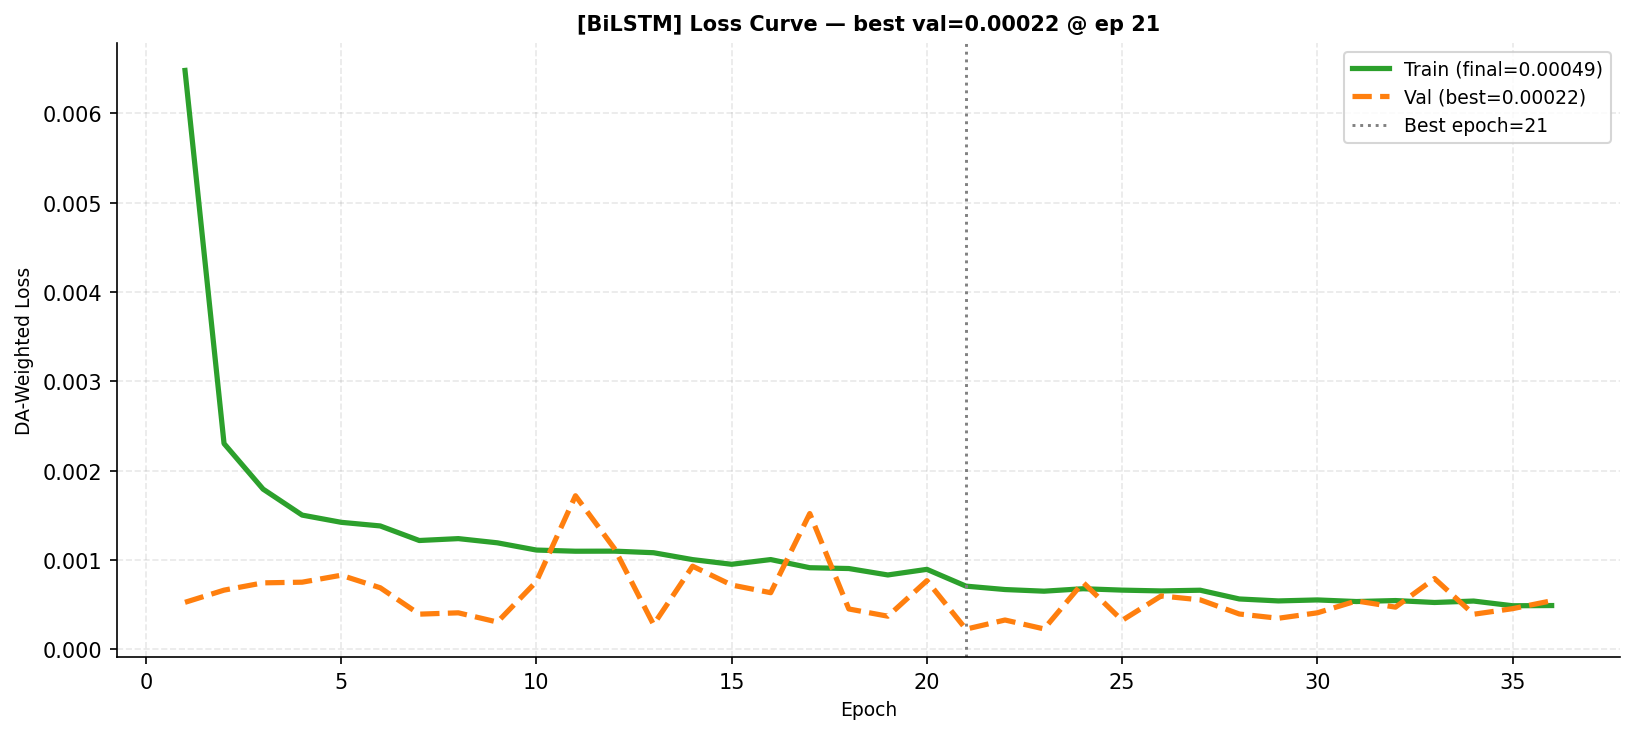

  Saved → plots/BiLSTM_1_loss.png


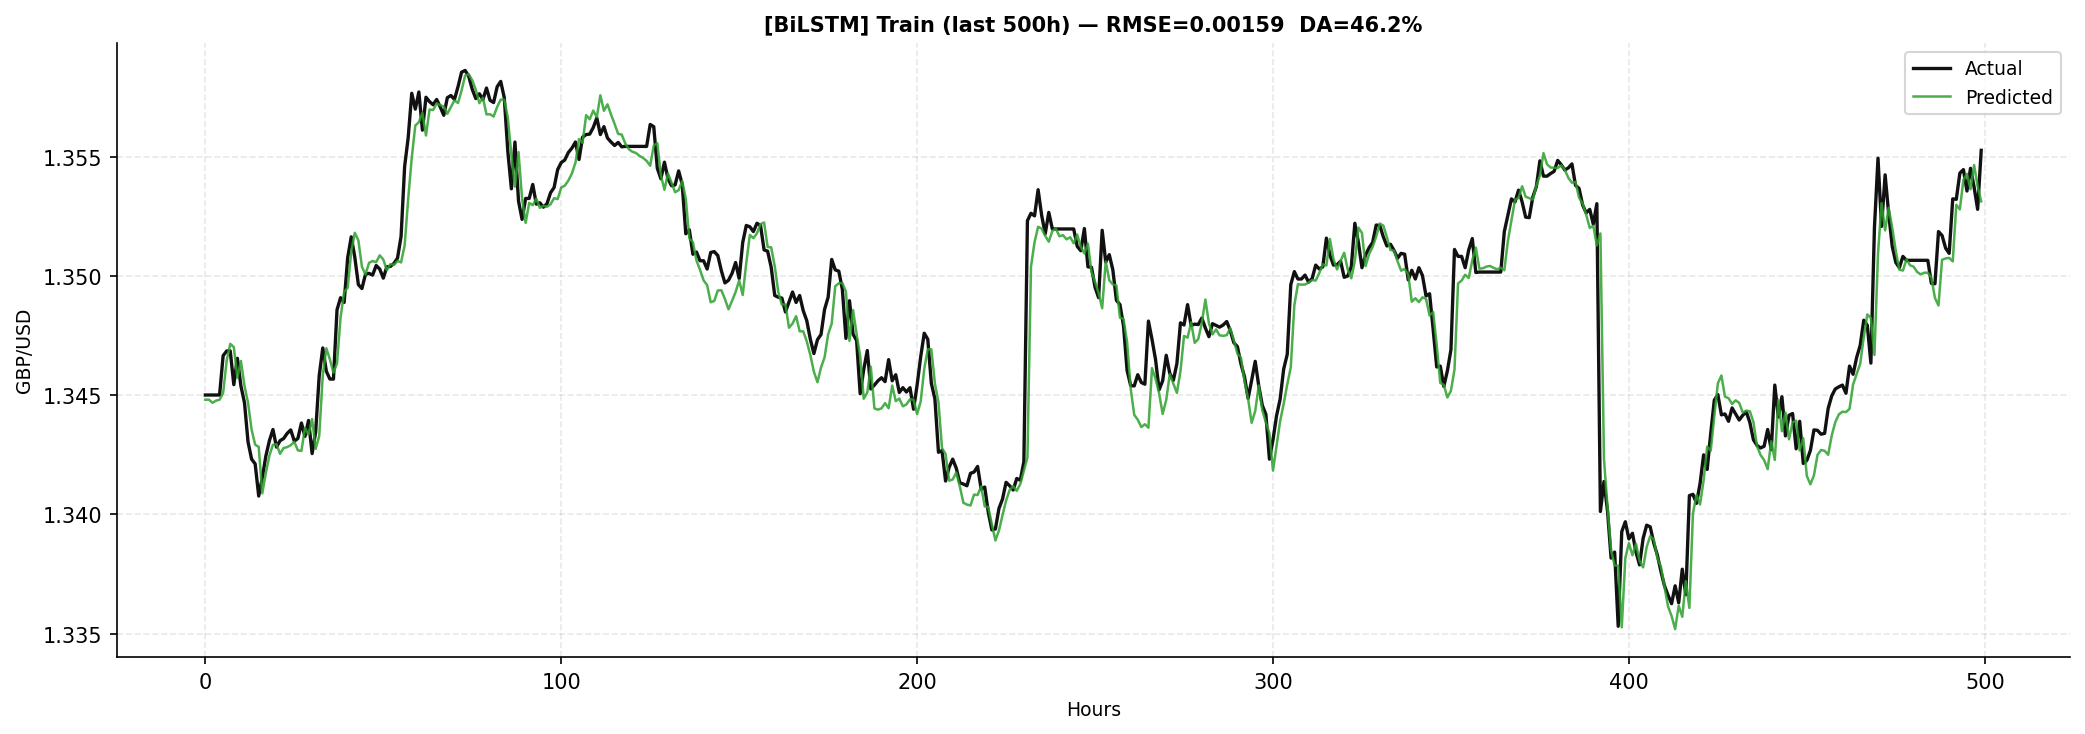

  Saved → plots/BiLSTM_2_train.png


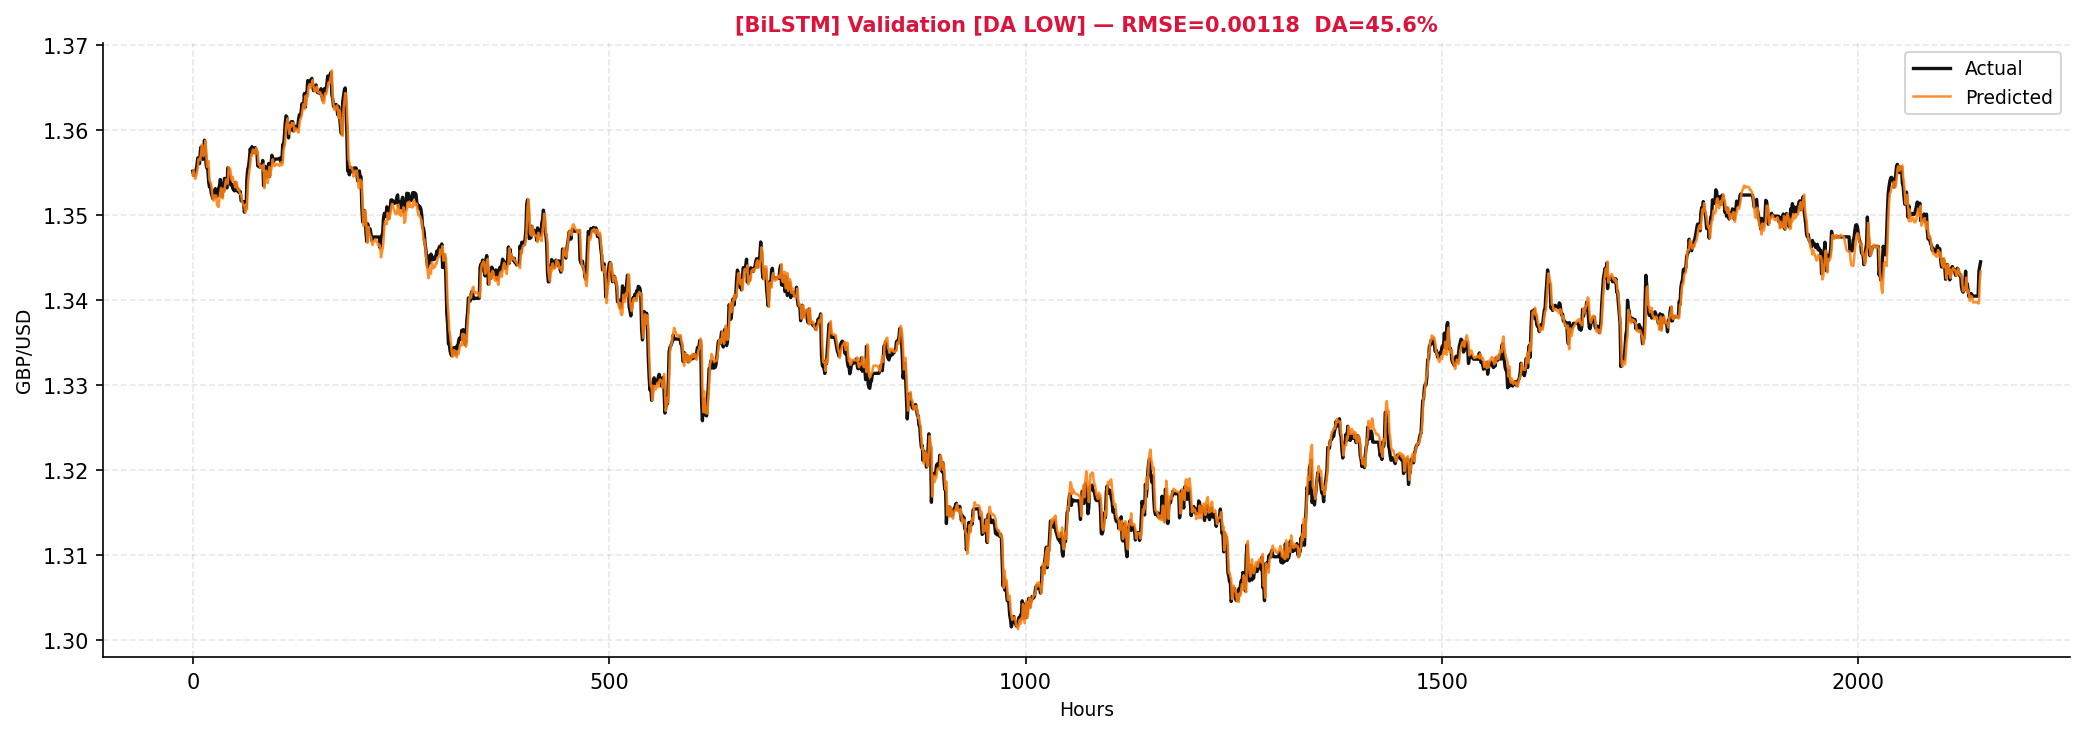

  Saved → plots/BiLSTM_3_val.png


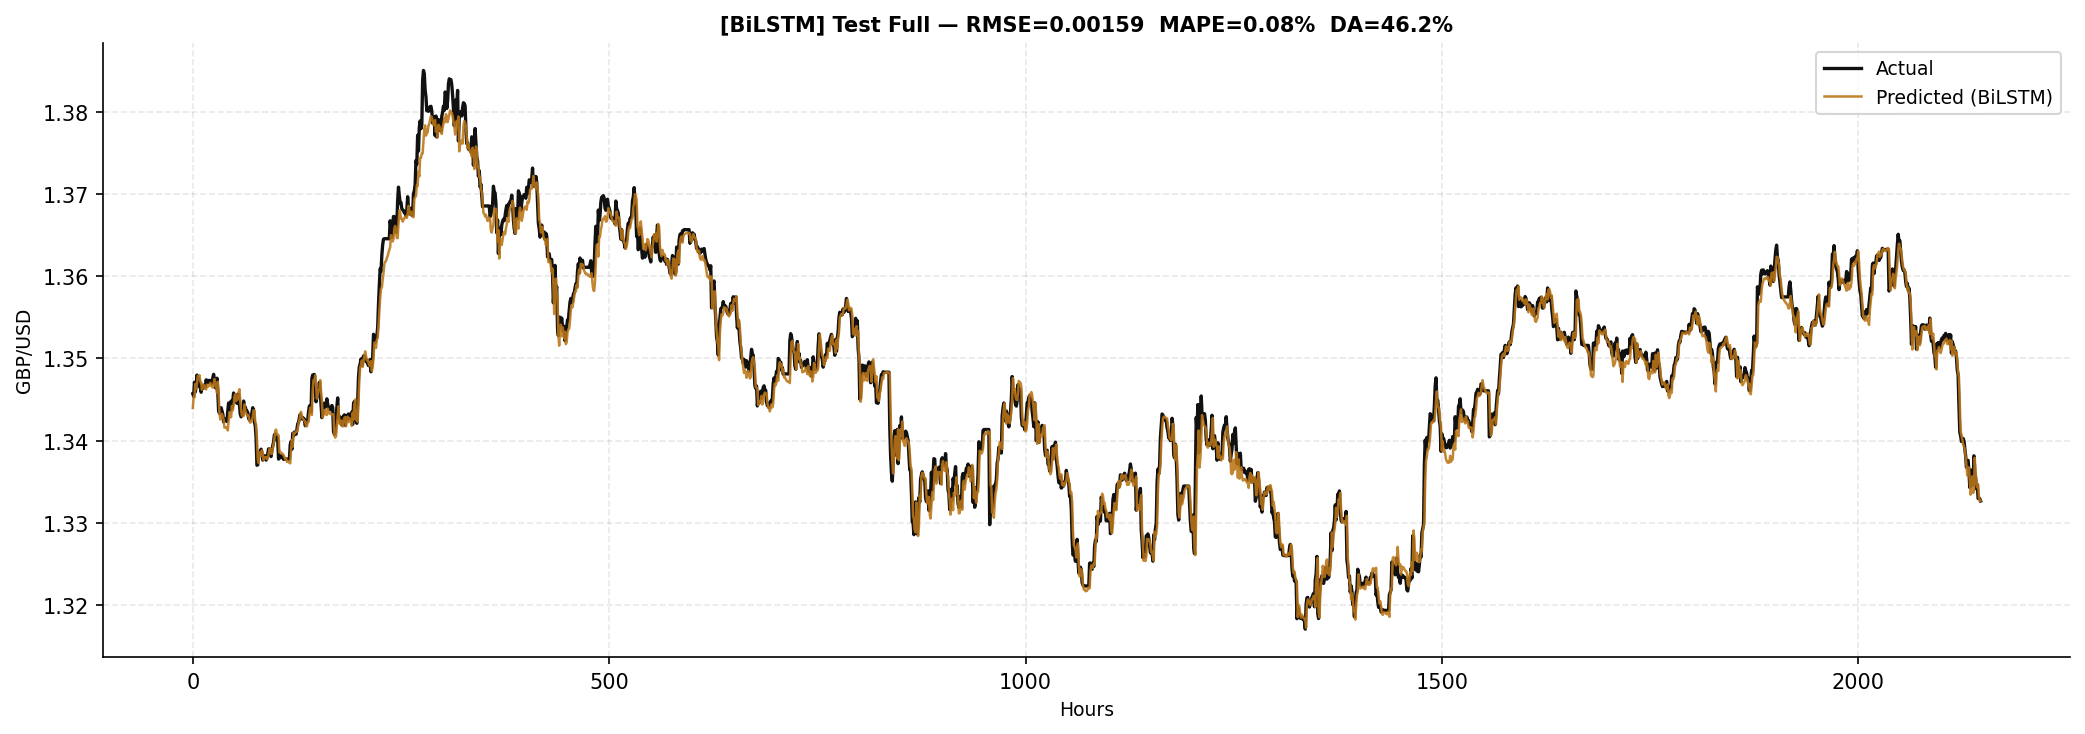

  Saved → plots/BiLSTM_4_test_full.png


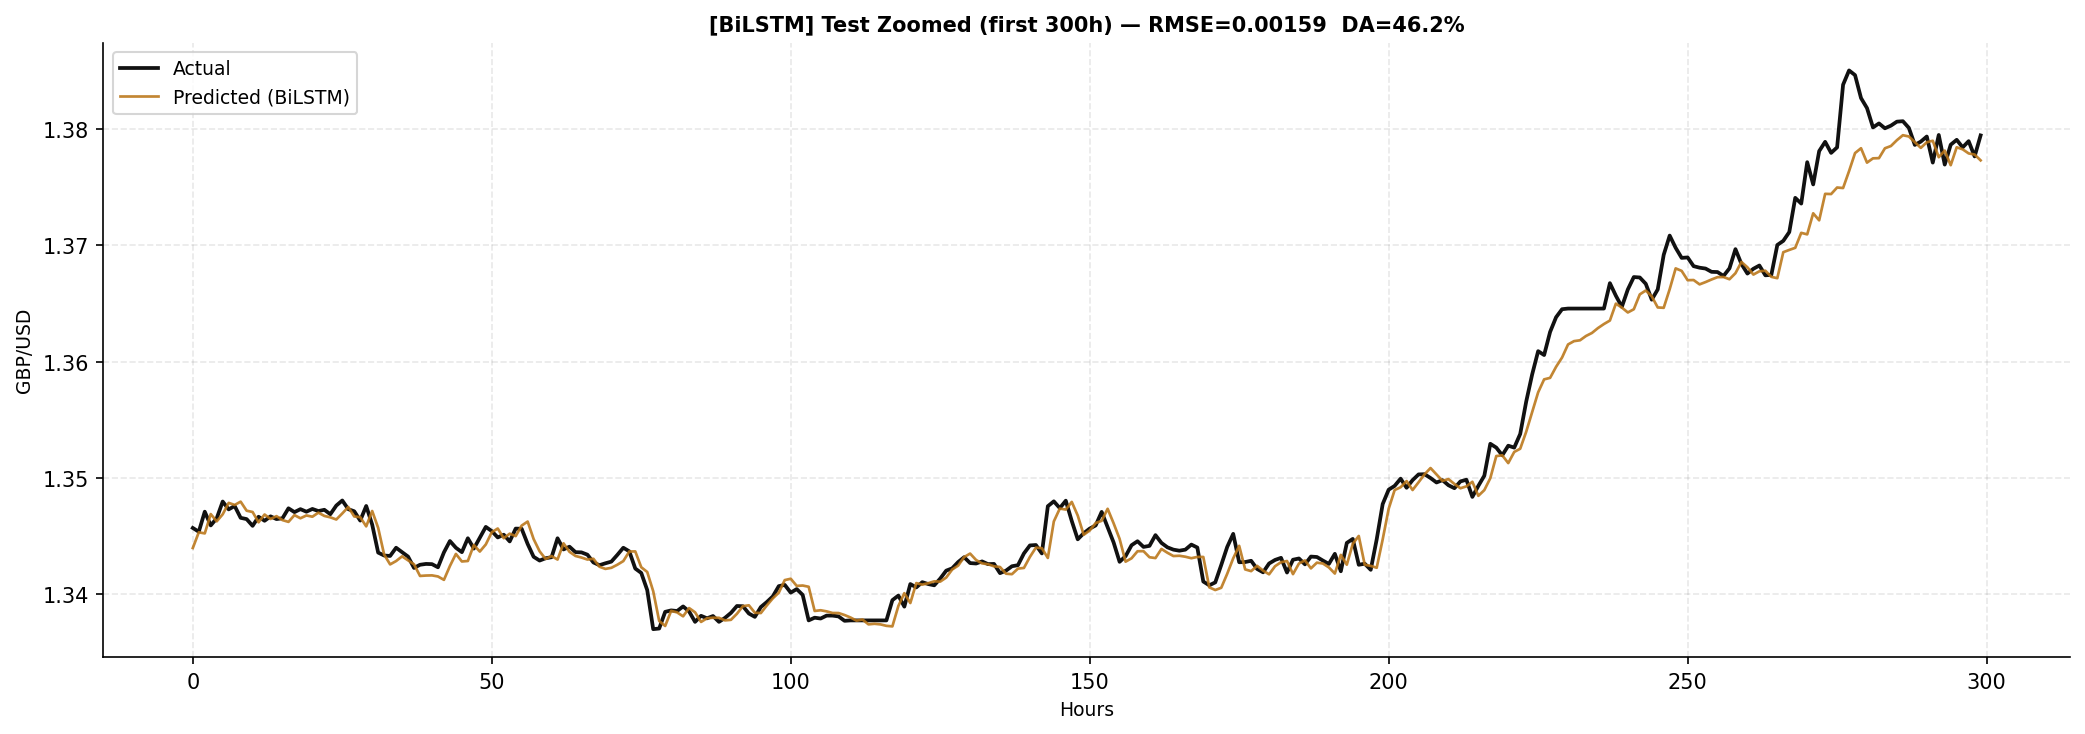

  Saved → plots/BiLSTM_5_test_zoom.png


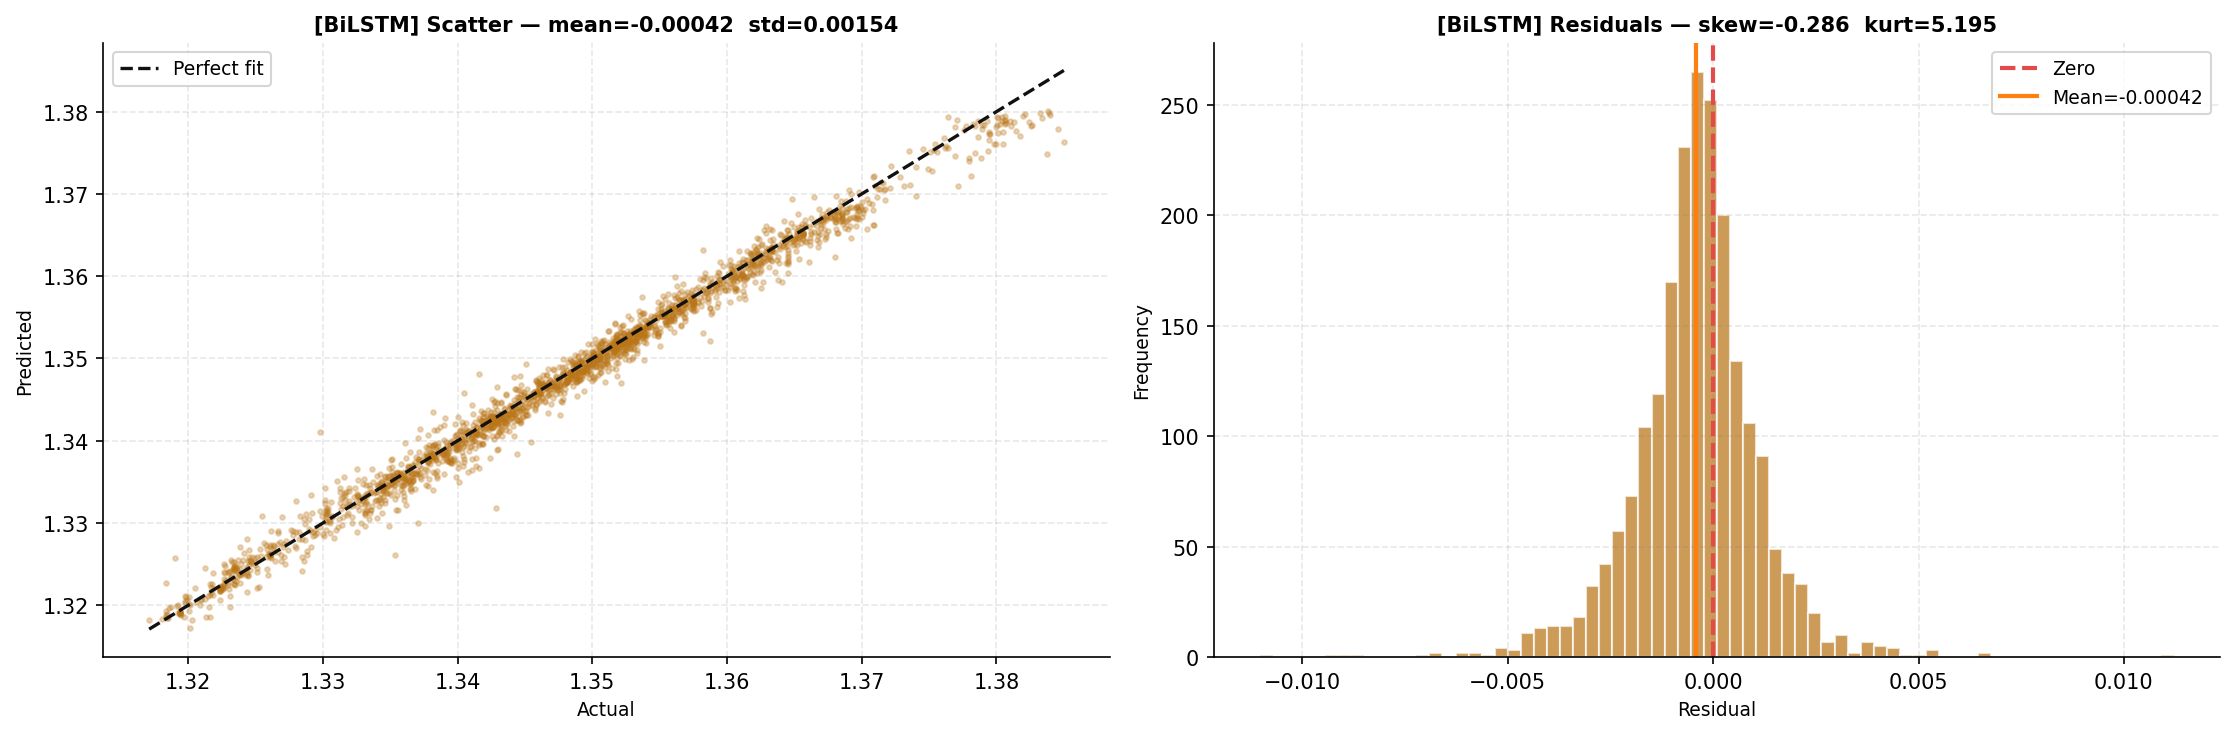

  Saved → plots/BiLSTM_6_scatter_residual.png
  BiLSTM complete.



In [51]:
print("  [BiLSTM]  STEP 5 : PLOT")
print("  " + "-" * 55)
plot_individual_results(
    "BiLSTM", bilstm_history,
    bilstm_train_preds, bilstm_train_actual,
    bilstm_val_preds,   bilstm_val_actual,
    bilstm_test_preds,  bilstm_test_actual,
    bilstm_test_metrics, COLORS["BiLSTM"]
)

results["BiLSTM"] = {
    "history": bilstm_history,
    "val_metrics":  bilstm_val_metrics,
    "preds":   bilstm_test_preds,
    "actual":  bilstm_test_actual,
    "metrics": bilstm_test_metrics,
    "params":  bilstm_model.count_params(),
    "time":    bilstm_time,
}
print("  BiLSTM complete.\n")


# **Vanilla RNN**

**BUILD**

In [52]:
print("\n  [RNN]  STEP 1 : BUILD")
print("  " + "-" * 55)
rnn_model = build_rnn(INPUT_SHAPE, UNITS, DROPOUT, LEARNING_RATE)
rnn_model.summary()
print(f"  Parameters : {rnn_model.count_params():,}")


  [RNN]  STEP 1 : BUILD
  -------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 48, 128)        │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,281 (223.75 KB)

 Trainable params: 57,281 (223.75 KB)

 Non-trainable params: 0 (0.00 B)

  Parameters : 57,281


**TRAIN**

In [53]:
print("\n  [RNN]  STEP 2 : TRAIN")
print("  " + "-" * 55)
print(f"  Train={X_train.shape[0]:,}  Val={X_val.shape[0]:,}\n")
rnn_history, rnn_time = train_model(
    rnn_model, "Vanilla_RNN", X_train, y_train, X_val, y_val
)


  [RNN]  STEP 2 : TRAIN
  -------------------------------------------------------
  Train=10,024  Val=2,148

Epoch 1/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 14s 26ms/step - loss: 0.0617 - mae: 0.2272 - val_loss: 0.0066 - val_mae: 0.0950 - learning_rate: 0.0010
Epoch 2/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0095 - mae: 0.0979 - val_loss: 0.0018 - val_mae: 0.0429 - learning_rate: 0.0010
Epoch 3/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0054 - mae: 0.0751 - val_loss: 0.0012 - val_mae: 0.0339 - learning_rate: 0.0010
Epoch 4/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0119 - mae: 0.0963 - val_loss: 0.0018 - val_mae: 0.0482 - learning_rate: 0.0010
Epoch 5/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0052 - mae: 0.0751 - val_loss: 0.0038 - val_mae: 0.0772 - learning_rate: 0.0010
Epoch 6/100
314/314 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0056 - mae: 0.0766 - val_loss: 0.0042 - val_mae: 0.0807 - learning_rate: 0.0010
Epoch 7/100
314/314 ━━━━━

**VALIDATION REPORT**

In [54]:
print("\n  [RNN]  STEP 3 : VALIDATE")
print("  " + "-" * 55)
rnn_val_preds, rnn_val_actual, rnn_val_metrics = run_inference(
    rnn_model, X_val, y_val
)
rnn_val_ok = print_validation_report("Vanilla_RNN", rnn_val_preds,
                                      rnn_val_actual, rnn_val_metrics)


  [RNN]  STEP 3 : VALIDATE
  -------------------------------------------------------

  VALIDATION — Vanilla_RNN
  RMSE         : 0.00131
  MAE          : 0.00098
  MAPE         : 0.07368
  NRMSE (%)    : 2.01167
  DA (%)       : 44.62040
  DA status  : LOW — worse than random!


**TEST**

In [55]:
print("\n  [RNN]  STEP 4 : TEST")
print("  " + "-" * 55)
rnn_train_preds, rnn_train_actual, _ = run_inference(rnn_model, X_train, y_train)
rnn_test_preds,  rnn_test_actual, rnn_test_metrics = run_inference(
    rnn_model, X_test, y_test
)
print_test_report("Vanilla_RNN", rnn_test_metrics, rnn_model.count_params(), rnn_time)


  [RNN]  STEP 4 : TEST
  -------------------------------------------------------

  TEST — Vanilla_RNN  (57,281 params  104.9s)
  RMSE         : 0.00311
  MAE          : 0.00176
  MAPE         : 0.12977
  NRMSE (%)    : 4.58323
  DA (%)       : 46.66977
  DA status  : CHECK



**PLOT**

  [RNN]  STEP 5 : PLOT
  -------------------------------------------------------


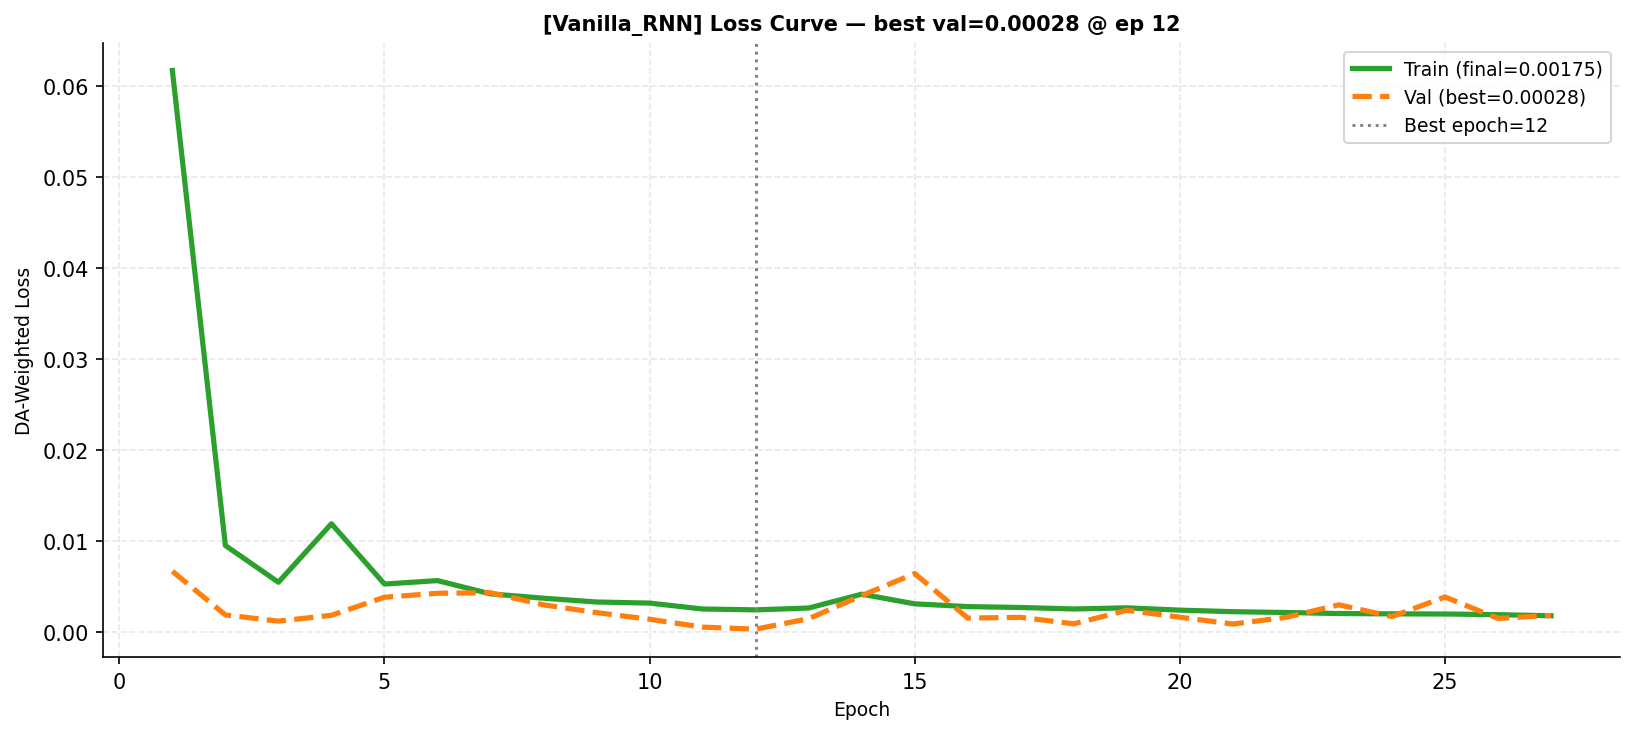

  Saved → plots/Vanilla_RNN_1_loss.png


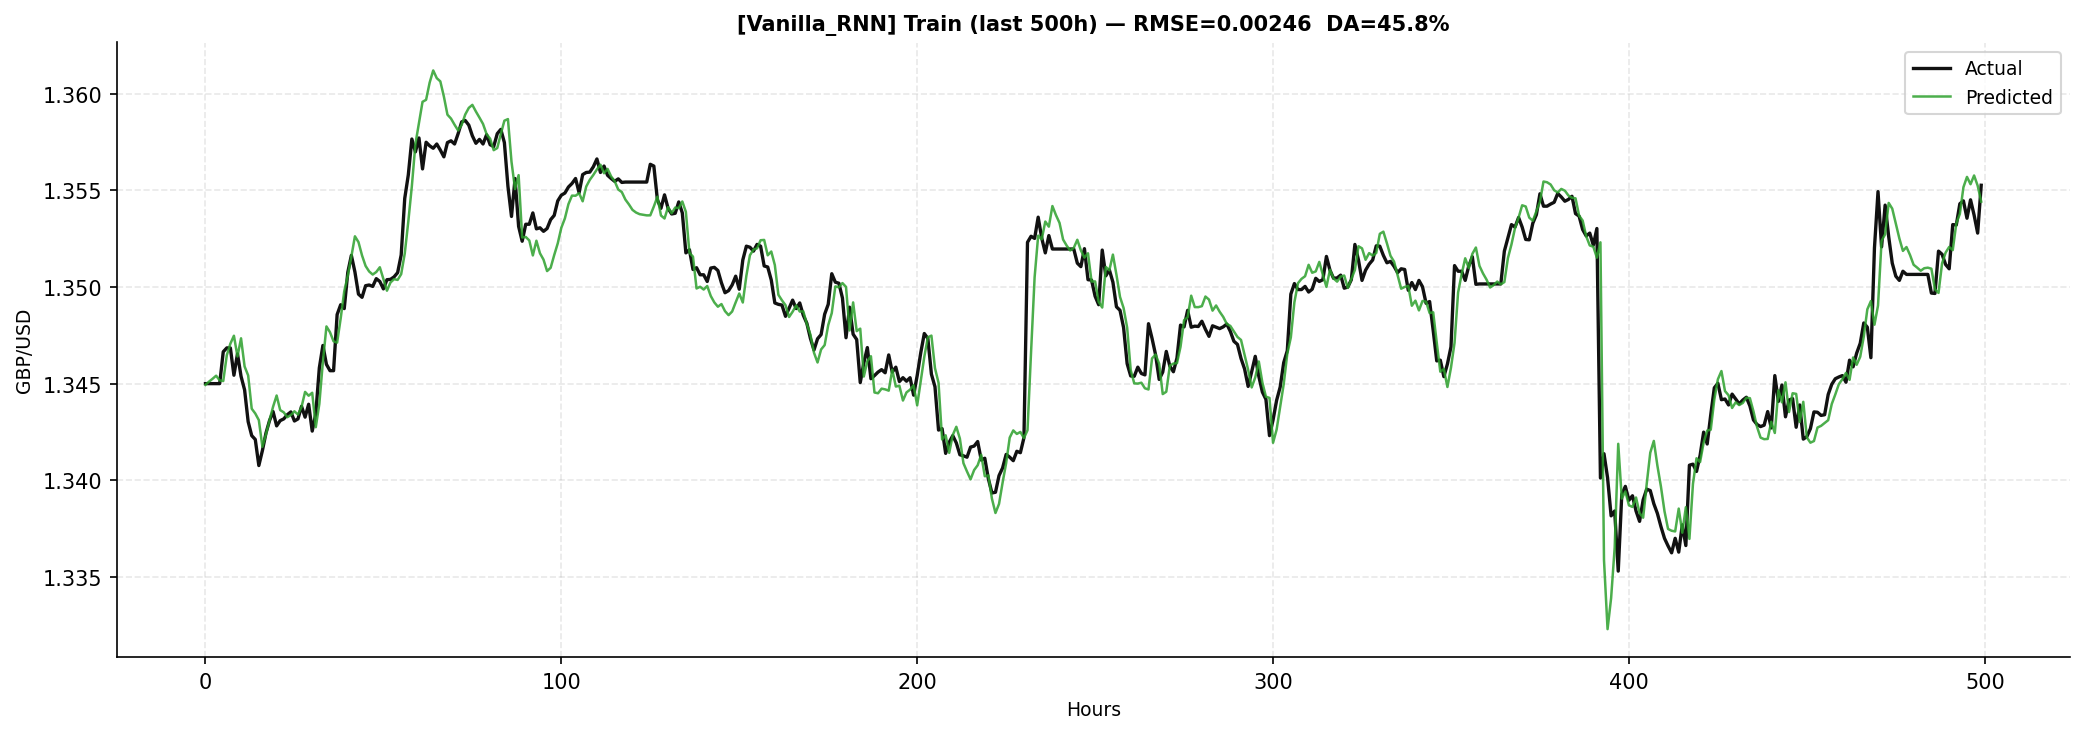

  Saved → plots/Vanilla_RNN_2_train.png


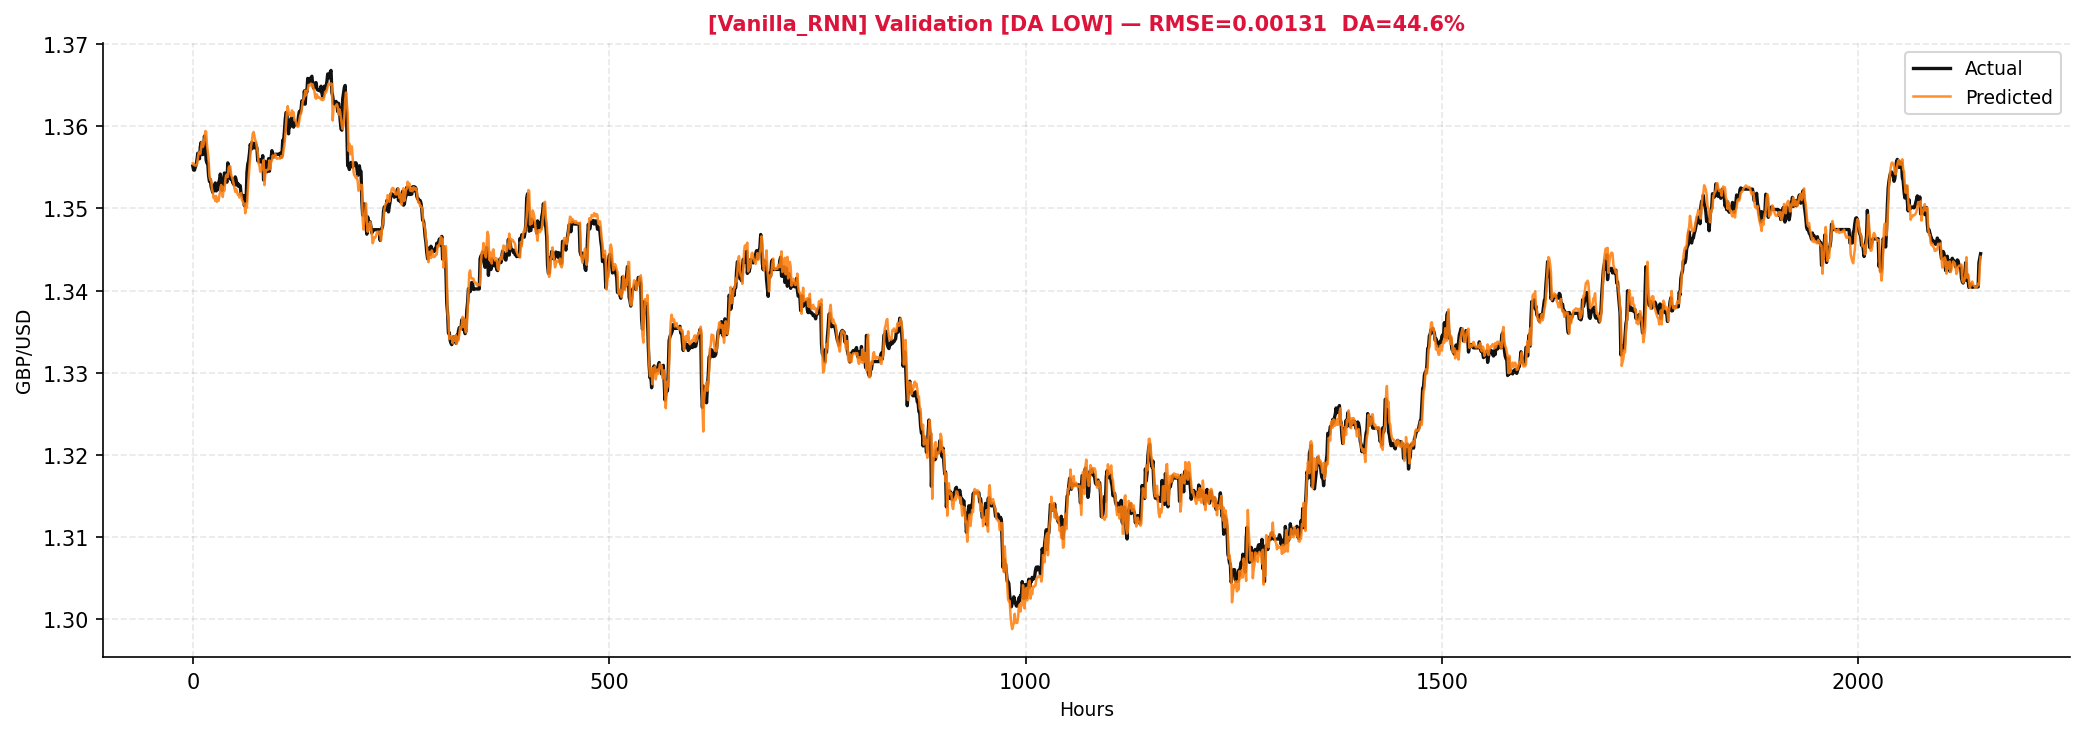

  Saved → plots/Vanilla_RNN_3_val.png


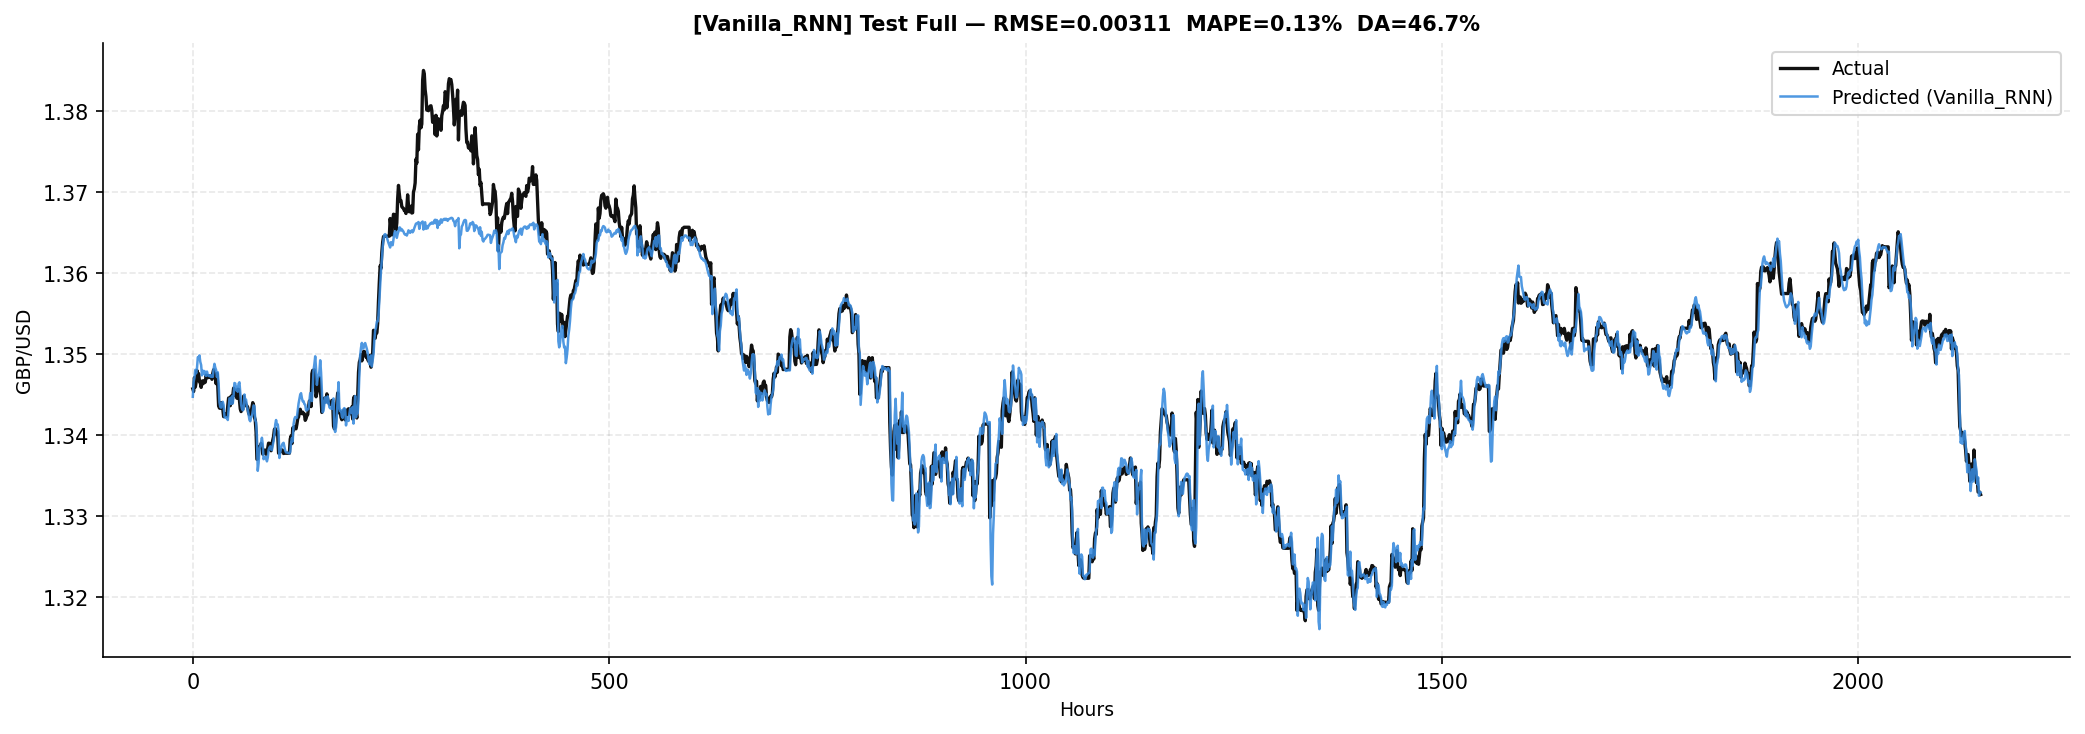

  Saved → plots/Vanilla_RNN_4_test_full.png


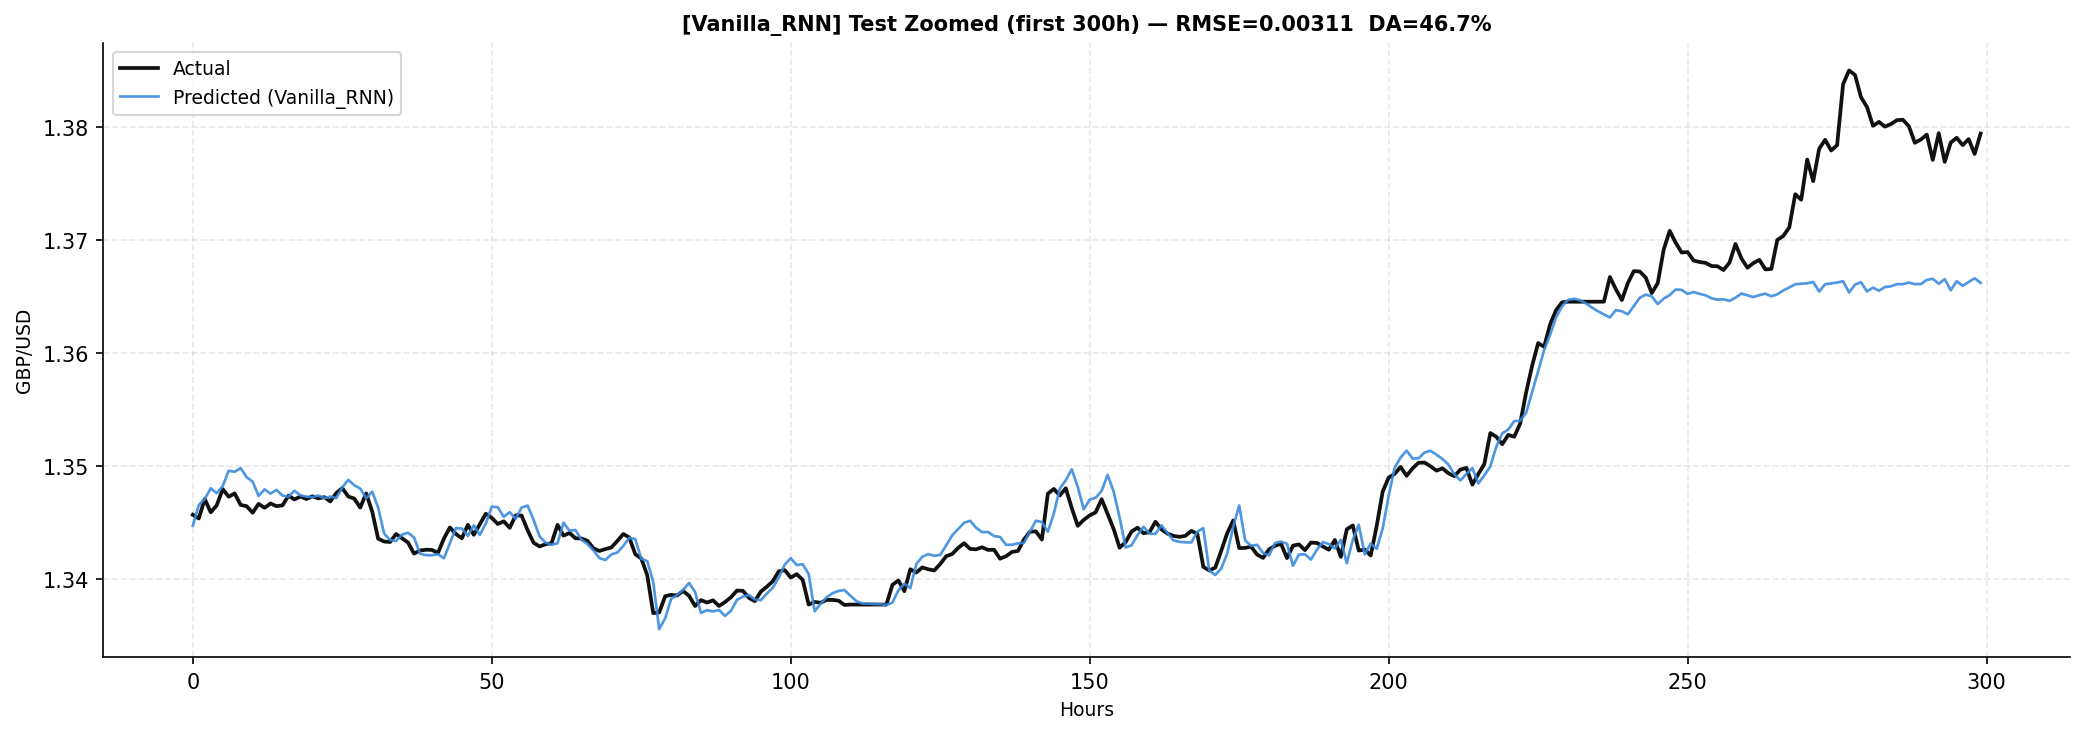

  Saved → plots/Vanilla_RNN_5_test_zoom.png


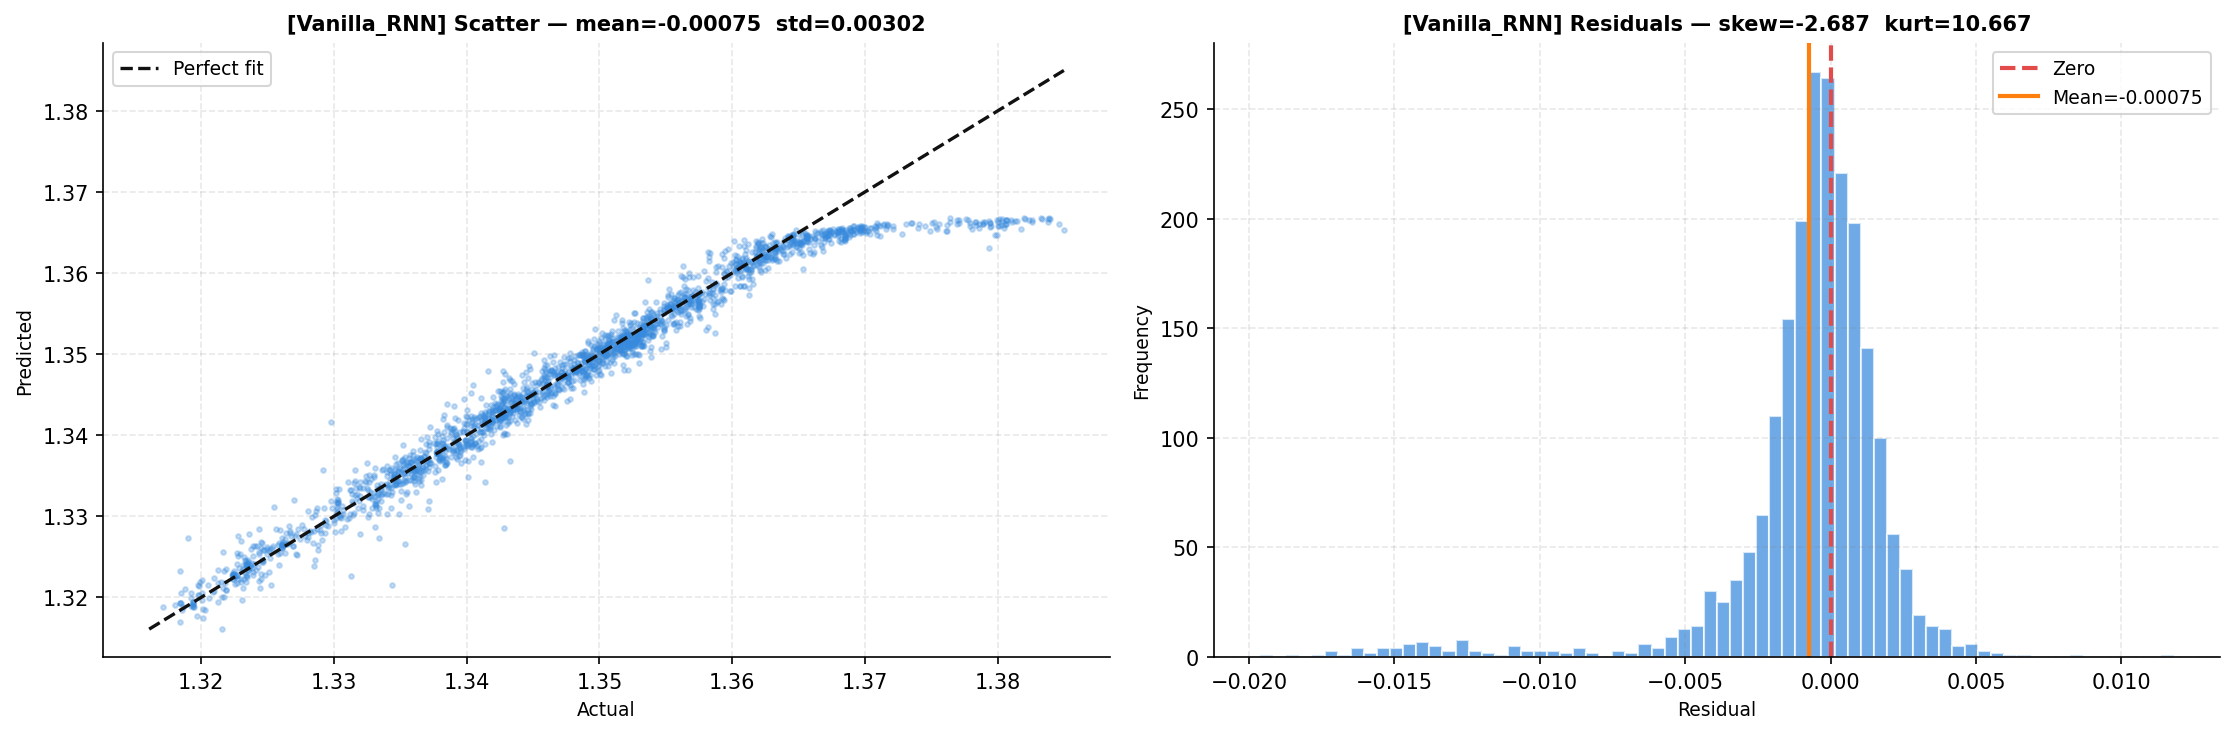

  Saved → plots/Vanilla_RNN_6_scatter_residual.png
  Vanilla RNN complete.



In [56]:
print("  [RNN]  STEP 5 : PLOT")
print("  " + "-" * 55)
plot_individual_results(
    "Vanilla_RNN", rnn_history,
    rnn_train_preds, rnn_train_actual,
    rnn_val_preds,   rnn_val_actual,
    rnn_test_preds,  rnn_test_actual,
    rnn_test_metrics, COLORS["Vanilla_RNN"]
)

results["Vanilla_RNN"] = {
    "history": rnn_history,
    "val_metrics":  rnn_val_metrics,
    "preds":   rnn_test_preds,
    "actual":  rnn_test_actual,
    "metrics": rnn_test_metrics,
    "params":  rnn_model.count_params(),
    "time":    rnn_time,
}
print("  Vanilla RNN complete.\n")

# **CROSS-MODEL COMPARISON**



  CROSS-MODEL COMPARISON

  Validation Set  (used to adjust model before test):
             Val RMSE  Val MAE  Val MAPE  Val DA %
Model                                             
LSTM          0.00119  0.00088     0.066     45.23
GRU           0.00125  0.00095     0.071     45.23
BiLSTM        0.00118  0.00087     0.065     45.55
Vanilla_RNN   0.00131  0.00098     0.074     44.62

  Test Set  (held-out — final performance):
                RMSE      MAE  MAPE (%)  DA (%)  Params  Time (s)
Model                                                            
LSTM         0.00157  0.00110     0.081   46.39  216641     139.2
GRU          0.00172  0.00126     0.093   45.46  164289     120.3
BiLSTM       0.00159  0.00113     0.084   46.20  330305     247.5
Vanilla_RNN  0.00311  0.00176     0.130   46.67   57281     104.9


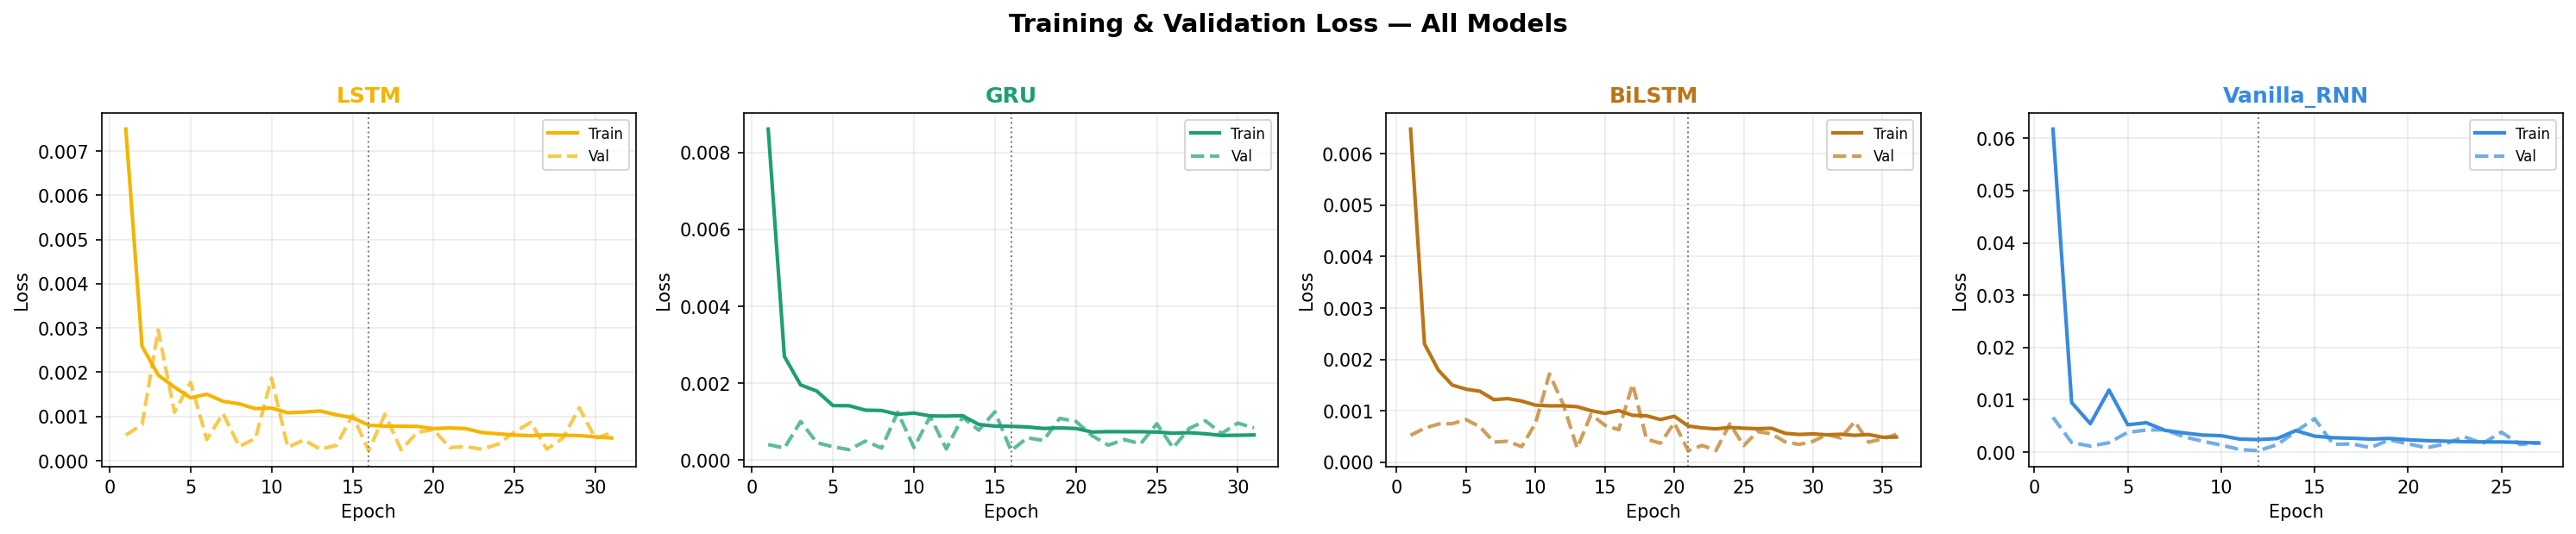

  Saved -> plots/comparison_01_loss.png


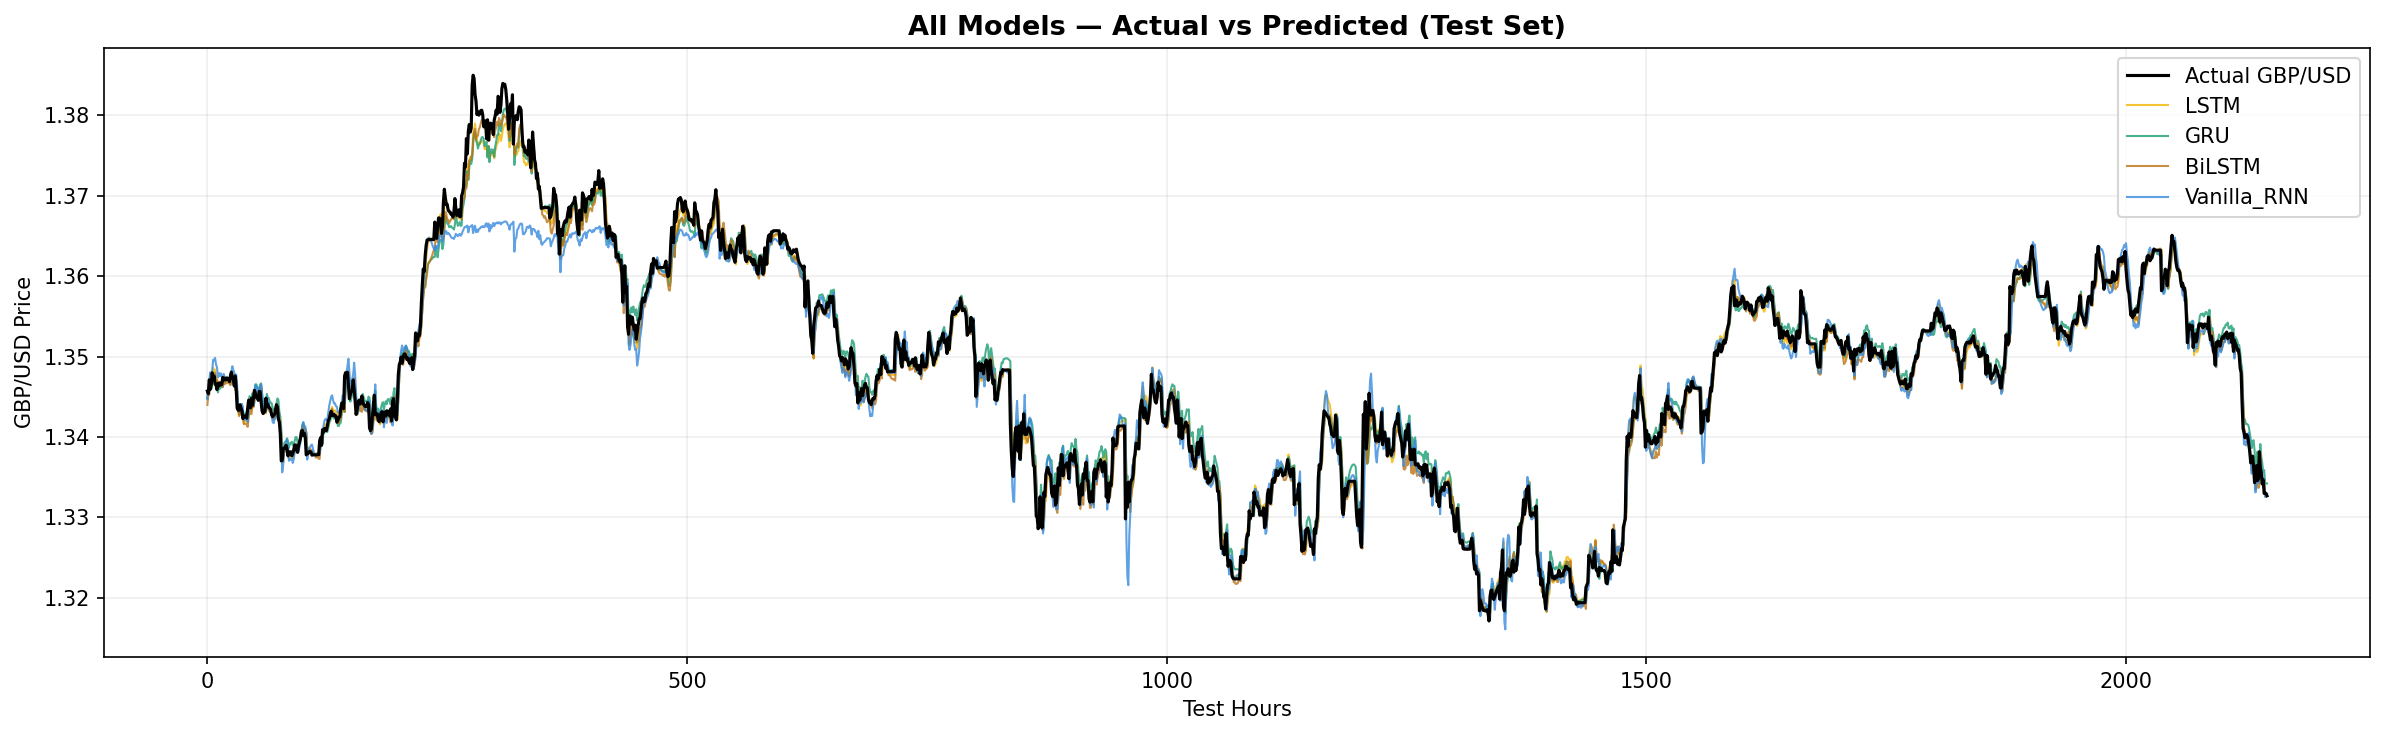

  Saved -> plots/comparison_02_overlay.png


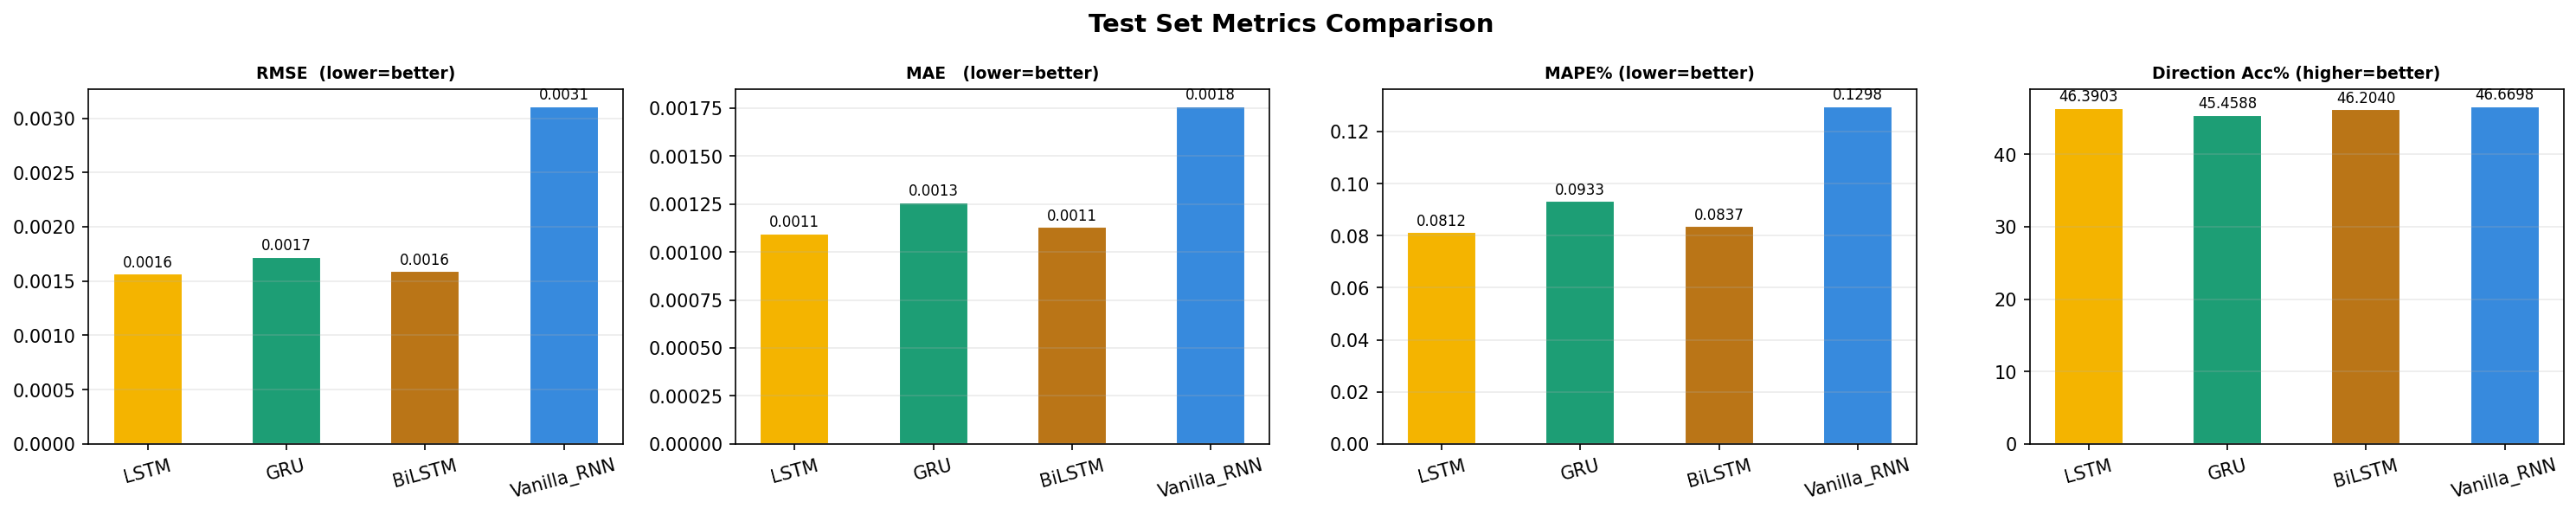

  Saved -> plots/comparison_03_metrics.png


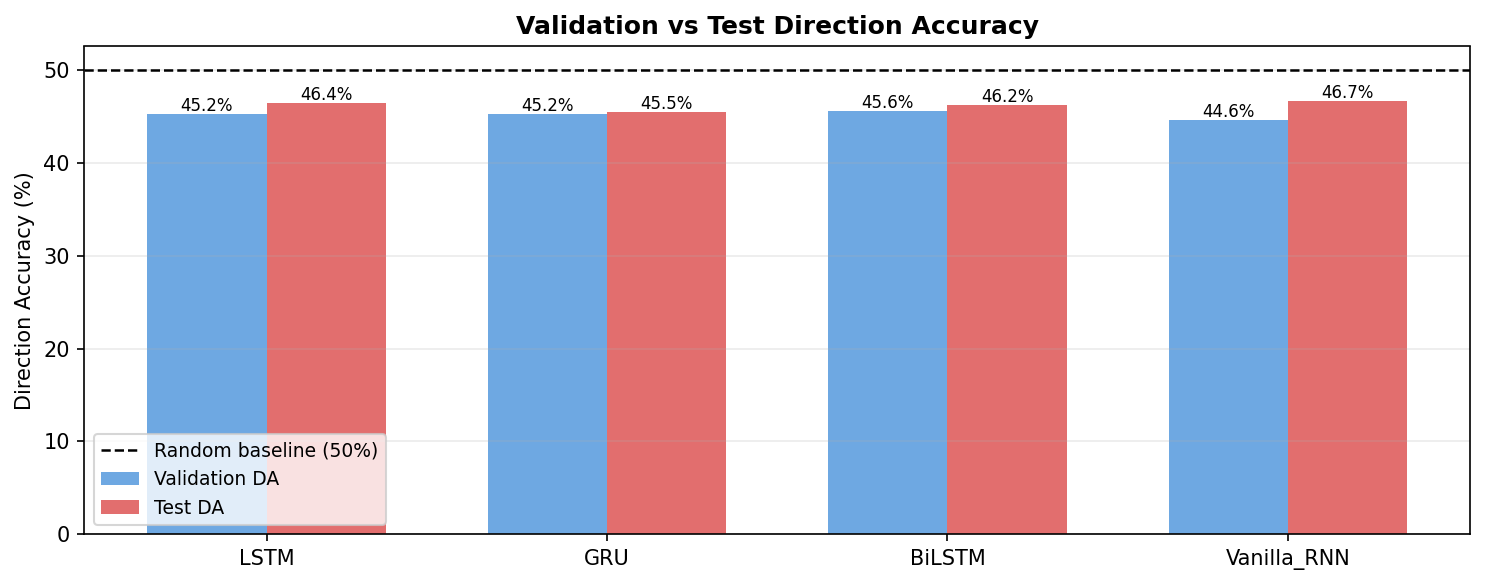

  Saved -> plots/comparison_04_da_val_vs_test.png


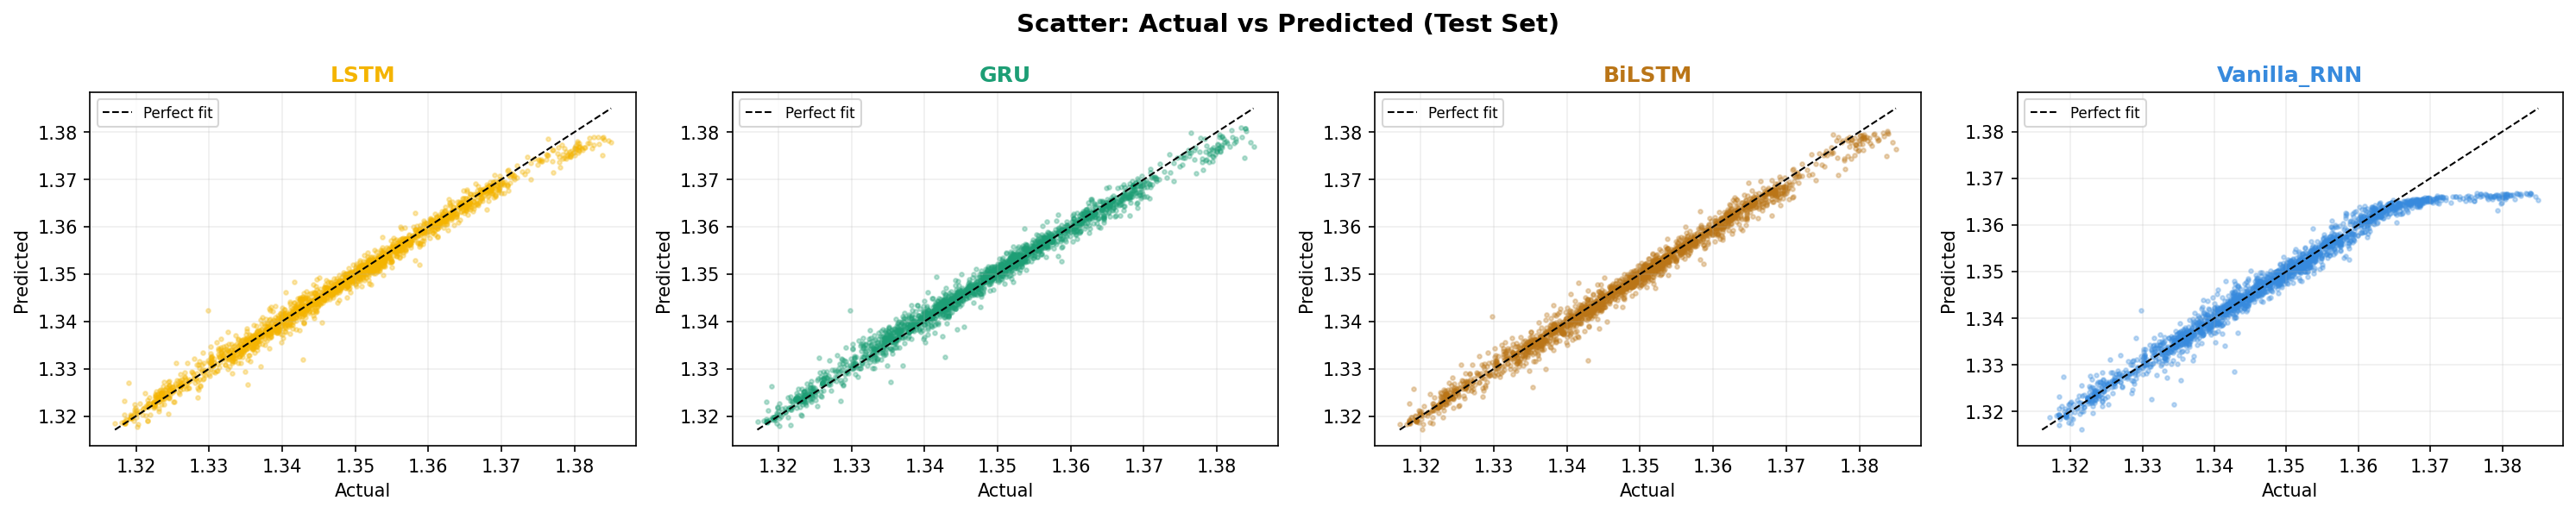

  Saved -> plots/comparison_05_scatter.png


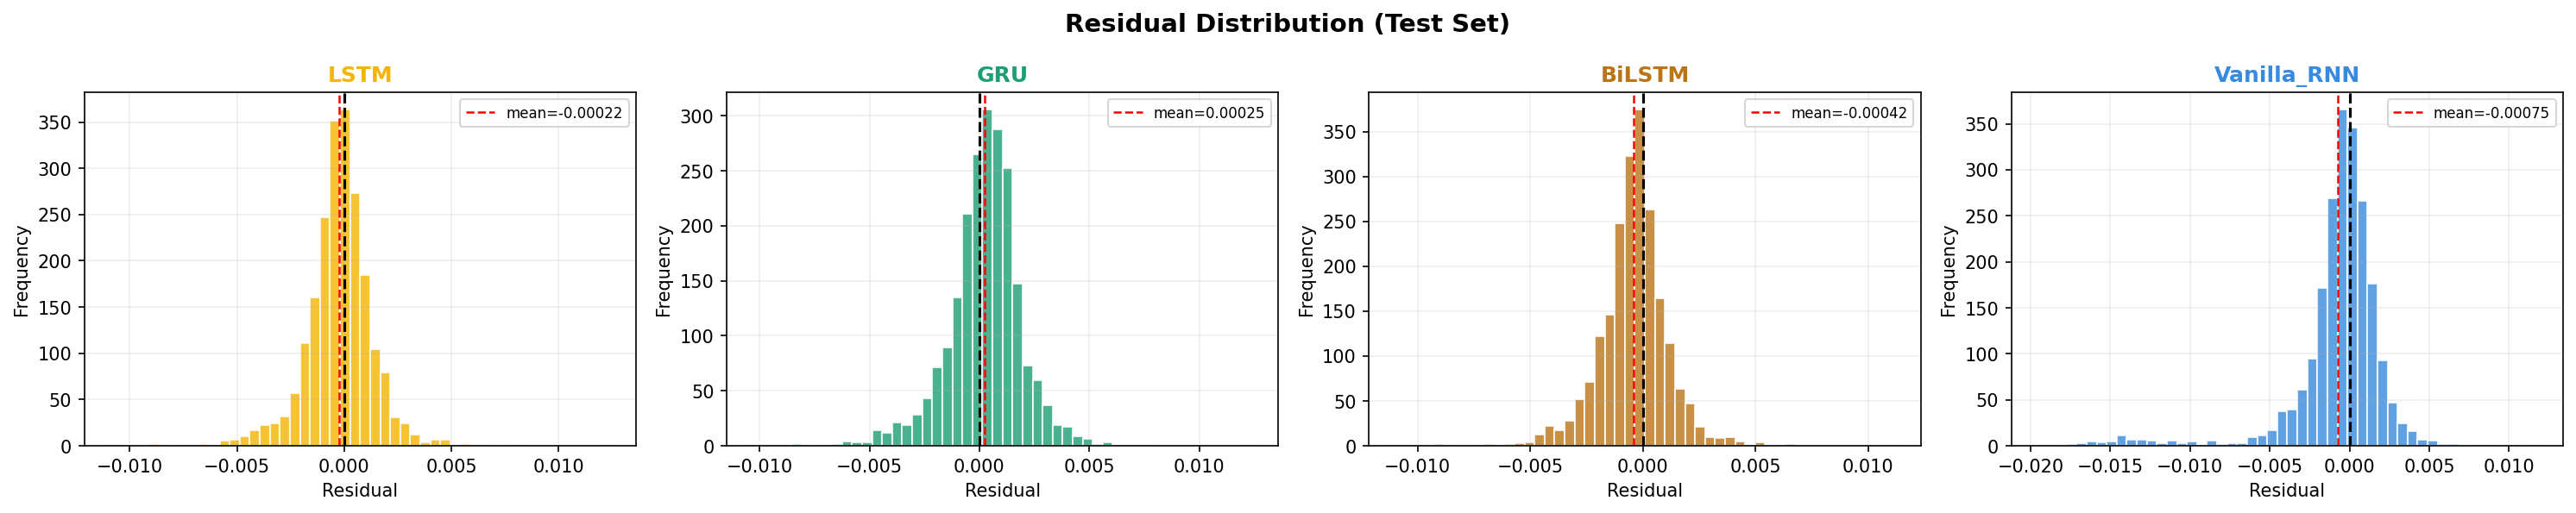

  Saved -> plots/comparison_06_residuals.png


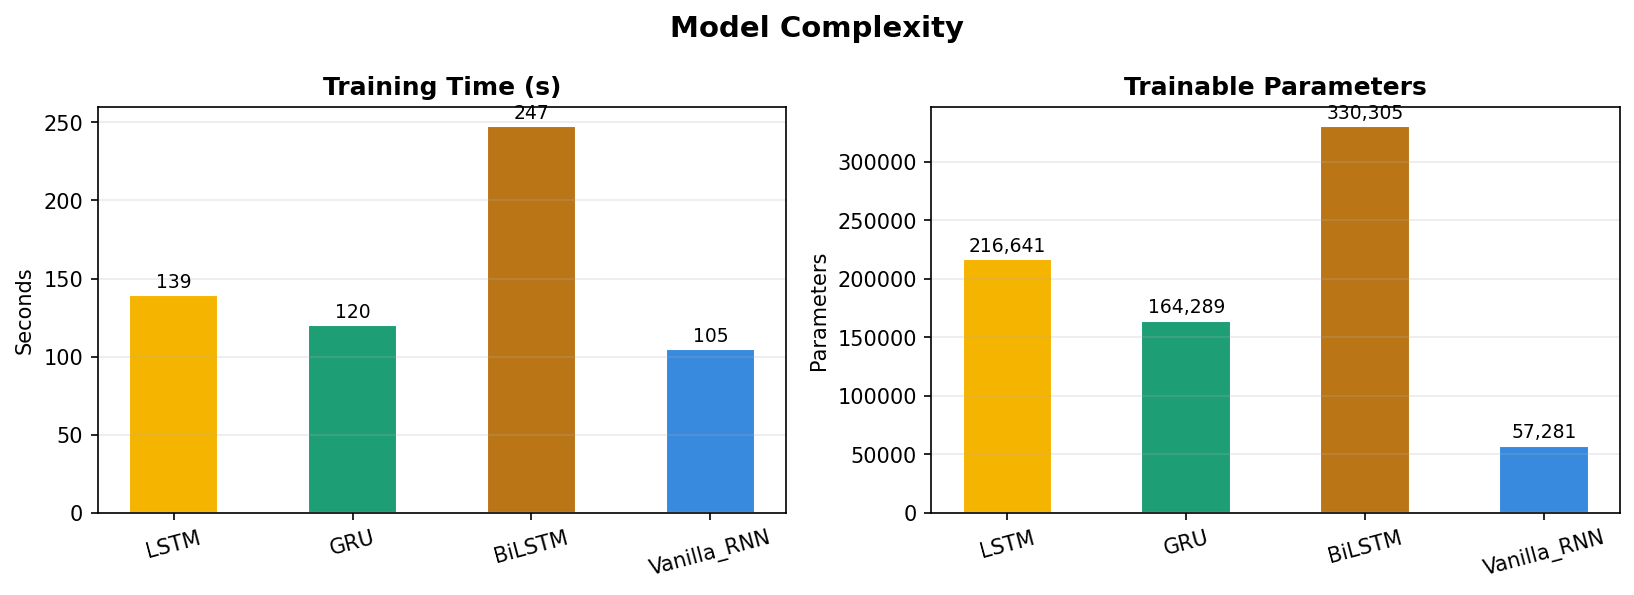

  Saved -> plots/comparison_07_complexity.png


In [57]:
MODEL_NAMES = ["LSTM", "GRU", "BiLSTM", "Vanilla_RNN"]

print("\n\n" + "=" * 70)
print("  CROSS-MODEL COMPARISON")
print("=" * 70)

# ── Validation vs Test comparison table ──────────────────────────────────────
print("\n  Validation Set  (used to adjust model before test):")
val_rows = []
for name in MODEL_NAMES:
    m = results[name]["val_metrics"]
    val_rows.append({
        "Model": name,
        "Val RMSE": round(m["RMSE"], 5),
        "Val MAE":  round(m["MAE"],  5),
        "Val MAPE": round(m["MAPE"], 3),
        "Val DA %": round(m["DA (%)"], 2),
    })
val_df = pd.DataFrame(val_rows).set_index("Model")
print(val_df.to_string())

print("\n  Test Set  (held-out — final performance):")
rows = []
for name in MODEL_NAMES:
    m = results[name]["metrics"]
    rows.append({
        "Model":    name,
        "RMSE":     round(m["RMSE"],   5),
        "MAE":      round(m["MAE"],    5),
        "MAPE (%)": round(m["MAPE"],   3),
        "DA (%)":   round(m["DA (%)"], 2),
        "Params":   results[name]["params"],
        "Time (s)": round(results[name]["time"], 1),
    })
results_df = pd.DataFrame(rows).set_index("Model")
print(results_df.to_string())
results_df.to_csv(os.path.join(PLOTS_DIR, "comparison_table.csv"))

# ── Plot 1 : Loss curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Training & Validation Loss — All Models",
             fontsize=14, fontweight="bold", y=1.02)
for ax, name in zip(axes, MODEL_NAMES):
    h   = results[name]["history"].history
    eps = range(1, len(h["loss"]) + 1)
    c   = COLORS[name]
    ax.plot(eps, h["loss"],     color=c, lw=2,   label="Train")
    ax.plot(eps, h["val_loss"], color=c, lw=2,
            linestyle="--", alpha=0.7, label="Val")
    best_ep = int(np.argmin(h["val_loss"])) + 1
    ax.axvline(best_ep, color="grey", lw=1, linestyle=":")
    ax.set_title(name, color=c, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.25)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_01_loss.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")

# ── Plot 2 : Overlay on test set ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
actual_ref = results["LSTM"]["actual"]
ax.plot(actual_ref, color="black", lw=1.5, label="Actual GBP/USD", zorder=5)
for name in MODEL_NAMES:
    ax.plot(results[name]["preds"], color=COLORS[name], lw=1.0,
            alpha=0.8, label=name)
ax.set_title("All Models — Actual vs Predicted (Test Set)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Test Hours")
ax.set_ylabel("GBP/USD Price")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.2)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_02_overlay.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")

# ── Plot 3 : Metrics bar charts ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Test Set Metrics Comparison", fontsize=14, fontweight="bold")
metric_defs = [
    ("RMSE",   "RMSE  (lower=better)"),
    ("MAE",    "MAE   (lower=better)"),
    ("MAPE",   "MAPE% (lower=better)"),
    ("DA (%)", "Direction Acc% (higher=better)"),
]
for ax, (key, label) in zip(axes, metric_defs):
    values = [results[n]["metrics"][key] for n in MODEL_NAMES]
    colors = [COLORS[n] for n in MODEL_NAMES]
    bars   = ax.bar(MODEL_NAMES, values, color=colors, width=0.5, edgecolor="white")
    ax.set_title(label, fontweight="bold", fontsize=9)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(True, axis="y", alpha=0.25)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(values) * 0.01,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_03_metrics.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")

# ── Plot 4 : Val vs Test DA comparison ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
x    = np.arange(len(MODEL_NAMES))
w    = 0.35
val_da  = [results[n]["val_metrics"]["DA (%)"]  for n in MODEL_NAMES]
test_da = [results[n]["metrics"]["DA (%)"]       for n in MODEL_NAMES]
ax.bar(x - w/2, val_da,  w, label="Validation DA", color="#5599DD", alpha=0.85)
ax.bar(x + w/2, test_da, w, label="Test DA",       color="#DD5555", alpha=0.85)
ax.axhline(50, color="black", lw=1.2, linestyle="--", label="Random baseline (50%)")
ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES)
ax.set_ylabel("Direction Accuracy (%)")
ax.set_title("Validation vs Test Direction Accuracy", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, axis="y", alpha=0.25)
for i, (v, t) in enumerate(zip(val_da, test_da)):
    ax.text(i - w/2, v + 0.3, f"{v:.1f}%", ha="center", fontsize=8)
    ax.text(i + w/2, t + 0.3, f"{t:.1f}%", ha="center", fontsize=8)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_04_da_val_vs_test.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")

# ── Plot 5 : Scatter ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Scatter: Actual vs Predicted (Test Set)", fontsize=14, fontweight="bold")
for ax, name in zip(axes, MODEL_NAMES):
    p_ = results[name]["preds"]
    a_ = results[name]["actual"]
    ax.scatter(a_, p_, s=5, alpha=0.3, color=COLORS[name])
    lo, hi = min(a_.min(), p_.min()), max(a_.max(), p_.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="Perfect fit")
    ax.set_title(name, color=COLORS[name], fontweight="bold")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_05_scatter.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")

# ── Plot 6 : Residuals ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Residual Distribution (Test Set)", fontsize=14, fontweight="bold")
for ax, name in zip(axes, MODEL_NAMES):
    res = results[name]["preds"] - results[name]["actual"]
    ax.hist(res, bins=50, color=COLORS[name], alpha=0.8, edgecolor="white")
    ax.axvline(0,          color="black", lw=1.5, linestyle="--")
    ax.axvline(res.mean(), color="red",   lw=1.2, linestyle="--",
               label=f"mean={res.mean():.5f}")
    ax.set_title(name, color=COLORS[name], fontweight="bold")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_06_residuals.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")

# ── Plot 7 : Complexity ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle("Model Complexity", fontsize=14, fontweight="bold")
times  = [results[n]["time"]   for n in MODEL_NAMES]
params = [results[n]["params"] for n in MODEL_NAMES]
clrs   = [COLORS[n]            for n in MODEL_NAMES]
for ax, vals, title, ylabel in [
    (ax1, times,  "Training Time (s)",    "Seconds"),
    (ax2, params, "Trainable Parameters", "Parameters"),
]:
    bars = ax.bar(MODEL_NAMES, vals, color=clrs, width=0.5, edgecolor="white")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(True, axis="y", alpha=0.25)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f"{val:,.0f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
p = os.path.join(PLOTS_DIR, "comparison_07_complexity.png")
plt.savefig(p, bbox_inches="tight")
plt.show()
print(f"  Saved -> {p}")